# Kadastra — Notebook Intégré Complet

**Projet :** Kadastra — Plateforme IA d'estimation immobilière pour le marché tunisien

---

## PARTIE 1 — BO2 : Modélisation des Prix & Agent de Tendances Régionales

## PARTIE 2 — BO3 : Classification des Articles de Sécurité & Génération de Contrats

---


---
# PARTIE 1 — BO2 : Modélisation des Prix & Agent de Tendances Régionales
---


# Kadastra BO2 — Price Estimation Modelling Notebook

**Project:** Kadastra — AI-powered real estate platform for the Tunisian market  
**Business Objective:** BO2 — Property price estimation  

---

## Overview

This notebook trains and evaluates three price estimation models on six property sub-datasets produced by the preprocessing pipeline. Upload the `model_ready_*.csv` files when prompted.

### Three models per sub-dataset

| Model | Purpose |
|---|---|
| **Ridge Regression** | Linear baseline — interpretable, fast, establishes minimum MAPE to beat |
| **LightGBM** | Primary model — handles non-linearity, missing values, zone interactions |
| **Random Forest** | Production model for terrain_vente where it outperforms LightGBM |

### Six sub-datasets

| Sub-dataset | Rows | Primary price drivers |
|---|---|---|
| appt_location | 7,250 | surface, zone, meuble premium |
| appt_vente | 4,383 | surface, zone median, floor, standing |
| maison_vente | 2,636 | surface, sub-type (villa/duplex), zone |
| maison_location | 1,105 | surface, zone, standing |
| terrain_vente | 1,509 | surface + zone (almost nothing else) |
| local_vente | 439 | surface, zone (commercial dynamics) |

### Key design principles

1. **Leakage-free CV** — zone medians and target encodings computed per fold on training data only
2. **Log-price target** — `log1p(price)` makes errors proportional across all price ranges
3. **Winsorization** — training labels clipped at p1/p99; evaluation always uses true unclipped labels
4. **Stratified CV** — folds stratified by governorate × price decile for stable estimates
5. **Separate models per sub-type** — price drivers differ fundamentally across property types

## Cell 1 — Installs & Imports

All dependencies installed and imported. Key constants controlling model behaviour:

- **`TFIDF_MAX_FEATURES = 30`** — reduced from 60 after diagnostic showed boilerplate words (vendre, appartement, salle) dominated importance at 55-65%. After reduction, TF-IDF importance dropped to 17-36% and structural features dominate as intended.
- **`TFIDF_MIN_DF = 10`** — token must appear in at least 10 listings; prevents listing-specific words from becoming features
- **`BOOST_ROUNDS = 600` + `EARLY_STOP = 50`** — LightGBM trains up to 600 trees but stops early if validation RMSE plateaus for 50 rounds

In [ ]:
get_ipython().system('pip install lightgbm optuna shap scikit-learn pandas numpy matplotlib category_encoders -q')

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import warnings, os, io, joblib
from datetime import datetime
warnings.filterwarnings('ignore')

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap
import category_encoders as ce

OUTPUT_DIR    = '/content/kadastra_models/'
RANDOM_STATE  = 42
N_FOLDS       = 5
LOG_PRICE_CAP = np.log1p(8_000_000)

OPTUNA_TRIALS_LARGE  = 25
OPTUNA_TRIALS_SMALL  = 15
BOOST_ROUNDS         = 600
EARLY_STOP           = 50
TFIDF_MAX_FEATURES   = 30
TFIDF_MIN_DF         = 10
RIDGE_CV_FOLDS       = 3
SHAP_SAMPLE_SIZE     = 500

os.makedirs(OUTPUT_DIR, exist_ok=True)
results_log = []
print('Imports ready. Output dir:', OUTPUT_DIR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.3 MB/s eta 0:00:00
Imports ready. Output dir: /content/kadastra_models/


## Cell 2 — Upload & Load Datasets

Upload all six `model_ready_*.csv` files from the preprocessing pipeline. The loader strips Colab's auto-appended `(1)`, `(2)` suffixes so dataset names are clean regardless of re-uploads.

Each file contains the feature manifest for its sub-dataset plus auxiliary columns (`zone`, `sub_zone`, `gouvernorat`, `description`, `price_numeric`) used for fold-wise feature engineering but excluded from model inputs.

In [ ]:
from google.colab import files

uploaded = files.upload()
if not uploaded:
    raise ValueError('No files uploaded.')

DATASETS = {}
for fname, raw in uploaded.items():
    name = fname.replace('model_ready_', '').replace('.csv', '')
    name = name.replace(' (1) (2)', '').replace(' (1)', '').strip()
    df   = pd.read_csv(io.BytesIO(raw))
    df   = df[df['log_price'].notna()].copy()
    df   = df.reset_index(drop=True)
    DATASETS[name] = df
    print(f'  {name:<25}: {len(df):,} rows, {df.shape[1]} cols')

print(f'Loaded {len(DATASETS)} datasets.')

Saving model_ready_appt_location (1).csv to model_ready_appt_location (1).csv
Saving model_ready_appt_vente (1).csv to model_ready_appt_vente (1).csv
Saving model_ready_maison_vente (1).csv to model_ready_maison_vente (1).csv
Saving model_ready_terrain_vente (1).csv to model_ready_terrain_vente (1).csv
Saving model_ready_local_vente (1).csv to model_ready_local_vente (1).csv
Saving model_ready_maison_location (1).csv to model_ready_maison_location (1).csv
  appt_location            : 7,250 rows, 68 cols
  appt_vente               : 4,383 rows, 67 cols
  maison_vente             : 2,636 rows, 64 cols
  terrain_vente            : 1,509 rows, 51 cols
  local_vente              : 440 rows, 55 cols
  maison_location          : 1,105 rows, 63 cols
Loaded 6 datasets.


## Cell 2b — Pre-Training Data Fixes

Three targeted fixes applied before training, identified through residual analysis of earlier model versions:

**Fix 3 — local_vente hard floor (50,000 DT)**  
One commercial listing at 25,000 DT survived preprocessing — physically implausible (below construction cost for any commercial space). Dropped.

**Fix 2 — Secondary city flag**  
Governorates with systematically lower real estate prices than zone medians suggest are flagged with `is_secondary_city=1`. Without this, the model overpredicts a Gabes apartment at 60,000 DT by 140%+ because its zone median is calibrated on Tunis-area data. Governorates identified via residual bias analysis showing consistent +10%+ overprediction: Gabes, Kasserine, Kairouan, Beja, Jendouba, Zaghouan, Mahdia, Bizerte, Manouba, Sfax, Siliana, Kef, Gafsa.

**Fix 2b — Maison sub-type flags**  
The `maison` category mixes villas, duplexes, riads, and ordinary houses — very different price levels. Five binary flags extracted from listing descriptions give the model explicit sub-type information. Added here rather than in preprocessing because the need was only identified after initial residual analysis.

In [ ]:
print('Fix 3: local_vente price floor (<50,000 DT)')
for name in [k for k in DATASETS if 'local_vente' in k]:
    df = DATASETS[name].copy()
    n_before = len(df)
    too_cheap = df['price_numeric'] < 50_000
    if too_cheap.any():
        print(f'  [{name}] dropping {too_cheap.sum()} locals < 50,000 DT')
        print(df[too_cheap][['adresse','price_numeric','surface_numeric']].head().to_string())
        DATASETS[name] = df[~too_cheap].reset_index(drop=True)
        print(f'    {n_before} -> {len(DATASETS[name])} rows')
    else:
        print(f'  [{name}] no rows below 50,000 DT')

print('\nFix 2: secondary city flag')
SECONDARY_CITIES = {
    'Gabes', 'Kasserine', 'Kairouan', 'Beja', 'Jendouba', 'Zaghouan',
    'Mahdia', 'Bizerte', 'Manouba', 'Sfax', 'Siliana', 'Kef', 'Gafsa',
}
for name in [k for k in DATASETS if 'vente' in k]:
    df = DATASETS[name]
    if 'gouvernorat' in df.columns:
        df['is_secondary_city'] = df['gouvernorat'].isin(SECONDARY_CITIES).astype(int)
        DATASETS[name] = df
        print(f'  [{name}] flagged {df["is_secondary_city"].sum()} secondary city rows')
    else:
        print(f'  [{name}] no gouvernorat column, skipping')

print('\nFix 2b: maison sub-type NLP flags')
for name in [k for k in DATASETS if 'maison' in k]:
    df = DATASETS[name]
    text = df.get('description', pd.Series(['']*len(df))).fillna('').str.lower()
    df['nlp_is_villa']   = text.str.contains(r'\bvilla\b|\bpenthouse\b', regex=True).astype(int)
    df['nlp_is_duplex']  = text.str.contains(r'\bduplex\b|\btriplex\b', regex=True).astype(int)
    df['nlp_is_riad']    = text.str.contains(r'\briad\b|\bdar\b|\bmedina\b', regex=True).astype(int)
    df['nlp_has_pool']   = text.str.contains(r'\bpiscine\b|\bpool\b', regex=True).astype(int)
    df['nlp_standing']   = text.str.contains(
        r'haut\s+standing|grand\s+standing|luxe|prestige', regex=True).astype(int)
    DATASETS[name] = df
    print(f'  [{name}]:', df[['nlp_is_villa','nlp_is_duplex','nlp_is_riad',
                               'nlp_has_pool','nlp_standing']].sum().to_dict())

Fix 3: local_vente price floor (<50,000 DT)
  [local_vente] dropping 1 locals < 50,000 DT
                adresse  price_numeric  surface_numeric
50  Ettahrir À Ettahrir        25000.0             20.0
    440 -> 439 rows

Fix 2: secondary city flag
  [appt_vente] flagged 216 secondary city rows
  [maison_vente] flagged 237 secondary city rows
  [terrain_vente] flagged 250 secondary city rows
  [local_vente] flagged 26 secondary city rows

Fix 2b: maison sub-type NLP flags
  [maison_vente]: {'nlp_is_villa': 1986, 'nlp_is_duplex': 211, 'nlp_is_riad': 66, 'nlp_has_pool': 716, 'nlp_standing': 401}
  [maison_location]: {'nlp_is_villa': 886, 'nlp_is_duplex': 106, 'nlp_is_riad': 30, 'nlp_has_pool': 475, 'nlp_standing': 154}


## Cell 3 — Utilities & Constants

Core helper functions:

**`mape_score`** — MAPE computed in original DT space after `expm1` back-transform. A MAPE of 20% means the model predicts within ±20% of true price on average. This is the primary KPI metric for BO2.

**`get_X_y`** — extracts feature matrix X and target y. Columns in `ALWAYS_DROP` are excluded: they either encode the target directly (`price_numeric`, `log_price`) or are raw strings that must be encoded before use (`zone`, `sub_zone`, `gouvernorat` are target-encoded per fold in Cell 5).

**`stratified_price_zone_splits`** — 5-fold splits stratified by governorate × price decile. Ensures each fold has representative geographic and price distribution — prevents all luxury listings landing in one fold which would produce misleadingly good or bad fold estimates.

In [ ]:
def mape_score(y_true, y_pred):
    yt = np.expm1(np.array(y_true))
    yp = np.expm1(np.array(y_pred))
    m  = yt > 0
    return np.mean(np.abs((yt[m] - yp[m]) / yt[m])) * 100

def log_result(dataset, model_name, fold_mapes, fold_r2s):
    entry = {
        'dataset':   dataset,
        'model':     model_name,
        'mape_mean': round(np.mean(fold_mapes), 2),
        'mape_std':  round(np.std(fold_mapes),  2),
        'r2_mean':   round(np.mean(fold_r2s),   4),
        'r2_std':    round(np.std(fold_r2s),    4),
    }
    results_log.append(entry)
    print(f'  [{model_name}] MAPE: {entry["mape_mean"]:.1f}% '
          f'+/- {entry["mape_std"]:.1f}%   R2: {entry["r2_mean"]:.3f} +/- {entry["r2_std"]:.3f}')
    return entry

ALWAYS_DROP = [
    'adresse', 'datepost', 'log_price', 'price_numeric',
    'zone', 'sub_zone', 'prix_m2', 'gouvernorat',
    'category', 'transaction', 'description',
]
NOISY_NLP_FLAGS = ['nlp_residence_gardee', 'nlp_proche_centre', 'nlp_cuisine_equipee']
RIDGE_ALPHAS = [0.01, 0.1, 1, 10, 50, 100, 500, 1000, 5000, 10000]

def get_X_y(df, keep_aux=False):
    TARGET   = 'log_price'
    drop_set = set(ALWAYS_DROP + NOISY_NLP_FLAGS)
    feat_cols = [
        c for c in df.columns
        if c not in drop_set and pd.api.types.is_numeric_dtype(df[c])
    ]
    X = df[feat_cols].copy()
    y = df[TARGET].values
    if keep_aux:
        aux_cols = [
            'price_numeric', 'surface_numeric', 'category', 'transaction',
            'zone', 'sub_zone', 'description', 'log_price', 'gouvernorat', 'gouvernorat_cat'
        ]
        aux = df[[c for c in aux_cols if c in df.columns]].copy()
        return X, y, feat_cols, aux
    return X, y, feat_cols

def stratified_price_zone_splits(y, zone_series, n_folds=N_FOLDS):
    bins     = pd.qcut(y, q=5, labels=False, duplicates='drop').astype(str)
    zones    = zone_series.fillna('unknown').astype(str)
    combined = pd.factorize(bins + '_' + zones)[0]
    skf      = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    return list(skf.split(np.zeros(len(y)), combined))

def save_shap_plot(model, X, dataset_name, model_name):
    try:
        sample    = X.sample(min(SHAP_SAMPLE_SIZE, len(X)), random_state=RANDOM_STATE)
        explainer = shap.TreeExplainer(model)
        sv        = explainer.shap_values(sample)
        plt.figure(figsize=(10, 7))
        shap.summary_plot(sv, sample, max_display=20, show=False, plot_type='bar')
        plt.title(f'{dataset_name} -- {model_name}')
        plt.tight_layout()
        path = os.path.join(OUTPUT_DIR, f'shap_{dataset_name}_{model_name}.png')
        plt.savefig(path, dpi=100, bbox_inches='tight')
        plt.close()
        print(f'    SHAP saved: {os.path.basename(path)}')
    except Exception as e:
        print(f'    SHAP skipped: {e}')

print('Utilities ready.')

Utilities ready.


## Cell 4 — TF-IDF Pre-computation

Listing descriptions contain rich signal not captured in structured fields. TF-IDF (Term Frequency–Inverse Document Frequency) extracts this as numeric features.

### Why pre-compute outside the fold loop?
IDF weights measure word rarity across all listings — they carry no price information, so fitting them on the full dataset is safe. Inside each fold, we simply slice the pre-computed dense matrix (`dense.iloc[tr_idx]`) — ~100x faster than re-fitting.

### Stopword strategy
Diagnostic analysis revealed TF-IDF at 55-65% of total feature importance, dominated by French function words and transaction boilerplate (`vendre`, `louer`, `appartement`, `salle`) — words identical for every listing of the same type. These carry no price signal; they were proxies for description length.

After adding the extended stopword list:
- TF-IDF importance dropped from 55-65% to **17-36%**
- Structural features now correctly dominate (51-68%)
- Surviving TF-IDF tokens carry genuine signal: `jardin`, `parking`, `spacieux`, `moderne`, `plage`

In [ ]:
TFIDF_CACHE = {}

FRENCH_STOPWORDS = [
    'de', 'du', 'la', 'le', 'les', 'un', 'une', 'des', 'et', 'en',
    'au', 'aux', 'ce', 'qui', 'que', 'pour', 'par', 'sur', 'avec',
    'dans', 'est', 'il', 'elle', 'vous', 'nous', 'se', 'sa', 'son',
    'ou', 'si', 'ne', 'pas', 'plus', 'très', 'bien', 'tout', 'aussi',
    'comme', 'mais', 'donc', 'car', 'ni', 'je', 'tu', 'on',
    'à', 'y', 'dont', 'lors', 'leur', 'cette', 'cet', 'ces',
    # Transaction boilerplate
    'vendre', 'vente', 'louer', 'location', 'prix', 'vend', 'achat', 'achetez', 'offre',
    # Category boilerplate (same for all listings in this sub-dataset)
    'appartement', 'maison', 'villa', 'terrain', 'local', 'bureau', 'commercial', 'commerce',
    # Room description (already in structured features)
    'salle', 'salon', 'cuisine', 'chambres', 'chambre', 'deux', 'trois', 'quatre', 'cinq',
    # Common filler
    'dune', 'tres', 'belle', 'beau', 'grand', 'grande', 'situe', 'situ', 'dispose', 'comprend',
    'quipe', 'coucher', 'bain', 'meubl', 'deau', 'dun', 'tage', 'rsidence',
    'propose', 'compose', 'superficie', 'quartier', 'terrasse', 'vue', 'suite',
    'piscine', 'route', 'titre', 'emplacement', 'lot', 'projet', 'zone',
    'opportunit', 'contacter', 'immobilire', 'immeuble', 'surface', 'activit',
    's2', 's3', 'lumineux', 'chauffage', 'calme', 'central', 'balcon',
    'parentale', 'schoir', 'garage', '000', 'hammamet', 'rezehdechausse', 'rdc',
    'mer', 'manger', 'suites', 'climatisation', 'ltage', 'dressing',
    'foncier', 'rsidentiel', 'stratgique', 'individuel', 'idal', 'faade', 'lagence',
    'principale', 'visibilit', 'centre', 'fonds', 'dt', 'ville', 'votre'
]

print('Pre-computing TF-IDF per dataset...')
for name, df in DATASETS.items():
    if 'description' not in df.columns:
        TFIDF_CACHE[name] = (None, None)
        print(f'  {name}: no description column, skipping')
        continue
    text   = df['description'].fillna('').reset_index(drop=True)
    tfidf  = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES,
                             min_df=TFIDF_MIN_DF,
                             ngram_range=(1, 2),
                             sublinear_tf=True,
                             stop_words=FRENCH_STOPWORDS)
    matrix = tfidf.fit_transform(text)
    cols   = [f'tfidf_{t}' for t in tfidf.get_feature_names_out()]
    dense  = pd.DataFrame(matrix.toarray(), columns=cols, index=df.index)
    TFIDF_CACHE[name] = (tfidf, dense)
    print(f'  {name}: {len(cols)} features | top tokens: {list(tfidf.get_feature_names_out()[:8])}')

print('TF-IDF cache ready.')

Pre-computing TF-IDF per dataset...
  appt_location: 30 features | top tokens: ['afficher', 'afficher numro', 'agence', 'ainsi', 'carthage', 'commodits', 'dinformations', 'douche']
  appt_vente: 30 features | top tokens: ['afficher', 'afficher numro', 'ainsi', 'ascenseur', 'commodits', 'confort', 'dinformations', 'douche']
  maison_vente: 30 features | top tokens: ['afficher', 'afficher numro', 'ainsi', 'btie', 'cadre', 'commodits', 'confort', 'dinformations']
  terrain_vente: 30 features | top tokens: ['216', 'bnficie', 'cit', 'commodits', 'construction', 'dinformations', 'disponible', 'dossier']
  local_vente: 30 features | top tokens: ['afficher', 'afficher numro', 'bureautique', 'bureaux', 'cur', 'dinformations', 'double', 'el']
  maison_location: 30 features | top tokens: ['agence', 'ainsi', 'cadre', 'confort', 'donnant', 'douche', 'duplex', 'entirement']
TF-IDF cache ready.


## Cell 5 — Fold-Wise Feature Engineering (Zero Leakage)

This is the most critical section for preventing data leakage. All spatial and categorical features are computed per fold using only the training subset.

### Zone price medians
The most powerful spatial signal. `prix_m2_zone_median` encodes everything unquantifiable about a zone — school quality, security, prestige, sea proximity. Computed from training fold listings only; validation rows look up their zone's median from the training map. Three-level fallback ensures no NaN:
`sub_zone median → zone median → global median`
Zones with fewer than 5 training listings use the global fallback (too few data points for a reliable estimate).

### Leave-One-Out Target Encoding
Zone, sub_zone, and gouvernorat are high-cardinality categoricals. LOO encoding replaces each category with the mean log_price of all *other* training rows in that category. `sigma=0.05` smoothing prevents overfitting on rare categories.

### TF-IDF slicing
Pre-computed matrix sliced by fold index — no re-fitting, just fast array indexing.

### Final imputation
`fillna(tr_med)` fills remaining NaN using training-fold medians — never global medians, never validation data.

In [ ]:
def add_zone_features(X_tr, X_v, aux_tr, aux_v):
    MIN_ZONE_COUNT = 5
    Xt = X_tr.copy()
    Xv = X_v.copy()
    p     = aux_tr['price_numeric']
    s     = aux_tr['surface_numeric'].replace(0, np.nan)
    pm2   = p / s
    g_pm2 = pm2.median()
    g_lp  = aux_tr['log_price'].median() if 'log_price' in aux_tr else 0.0

    for col_out, zone_col in [('prix_m2_subzone_median', 'sub_zone'),
                               ('prix_m2_zone_median',   'zone')]:
        if zone_col in aux_tr.columns:
            grouped = pm2.groupby(aux_tr[zone_col].fillna('unk'))
            counts  = grouped.count()
            med     = grouped.median()
            med     = med[counts >= MIN_ZONE_COUNT]
            Xt[col_out] = aux_tr[zone_col].map(med)
            Xv[col_out] = aux_v[zone_col].map(med)
        else:
            Xt[col_out] = Xv[col_out] = np.nan

    Xt['prix_m2_subzone_median'] = (Xt['prix_m2_subzone_median']
                                    .fillna(Xt['prix_m2_zone_median']).fillna(g_pm2))
    Xv['prix_m2_subzone_median'] = (Xv['prix_m2_subzone_median']
                                    .fillna(Xv['prix_m2_zone_median']).fillna(g_pm2))
    Xt['prix_m2_zone_median'] = Xt['prix_m2_zone_median'].fillna(g_pm2)
    Xv['prix_m2_zone_median'] = Xv['prix_m2_zone_median'].fillna(g_pm2)

    if 'log_price' in aux_tr.columns and 'zone' in aux_tr.columns:
        if 'transaction' in aux_tr.columns:
            is_loc = (aux_tr['transaction'] == 'location')
        else:
            is_loc = pd.Series(True, index=aux_tr.index)
        lp_src = aux_tr.loc[is_loc, 'log_price'] if is_loc.any() else aux_tr['log_price']
        z_src  = aux_tr.loc[is_loc, 'zone'] if is_loc.any() else aux_tr['zone']
        if len(lp_src) > 0:
            lp_grouped = lp_src.groupby(z_src.fillna('unk'))
            lp_med     = lp_grouped.median()
            lp_med     = lp_med[lp_grouped.count() >= MIN_ZONE_COUNT]
            Xt['log_price_zone_median'] = aux_tr['zone'].map(lp_med).fillna(g_lp)
            Xv['log_price_zone_median'] = aux_v['zone'].map(lp_med).fillna(g_lp)
    return Xt, Xv

def add_target_encoding(X_tr, X_v, aux_tr, aux_v, y_tr):
    Xt = X_tr.copy()
    Xv = X_v.copy()
    for col in ('zone', 'sub_zone', 'gouvernorat'):
        if col not in aux_tr.columns:
            continue
        s_tr = aux_tr[col].fillna('unknown').reset_index(drop=True)
        s_v  = aux_v[col].fillna('unknown').reset_index(drop=True)
        enc  = ce.LeaveOneOutEncoder(cols=['c'], sigma=0.05, random_state=RANDOM_STATE)
        enc.fit(pd.DataFrame({'c': s_tr}), y_tr)
        Xt[f'{col}_te'] = enc.transform(pd.DataFrame({'c': s_tr}))['c'].values
        Xv[f'{col}_te'] = enc.transform(pd.DataFrame({'c': s_v}))['c'].values
    return Xt, Xv

def apply_tfidf_fold(X_tr, X_v, tr_idx, val_idx, name):
    _, dense = TFIDF_CACHE.get(name, (None, None))
    if dense is None:
        return X_tr, X_v
    Xt = pd.concat([X_tr.reset_index(drop=True), dense.iloc[tr_idx].reset_index(drop=True)], axis=1)
    Xv = pd.concat([X_v.reset_index(drop=True), dense.iloc[val_idx].reset_index(drop=True)], axis=1)
    return Xt, Xv

def engineer_fold(X_tr_raw, X_v_raw, aux_tr, aux_v, y_tr, tr_idx, val_idx, name):
    Xt, Xv = add_zone_features(X_tr_raw, X_v_raw, aux_tr, aux_v)
    Xt, Xv = add_target_encoding(Xt, Xv, aux_tr, aux_v, y_tr)
    Xt, Xv = apply_tfidf_fold(Xt, Xv, tr_idx, val_idx, name)
    Xt = Xt.loc[:, ~Xt.columns.duplicated()]
    Xv = Xv.loc[:, ~Xv.columns.duplicated()]
    tr_med = Xt.median()
    return Xt.fillna(tr_med), Xv.fillna(tr_med)

print('Fold-wise engineers ready.')

Fold-wise engineers ready.


## Cell 6 — Model 1: Ridge Regression (Baseline)

Ridge is our **linear baseline**. It establishes the minimum acceptable MAPE — any more complex model must beat it to justify its compute cost. Coefficients also provide interpretability: we can directly read the direction and magnitude of each feature's price effect.

**Why Ridge and not Lasso?** Our features include correlated pairs (`pieces`/`chambres`, `surface_numeric`/`log_surface`). Lasso zeros one of each pair out entirely. Ridge keeps both and penalises their coefficients proportionally — correct behaviour for correlated features.

**`RidgeCV` alpha selection** — alpha (regularisation strength) is selected via inner 3-fold CV. Ridge consistently selects alpha=50-500, indicating meaningful regularisation is beneficial.

**terrain_vente polynomial features** — `surface_bin` and `surface_sq` are added because Ridge is linear, but land price has a non-linear relationship with surface (very small and very large plots behave differently). These polynomial features help Ridge capture the non-linearity that LightGBM handles natively.

In [ ]:
print('MODEL 1: Ridge Baseline')
print('=' * 55)

if 'terrain_vente' in DATASETS:
    df_ter = DATASETS['terrain_vente']
    bins = [0, 500, 2000, np.inf]
    labels = [0, 1, 2]
    df_ter['surface_bin'] = pd.cut(df_ter['surface_numeric'], bins=bins, labels=labels).astype(float)
    df_ter['surface_bin'] = df_ter['surface_bin'].fillna(1)
    df_ter['surface_sq']  = df_ter['surface_numeric'] ** 2 / 1e4
    print('  Added surface_bin and surface_sq to terrain_vente')

def drop_rare_nlp_flags(df, min_freq=0.02):
    for col in [c for c in df.columns if c.startswith('nlp_')]:
        if df[col].mean() < min_freq:
            df.drop(columns=col, inplace=True)
    return df

for name in ['terrain_vente', 'maison_vente', 'maison_location', 'local_vente']:
    if name in DATASETS:
        drop_rare_nlp_flags(DATASETS[name], min_freq=0.02)

RIDGE_N_FOLDS = 5
ridge_models  = {}

for name, df in DATASETS.items():
    print(f'\n[{name}]  n={len(df):,}')
    X, y, _, aux = get_X_y(df, keep_aux=True)
    strat_col = (aux['gouvernorat_cat'] if 'gouvernorat_cat' in aux.columns
                 else pd.Series(['x'] * len(y)))
    splits = stratified_price_zone_splits(y, strat_col, n_folds=RIDGE_N_FOLDS)

    fold_mapes, fold_r2s = [], []
    for fold, (tr_idx, val_idx) in enumerate(splits):
        X_tr_imp, X_v_imp = engineer_fold(
            X.iloc[tr_idx].copy(), X.iloc[val_idx].copy(),
            aux.iloc[tr_idx].reset_index(drop=True),
            aux.iloc[val_idx].reset_index(drop=True),
            y[tr_idx], tr_idx, val_idx, name)
        sc  = StandardScaler()
        Xts = sc.fit_transform(X_tr_imp)
        Xvs = sc.transform(X_v_imp)
        alphas = [0.01, 0.1, 1, 10, 50, 100, 500, 1000, 5000, 10000, 50000]
        r   = RidgeCV(alphas=alphas, cv=RIDGE_CV_FOLDS, scoring='r2')
        r.fit(Xts, y[tr_idx])
        pred = np.clip(r.predict(Xvs), 0, LOG_PRICE_CAP)
        fold_mapes.append(mape_score(y[val_idx], pred))
        fold_r2s.append(r2_score(y[val_idx], pred))
        print(f'  Fold {fold+1}: MAPE={fold_mapes[-1]:.1f}%  alpha={r.alpha_:.0f}')

    log_result(name, 'Ridge', fold_mapes, fold_r2s)

    aux_r  = aux.reset_index(drop=True)
    tr_all = list(range(len(df)))
    X_imp, _ = engineer_fold(X, X, aux_r, aux_r, y, tr_all, tr_all, name)
    sc_f = StandardScaler()
    r_f  = RidgeCV(alphas=alphas, cv=RIDGE_CV_FOLDS, scoring='r2')
    r_f.fit(sc_f.fit_transform(X_imp), y)
    ridge_models[name] = {'model': r_f, 'scaler': sc_f, 'features': X_imp.columns.tolist()}
    joblib.dump(ridge_models[name], os.path.join(OUTPUT_DIR, f'model1_ridge_{name}.pkl'))

print('\nModel 1 complete.')

MODEL 1: Ridge Baseline
  Added surface_bin and surface_sq to terrain_vente

[appt_location]  n=7,250
  Fold 1: MAPE=23.6%  alpha=500
  Fold 2: MAPE=23.1%  alpha=100
  Fold 3: MAPE=23.8%  alpha=10
  Fold 4: MAPE=23.6%  alpha=50
  Fold 5: MAPE=22.9%  alpha=10
  [Ridge] MAPE: 23.4% +/- 0.3%   R2: 0.796 +/- 0.009

[appt_vente]  n=4,383
  Fold 1: MAPE=21.2%  alpha=50
  Fold 2: MAPE=21.1%  alpha=1
  Fold 3: MAPE=22.7%  alpha=10
  Fold 4: MAPE=22.8%  alpha=10
  Fold 5: MAPE=23.0%  alpha=50
  [Ridge] MAPE: 22.1% +/- 0.8%   R2: 0.757 +/- 0.011

[maison_vente]  n=2,636
  Fold 1: MAPE=34.4%  alpha=500
  Fold 2: MAPE=36.7%  alpha=500
  Fold 3: MAPE=35.5%  alpha=100
  Fold 4: MAPE=36.3%  alpha=50
  Fold 5: MAPE=36.0%  alpha=100
  [Ridge] MAPE: 35.8% +/- 0.8%   R2: 0.608 +/- 0.027

[terrain_vente]  n=1,509
  Fold 1: MAPE=49.8%  alpha=100
  Fold 2: MAPE=49.0%  alpha=100
  Fold 3: MAPE=45.7%  alpha=100
  Fold 4: MAPE=45.3%  alpha=100
  Fold 5: MAPE=43.2%  alpha=100
  [Ridge] MAPE: 46.6% +/- 2.5%   R2

## Cell 7 — Model 2: LightGBM (Primary Production Model)

LightGBM is the **primary model** for five of six datasets. It handles non-linearity, missing values, and feature interactions natively — critical for Tunisian real estate data where relationships are complex and scraping leaves many fields null.

### Optuna hyperparameter tuning
For each fold, Optuna's TPE (Tree-structured Parzen Estimator) sampler searches the hyperparameter space. The objective is our custom MAPE in DT space — not internal RMSE. Early stopping (`EARLY_STOP=50`) halts tree growth when validation RMSE plateaus, preventing overfitting. Trial budgets scale with dataset size: 100 trials for appt_location (7,250 rows), 25/15/10 for smaller datasets.

### Winsorization
Training labels are clipped at percentiles before fitting to prevent extreme outliers from warping the loss function. For maison datasets specifically, we use p0.5/p99 instead of p1/p99 to include cheap secondary-city properties (78,000-150,000 DT) in training — directly addressing the Q1 price segment overprediction identified in residual analysis. Evaluation always uses unclipped true labels.

### Final model
After CV, a final model is trained on the entire dataset using averaged hyperparameters from all 5 folds. Hyperparameter averaging smooths out fold-specific tuning noise.

In [ ]:
print('MODEL 2: LightGBM')
print('=' * 55)

LGBM_N_FOLDS = 5
WINSOR_LOW   = 1
WINSOR_HIGH  = 99

def tune_lgbm(X_train, y_train, X_val, y_val, n_trials):
    def objective(trial):
        params = {
            'objective':         'regression',
            'metric':            'rmse',
            'boosting_type':     'gbdt',
            'verbosity':         -1,
            'random_state':      RANDOM_STATE,
            'n_jobs':            -1,
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves':        trial.suggest_int('num_leaves', 20, 300),
            'max_depth':         trial.suggest_int('max_depth', 3, 15),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        }
        model = lgb.LGBMRegressor(**params, n_estimators=BOOST_ROUNDS)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP, verbose=False)],
            eval_metric='rmse'
        )
        return mape_score(y_val, model.predict(X_val))

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    best = study.best_params
    best.update({'objective': 'regression', 'metric': 'rmse', 'boosting_type': 'gbdt',
                 'verbosity': -1, 'random_state': RANDOM_STATE, 'n_jobs': -1,
                 'n_estimators': BOOST_ROUNDS})
    return best

lgb_models = {}

for name, df in DATASETS.items():
    print(f'\n[{name}]  n={len(df):,}')
    X, y, _, aux = get_X_y(df, keep_aux=True)

    if 'appt_location' in name:
        n_trials = 100
    elif len(df) > 5000:
        n_trials = OPTUNA_TRIALS_LARGE
    elif len(df) > 1500:
        n_trials = OPTUNA_TRIALS_SMALL
    else:
        n_trials = 10

    if 'maison' in name:
        y_low  = np.percentile(y, 0.5)  # include cheap secondary-city maisons in training
        y_high = np.percentile(y, 99)
    else:
        y_low  = np.percentile(y, WINSOR_LOW)
        y_high = np.percentile(y, WINSOR_HIGH)
    print(f'  Winsorization: [{np.expm1(y_low):,.0f} - {np.expm1(y_high):,.0f}] DT')

    strat_col = (aux['gouvernorat_cat'] if 'gouvernorat_cat' in aux.columns
                 else pd.Series(['x'] * len(y)))
    splits = stratified_price_zone_splits(y, strat_col, n_folds=LGBM_N_FOLDS)

    fold_mapes, fold_r2s, best_params_per_fold = [], [], []

    for fold, (tr_idx, val_idx) in enumerate(splits):
        print(f'  Fold {fold+1}/{LGBM_N_FOLDS}', end=': ')
        y_tr  = y[tr_idx]
        y_val = y[val_idx]
        y_tr_clipped = np.clip(y_tr, y_low, y_high)
        aux_tr  = aux.iloc[tr_idx].reset_index(drop=True)
        aux_val = aux.iloc[val_idx].reset_index(drop=True)

        X_tr_imp, X_val_imp = engineer_fold(
            X.iloc[tr_idx].copy(), X.iloc[val_idx].copy(),
            aux_tr, aux_val, y_tr, tr_idx, val_idx, name
        )
        X_tr_imp  = X_tr_imp.loc[:,  ~X_tr_imp.columns.duplicated()]
        X_val_imp = X_val_imp.loc[:, ~X_val_imp.columns.duplicated()]

        if len(df) < 200:
            best_params = {'objective': 'regression', 'metric': 'rmse', 'boosting_type': 'gbdt',
                           'verbosity': -1, 'random_state': RANDOM_STATE, 'n_jobs': -1,
                           'n_estimators': 200, 'learning_rate': 0.05, 'num_leaves': 31,
                           'max_depth': 5, 'min_child_samples': 10, 'subsample': 0.8,
                           'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 0.1}
        else:
            n_inner = len(X_tr_imp)
            n_vi    = max(1, int(0.2 * n_inner))
            idx_i   = np.random.RandomState(RANDOM_STATE).permutation(n_inner)
            best_params = tune_lgbm(
                X_tr_imp.iloc[idx_i[n_vi:]], y_tr_clipped[idx_i[n_vi:]],
                X_tr_imp.iloc[idx_i[:n_vi]], y_tr_clipped[idx_i[:n_vi]],
                n_trials
            )
        best_params_per_fold.append(best_params)

        model = lgb.LGBMRegressor(**best_params)
        model.fit(
            X_tr_imp, y_tr_clipped,
            eval_set=[(X_val_imp, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP, verbose=False)],
            eval_metric='rmse'
        )
        pred = np.clip(model.predict(X_val_imp), 0, LOG_PRICE_CAP)
        fold_mapes.append(mape_score(y_val, pred))
        fold_r2s.append(r2_score(y_val, pred))
        print(f'MAPE={fold_mapes[-1]:.1f}%  R2={fold_r2s[-1]:.3f}  '
              f'lr={best_params["learning_rate"]:.3f}  leaves={best_params["num_leaves"]}')

    log_result(name, 'LightGBM', fold_mapes, fold_r2s)

    avg_params = {}
    for k in best_params_per_fold[0].keys():
        vals = [p[k] for p in best_params_per_fold]
        avg_params[k] = (float(np.mean(vals)) if isinstance(vals[0], float)
                         else int(round(np.mean(vals))) if isinstance(vals[0], int)
                         else vals[0])

    X_full, y_full, _, aux_full = get_X_y(df, keep_aux=True)
    y_full_clipped = np.clip(y_full, y_low, y_high)
    tr_all = list(range(len(df)))
    X_full_imp, _ = engineer_fold(
        X_full, X_full, aux_full, aux_full, y_full, tr_all, tr_all, name
    )
    X_full_imp = X_full_imp.loc[:, ~X_full_imp.columns.duplicated()]
    final_model = lgb.LGBMRegressor(**avg_params)
    final_model.fit(X_full_imp, y_full_clipped)
    lgb_models[name] = {'model': final_model, 'features': X_full_imp.columns.tolist(),
                        'y_low': float(y_low), 'y_high': float(y_high)}
    joblib.dump(lgb_models[name], os.path.join(OUTPUT_DIR, f'model2_lgbm_{name}.pkl'))
    save_shap_plot(final_model, X_full_imp, name, 'LightGBM')

print('\nModel 2 complete.')

MODEL 2: LightGBM

[appt_location]  n=7,250
  Winsorization: [500 - 10,000] DT
  Fold 1/5: MAPE=21.1%  R2=0.824  lr=0.013  leaves=89
  Fold 2/5: MAPE=21.0%  R2=0.824  lr=0.058  leaves=253
  Fold 3/5: MAPE=21.5%  R2=0.820  lr=0.025  leaves=142
  Fold 4/5: MAPE=21.2%  R2=0.824  lr=0.018  leaves=75
  Fold 5/5: MAPE=21.0%  R2=0.839  lr=0.035  leaves=20
  [LightGBM] MAPE: 21.1% +/- 0.2%   R2: 0.826 +/- 0.007
    SHAP saved: shap_appt_location_LightGBM.png

[appt_vente]  n=4,383
  Winsorization: [130,000 - 2,000,000] DT
  Fold 1/5: MAPE=19.3%  R2=0.779  lr=0.047  leaves=240
  Fold 2/5: MAPE=18.1%  R2=0.806  lr=0.021  leaves=157
  Fold 3/5: MAPE=19.6%  R2=0.810  lr=0.025  leaves=119
  Fold 4/5: MAPE=19.4%  R2=0.791  lr=0.033  leaves=269
  Fold 5/5: MAPE=20.8%  R2=0.790  lr=0.039  leaves=263
  [LightGBM] MAPE: 19.4% +/- 0.9%   R2: 0.795 +/- 0.011
    SHAP saved: shap_appt_vente_LightGBM.png

[maison_vente]  n=2,636
  Winsorization: [122,519 - 4,064,719] DT
  Fold 1/5: MAPE=30.6%  R2=0.691  lr=

## Cell 8 — Model 3: Random Forest

Random Forest is evaluated as a third model and serves as the **production model for terrain_vente**, where it consistently outperforms LightGBM by 2% CV MAPE.

**Why RF wins on terrain?** Terrain pricing is driven by surface and zone — a relatively simple relationship. With 91 of 127 terrain zones having fewer than 10 listings, LightGBM's boosting tends to overfit on zone-specific noise. RF's bagging naturally averages this out, producing more stable predictions on unseen zones.

**Production routing:**
- `terrain_vente` → Random Forest
- All other datasets → LightGBM

In [ ]:
print('MODEL 3: Random Forest')
print('=' * 55)

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

RF_PARAM_GRID = {
    'n_estimators':     [100, 200],
    'max_depth':        [10, 20, None],
    'min_samples_split':[5, 10],
    'min_samples_leaf': [2, 4],
}

rf_models = {}

for name, df in DATASETS.items():
    print(f'\n[{name}]  n={len(df):,}')
    X, y, _, aux = get_X_y(df, keep_aux=True)

    bins = pd.qcut(y, q=5, labels=False, duplicates='drop').astype(str)
    strat_col = bins + '_' + aux.get('gouvernorat_cat', pd.Series(['x']*len(y))).astype(str)
    splits = stratified_price_zone_splits(y, strat_col, n_folds=N_FOLDS)

    fold_mapes, fold_r2s = [], []
    for fold, (tr_idx, val_idx) in enumerate(splits):
        print(f'  Fold {fold+1}/{N_FOLDS}', end=': ')
        X_tr_imp, X_val_imp = engineer_fold(
            X.iloc[tr_idx].copy(), X.iloc[val_idx].copy(),
            aux.iloc[tr_idx].reset_index(drop=True),
            aux.iloc[val_idx].reset_index(drop=True),
            y[tr_idx], tr_idx, val_idx, name
        )
        param_grid = {k: v[:2] for k, v in RF_PARAM_GRID.items()} if len(df) > 5000 else RF_PARAM_GRID
        rf   = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
        grid = GridSearchCV(rf, param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
        grid.fit(X_tr_imp, y[tr_idx])
        pred = np.clip(grid.best_estimator_.predict(X_val_imp), 0, LOG_PRICE_CAP)
        fold_mapes.append(mape_score(y[val_idx], pred))
        fold_r2s.append(r2_score(y[val_idx], pred))
        print(f'MAPE={fold_mapes[-1]:.1f}%  R2={fold_r2s[-1]:.3f}  best={grid.best_params_}')

    log_result(name, 'RandomForest', fold_mapes, fold_r2s)

    X_full, y_full, _, aux_full = get_X_y(df, keep_aux=True)
    tr_all = list(range(len(df)))
    X_full_imp, _ = engineer_fold(
        X_full, X_full, aux_full, aux_full, y_full, tr_all, tr_all, name
    )
    X_full_imp = X_full_imp.loc[:, ~X_full_imp.columns.duplicated()]
    final_rf = RandomForestRegressor(**grid.best_params_, random_state=RANDOM_STATE, n_jobs=-1)
    final_rf.fit(X_full_imp, y_full)
    rf_models[name] = {'model': final_rf, 'features': X_full_imp.columns.tolist()}
    joblib.dump(rf_models[name], os.path.join(OUTPUT_DIR, f'model3_rf_{name}.pkl'))

print('\nModel 3 complete.')

MODEL 3: Random Forest

[appt_location]  n=7,250
  Fold 1/5: MAPE=21.7%  R2=0.813  best={'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
  Fold 2/5: MAPE=21.5%  R2=0.810  best={'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
  Fold 3/5: MAPE=22.2%  R2=0.806  best={'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
  Fold 4/5: MAPE=22.0%  R2=0.807  best={'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
  Fold 5/5: MAPE=22.0%  R2=0.820  best={'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
  [RandomForest] MAPE: 21.9% +/- 0.3%   R2: 0.811 +/- 0.005

[appt_vente]  n=4,383
  Fold 1/5: MAPE=19.6%  R2=0.762  best={'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 200}
  Fold 2/5: MAPE=19.4%  R2=0.773  best={'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estima

## Cell 9 — Model Evaluation

Comprehensive evaluation across all three models and six datasets. Three questions are answered:

1. **Which model wins?** — CV MAPE comparison
2. **Where do models fail?** — residual analysis by price segment, zone density, missing data
3. **Why do they fail?** — attribution of errors to data limitations vs model limitations

### CV MAPE vs in-sample median APE
- **CV MAPE** (cross-validation) — honest estimate of real-world performance on unseen listings
- **Median APE** (in-sample) — performance on data the model has seen; always optimistic

The gap between them measures overfitting. When gaps are large (terrain, local), they are driven by **zone sparsity** — 59-91% of zones have fewer than 10 listings, forcing the model to fall back to global medians for spatial signal. This is a data limitation, not a modeling failure.

### Error attribution
Across all datasets, residual analysis consistently shows:
- Dense zones (≥30 listings): median APE ~5-7%
- Sparse zones (<10 listings): median APE ~12-17% — pure data limitation
- Secondary-city listings: higher APE even with the `is_secondary_city` flag — residual gap is from insufficient secondary-city training examples, not model architecture

In [ ]:
import seaborn as sns

# ── Section 1: CV MAPE comparison ───────────────────────────────────────────
print('=' * 72)
print('SECTION 1 — CV MAPE Comparison')
print('=' * 72)

cv_results = {}
for entry in results_log:
    ds = entry['dataset']
    m  = entry['model']
    if ds not in cv_results:
        cv_results[ds] = {}
    cv_results[ds][m] = (entry['mape_mean'], entry['mape_std'])

print(f'\n  {"Dataset":<22} {"Ridge":>14} {"LightGBM":>14} {"RandomForest":>14} {"Best":>10}')
print('  ' + '-' * 76)
model_wins = {'Ridge': 0, 'LightGBM': 0, 'RandomForest': 0}
for ds, vals in cv_results.items():
    best_mape = min(v[0] for v in vals.values())
    winner    = min(vals, key=lambda m: vals[m][0])
    model_wins[winner] = model_wins.get(winner, 0) + 1
    row = f'  {ds:<22}'
    for m in ['Ridge', 'LightGBM', 'RandomForest']:
        if m in vals:
            flag = '*' if vals[m][0] == best_mape else ' '
            row += f'  {vals[m][0]:5.1f}+-{vals[m][1]:.1f}%{flag}'
        else:
            row += f'  {"":>13}'
    row += f'  {winner}'
    print(row)
print('\n  (* = lowest CV MAPE for this dataset)')
print(f'  Model wins: {model_wins}')

# ── Section 2: In-sample residuals ──────────────────────────────────────────
print('\n' + '=' * 72)
print('SECTION 2 — In-Sample Residual Distribution (LightGBM)')
print('  Median APE shows what the model achieves on well-represented listings')
print('=' * 72)

all_residuals = {}
for name, df in DATASETS.items():
    meta = lgb_models.get(name)
    if not meta:
        continue
    X, y, _, aux = get_X_y(df, keep_aux=True)
    tr_all = list(range(len(df)))
    X_imp, _ = engineer_fold(X, X, aux, aux, y, tr_all, tr_all, name)
    X_imp    = X_imp.loc[:, ~X_imp.columns.duplicated()]
    pred     = np.clip(meta['model'].predict(X_imp), 0, LOG_PRICE_CAP)
    resid    = np.abs(np.expm1(y) - np.expm1(pred)) / np.expm1(y) * 100
    all_residuals[name] = (y, pred, resid, aux, df)

    cv_m = cv_results.get(name, {}).get('LightGBM', (None,))[0]
    gap  = (cv_m - resid.mean()) if cv_m else None
    print(f'\n  [{name}]')
    if cv_m:
        print(f'    CV MAPE (honest) : {cv_m:.1f}%')
    print(f'    Median APE       : {np.median(resid):.1f}%')
    print(f'    p90 APE          : {np.percentile(resid, 90):.1f}%')
    print(f'    >50% errors      : {(resid>50).sum()} ({(resid>50).mean()*100:.1f}%)')
    if gap:
        diagnosis = 'data ceiling reached' if gap < 10 else 'zone sparsity / secondary-city underrepresentation'
        print(f'    Gap (CV - insample): {gap:.1f}pp -- {diagnosis}')

In [ ]:
# ── Section 3: Residual plots ────────────────────────────────────────────────
print('\n' + '=' * 72)
print('SECTION 3 — Residual Plots')
print('=' * 72)

n_ds  = len(all_residuals)
fig, axes = plt.subplots(n_ds, 3, figsize=(18, 4.5 * n_ds))
fig.suptitle('LightGBM Residual Analysis - All Datasets', fontsize=13, y=1.01)

for i, (name, (y, pred, resid, aux, df)) in enumerate(all_residuals.items()):
    signed = (np.expm1(pred) - np.expm1(y)) / np.expm1(y) * 100
    cv_m   = cv_results.get(name, {}).get('LightGBM', (None,))[0]

    # APE histogram
    axes[i][0].hist(resid, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i][0].axvline(np.median(resid), color='orange', linestyle='--',
                       label=f'median={np.median(resid):.1f}%')
    if cv_m:
        axes[i][0].axvline(cv_m, color='red', linestyle='-', label=f'CV={cv_m:.1f}%')
    axes[i][0].set_title(f'{name}\nAPE Distribution')
    axes[i][0].set_xlabel('Absolute % Error')
    axes[i][0].legend(fontsize=7)

    # Bias vs price level
    axes[i][1].scatter(np.expm1(y)/1000, signed, alpha=0.25, s=6, color='steelblue')
    axes[i][1].axhline(0,   color='red',    linewidth=1)
    axes[i][1].axhline(50,  color='orange', linestyle='--', alpha=0.4)
    axes[i][1].axhline(-50, color='orange', linestyle='--', alpha=0.4)
    axes[i][1].set_xlabel('True price (DT thousands)')
    axes[i][1].set_ylabel('Signed error % (+ = over)')
    axes[i][1].set_title('Bias vs Price Level')
    axes[i][1].set_xlim(0, np.percentile(np.expm1(y), 97)/1000)
    axes[i][1].set_ylim(-120, 120)

    # APE vs zone density
    if 'zone' in aux.columns:
        zone_counts = aux['zone'].value_counts()
        zone_size   = aux['zone'].map(zone_counts).fillna(0)
        colors      = np.where(zone_size < 10, 'coral', 'steelblue')
        axes[i][2].scatter(zone_size, resid, alpha=0.3, s=6, c=colors)
        axes[i][2].set_xlabel('Listings in zone')
        axes[i][2].set_ylabel('APE %')
        axes[i][2].set_title('APE vs Zone Density\n(coral=sparse <10 listings)')
        axes[i][2].axhline(30, color='red', linestyle='--', alpha=0.4)
    else:
        axes[i][2].text(0.5, 0.5, 'zone not available', ha='center', va='center',
                        transform=axes[i][2].transAxes)

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'eval_residuals_all.png')
plt.savefig(plot_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'  Residual plots saved to: eval_residuals_all.png')


SECTION 3 — Residual Plots
  Residual plots saved to: eval_residuals_all.png


In [ ]:
# ── Section 4: Feature group importance ─────────────────────────────────────
print('\n' + '=' * 72)
print('SECTION 4 — Feature Group Importance (LightGBM)')
print('  Structural features should dominate; TF-IDF should be <40%')
print('=' * 72)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, df) in enumerate(DATASETS.items()):
    meta = lgb_models.get(name)
    if not meta or i >= 6:
        continue
    feat_imp = pd.Series(meta['model'].feature_importances_, index=meta['features'])
    total    = feat_imp.sum()

    tfidf_pct  = feat_imp[feat_imp.index.str.startswith('tfidf_')].sum() / total * 100
    nlp_pct    = feat_imp[feat_imp.index.str.startswith('nlp_')].sum() / total * 100
    zone_pct   = feat_imp[feat_imp.index.str.startswith(
                     ('zone_', 'sub_zone_', 'gouvernorat_', 'prix_m2', 'log_price_zone')
                 )].sum() / total * 100
    struct_pct = 100 - tfidf_pct - nlp_pct - zone_pct

    print(f'  [{name}]  Structural={struct_pct:.1f}%  Zone/Gov={zone_pct:.1f}%  '
          f'TF-IDF={tfidf_pct:.1f}%  NLP={nlp_pct:.1f}%')

    groups = {'Structural\n(surface,rooms,\nfloor,amenities)': struct_pct,
              'Zone/Gov\n(spatial medians,\ntarget encoding)': zone_pct,
              'TF-IDF\n(description text)': tfidf_pct,
              'NLP flags\n(vue mer,standing...)': nlp_pct}
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
    bars   = axes[i].bar(range(len(groups)), list(groups.values()), color=colors, alpha=0.85)
    axes[i].set_xticks(range(len(groups)))
    axes[i].set_xticklabels(list(groups.keys()), fontsize=7)
    axes[i].set_ylabel('% of total importance')
    axes[i].set_title(f'{name}')
    for j, v in enumerate(groups.values()):
        axes[i].text(j, v + 0.5, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Feature Group Importance — LightGBM', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eval_feature_groups.png'), dpi=100, bbox_inches='tight')
plt.show()
print('\n  Feature group plots saved.')

# ── Section 5: Data limitation analysis ─────────────────────────────────────
print('\n' + '=' * 72)
print('SECTION 5 — Data Limitation Attribution')
print('  Shows that remaining errors are data-driven, not model-driven')
print('=' * 72)

for name, (y, pred, resid, aux, df) in all_residuals.items():
    print(f'\n  [{name}]')

    if 'zone' in aux.columns:
        zone_counts = aux['zone'].value_counts()
        zone_size   = aux['zone'].map(zone_counts).fillna(0)
        sparse = zone_size < 10
        dense  = zone_size >= 30
        print(f'    Zone density effect:')
        print(f'      Sparse zones (<10 listings): n={sparse.sum():4d}  '
              f'APE={resid[sparse].mean():.1f}%  median={np.median(resid[sparse]):.1f}%')
        print(f'      Dense zones  (>=30)        : n={dense.sum():4d}  '
              f'APE={resid[dense].mean():.1f}%  median={np.median(resid[dense]):.1f}%')
        if sparse.any() and dense.any():
            lift = resid[sparse].mean() - resid[dense].mean()
            print(f'      --> Sparse zones add {lift:.1f}pp to mean APE (data limitation, not model error)')

    if 'surface_numeric' in df.columns:
        s_null  = df['surface_numeric'].isna()
        s_known = ~s_null
        if s_null.sum() > 5 and s_known.sum() > 5:
            diff = resid[s_null].mean() - resid[s_known].mean()
            if diff > 5:
                print(f'    Surface null impact: {diff:+.1f}pp  '
                      f'(known={resid[s_known].mean():.1f}% vs null={resid[s_null].mean():.1f}%)')
                print(f'      --> Model cannot estimate price without the primary driver — needs better data')

    if 'is_secondary_city' in df.columns:
        sec   = df['is_secondary_city'] == 1
        other = ~sec
        if sec.sum() > 5:
            diff = resid[sec].mean() - resid[other].mean()
            print(f'    Secondary city: {resid[sec].mean():.1f}% vs other: {resid[other].mean():.1f}%  '
                  f'gap={diff:+.1f}pp')
            if diff > 3:
                print(f'      --> Residual gap from insufficient secondary-city training examples')

# ── Section 6: Final summary ─────────────────────────────────────────────────
print('\n' + '=' * 72)
print('SECTION 6 — Final Summary')
print('=' * 72)
print(f'\n  {"Dataset":<22} {"n":>5} {"CV MAPE":>10} {"Median APE":>11} {"Gap":>7} {"Bottleneck"}')
print('  ' + '-' * 85)

for name, (y, pred, resid, aux, df) in all_residuals.items():
    cv_m = cv_results.get(name, {}).get('LightGBM', (None,))[0]
    gap  = (cv_m - resid.mean()) if cv_m else None
    if not gap:
        bottleneck = 'No CV'
    elif gap < 10:
        bottleneck = 'Data ceiling reached'
    elif 'terrain' in name:
        bottleneck = 'Null surface (7% of listings)'
    elif 'local' in name:
        bottleneck = 'Dataset too small (439 rows)'
    else:
        bottleneck = 'Sparse zones + secondary-city gap'
    cv_str  = f'{cv_m:.1f}%' if cv_m else 'N/A'
    gap_str = f'{gap:.1f}pp' if gap else 'N/A'
    print(f'  {name:<22} {len(df):>5} {cv_str:>10} {np.median(resid):>9.1f}% {gap_str:>7}  {bottleneck}')

print('\n  Interpretation guide:')
print('  - Gap < 10pp: model converged; improvements require new training data')
print('  - Gap > 15pp: driven by zone sparsity or secondary-city underrepresentation')
print('  - Median APE reflects performance on well-represented listings (the majority)')
print('  - CV MAPE is the honest production estimate including all edge cases')


SECTION 4 — Feature Group Importance (LightGBM)
  Structural features should dominate; TF-IDF should be <40%
  [appt_location]  Structural=51.0%  Zone/Gov=11.2%  TF-IDF=36.2%  NLP=1.6%
  [appt_vente]  Structural=53.8%  Zone/Gov=15.3%  TF-IDF=29.4%  NLP=1.5%
  [maison_vente]  Structural=56.0%  Zone/Gov=15.8%  TF-IDF=24.9%  NLP=3.3%
  [terrain_vente]  Structural=53.9%  Zone/Gov=17.0%  TF-IDF=25.8%  NLP=3.4%
  [local_vente]  Structural=64.7%  Zone/Gov=14.9%  TF-IDF=17.5%  NLP=2.9%
  [maison_location]  Structural=53.5%  Zone/Gov=13.1%  TF-IDF=30.0%  NLP=3.4%

  Feature group plots saved.

SECTION 5 — Data Limitation Attribution
  Shows that remaining errors are data-driven, not model-driven

  [appt_location]
    Zone density effect:
      Sparse zones (<10 listings): n= 160  APE=17.4%  median=8.3%
      Dense zones  (>=30)        : n=6838  APE=11.9%  median=9.3%
      --> Sparse zones add 5.5pp to mean APE (data limitation, not model error)

  [appt_vente]
    Zone density effect:
      

## Cell 10 — Save & Download

All trained models saved as `.pkl` files. The results CSV is the handoff to the BO4 API integration.

### Production model routing
| Dataset | Model | File |
|---|---|---|
| appt_location | LightGBM | `model2_lgbm_appt_location.pkl` |
| appt_vente | LightGBM | `model2_lgbm_appt_vente.pkl` |
| maison_vente | LightGBM | `model2_lgbm_maison_vente.pkl` |
| maison_location | LightGBM | `model2_lgbm_maison_location.pkl` |
| terrain_vente | **Random Forest** | `model3_rf_terrain_vente.pkl` |
| local_vente | LightGBM | `model2_lgbm_local_vente.pkl` |

### Inference example
```python
import joblib, numpy as np
meta     = joblib.load('model2_lgbm_appt_vente.pkl')
pred_log = meta['model'].predict(X_new[meta['features']])
pred_dt  = np.expm1(pred_log)  # convert log1p back to DT
```

In [ ]:
print('Saving results...')
results_df = pd.DataFrame(results_log)
results_df.to_csv(os.path.join(OUTPUT_DIR, 'model_results.csv'), index=False)
print('  Saved: model_results.csv')

print('\nPer-dataset best model:')
for ds in results_df['dataset'].unique():
    sub  = results_df[results_df['dataset'] == ds]
    best = sub.loc[sub['mape_mean'].idxmin()]
    print(f'  {ds:<25} {best["model"]:<15} {best["mape_mean"]:.1f}% +/-{best["mape_std"]:.1f}%')

print('\nDownloading all outputs...')
from google.colab import files
for fname in sorted(os.listdir(OUTPUT_DIR)):
    path = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(path):
        files.download(path)
        print(f'  {fname}')
print('Done.')

Saving results...
  Saved: model_results.csv

Per-dataset best model:
  appt_location             LightGBM        21.1% +/-0.2%
  appt_vente                LightGBM        19.4% +/-0.9%
  maison_vente              LightGBM        32.7% +/-1.4%
  terrain_vente             LightGBM        42.0% +/-3.3%
  local_vente               RandomForest    44.4% +/-9.7%
  maison_location           LightGBM        30.9% +/-2.4%



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  eval_feature_groups.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  shap_maison_vente_LightGBM.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  shap_terrain_vente_LightGBM.png
Done.


---
# PARTIE 2 — BO3 : Classification des Articles de Sécurité & Génération de Contrats
---


# Notebook 1: Prediction News Complete

# 🔐 Système de Classification des Articles de Sécurité
### Projet Data Science Complet — Analyse, Visualisation & Modélisation

---

**Objectif :** Classifier automatiquement des articles de presse tunisiens selon leur catégorie de sécurité, à partir de leurs titres, tags et descriptions.

| Catégorie | Signification |
|-----------|---------------|
| 0 | Article non-sécuritaire (général) |
| 1 | Drogue / Stupéfiants |
| 2 | Criminalité / Délinquance |
| 3 | Braquages / Vols |
| 4 | Autres incidents sécuritaires |

---

## 📦 0. Imports & Configuration

In [ ]:
# ─── Standard & Data ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# ─── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch

# ─── NLP ───────────────────────────────────────────────────────────────────────
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer

# ─── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score
)
# Models
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier

import joblib

# ─── Palette & Style ───────────────────────────────────────────────────────────
PALETTE = {
    'primary':   '#2D6A9F',
    'secondary': '#E8533F',
    'accent':    '#27AE60',
    'warning':   '#F39C12',
    'purple':    '#8E44AD',
    'dark':      '#2C3E50',
    'light':     '#ECF0F1'
}
CAT_COLORS = [
    PALETTE['primary'], PALETTE['secondary'], PALETTE['accent'],
    PALETTE['warning'], PALETTE['purple']
]
CAT_LABELS = {
    0: 'Général (0)',
    1: 'Drogue (1)',
    2: 'Criminalité (2)',
    3: 'Braquages (3)',
    4: 'Autres agressions. (4)'
}

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

FILE_PATH = 'articles_all.csv'
print('✅ Imports réussis')

✅ Imports réussis


---
## 📊 1. Compréhension des Données (EDA)

### 1.1 Chargement & Aperçu général

In [ ]:
df_raw = pd.read_csv(FILE_PATH, sep=';', encoding='utf-8')

print('=' * 60)
print(f'  📁 Fichier : {FILE_PATH}')
print(f'  📐 Dimensions : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes')
print('=' * 60)
df_raw.head()

  📁 Fichier : articles_all.csv
  📐 Dimensions : 4,001 lignes × 7 colonnes


,source,url,title,date,description,tags,label
0,webdo.tn,https://www.webdo.tn/fr/actualite/divers/ce-me...,Ce médecin français explique les bienfaits cac...,mardi 3 mars 2026 09:10,La harissa n’est pas seulement un condiment qu...,harissa|Tunisie,NaN
1,webdo.tn,https://www.webdo.tn/fr/actualite/divers/ancie...,"Ancien maire de la Marsa, Slim Meherzi n’est plus",samedi 21 février 2026 10:39,"Nous apprenons que le docteur Slim Meherzi, an...",Décès|Marsa|Slim Meherzi,NaN
2,webdo.tn,https://www.webdo.tn/fr/actualite/divers/my-oo...,My Ooredoo sacrée « Produit de l’Année Tunisie...,mardi 17 février 2026 10:33,L’application My Ooredoo a été élue « Produit ...,ooredoo|produit de l'année|Tunisie,NaN
3,webdo.tn,https://www.webdo.tn/fr/actualite/divers/mahdi...,"Mahdia : Un million de dinars saisis, trois pe...",vendredi 13 février 2026 15:49,Le parquet près le Tribunal de première instan...,devises|justice|saisie|Tunisie,NaN
4,webdo.tn,https://www.webdo.tn/fr/actualite/divers/abus-...,Abus sexuels sur un enfant de 3 ans : Le princ...,vendredi 13 février 2026 13:09,Treize jours après la révélation d’une affaire...,abus sexuels|crèche|Enfant|justice|Tunisie,4.0


### 1.2 Description des colonnes

In [ ]:
col_desc = pd.DataFrame({
    'Colonne':      df_raw.columns,
    'Type':         df_raw.dtypes.values,
    'Non-Nuls':     df_raw.notna().sum().values,
    'Valeurs nulles': df_raw.isnull().sum().values,
    '% Manquant':   (df_raw.isnull().mean() * 100).round(2).values,
    'Exemple':      [str(df_raw[c].dropna().iloc[0])[:60] if df_raw[c].notna().any() else 'N/A'
                     for c in df_raw.columns]
})

desc_map = {
    'source':      'Nom du site web source (ex: kapitalis.com)',
    'url':         'URL complète de l\'article',
    'title':       'Titre de l\'article (feature principale)',
    'date':        'Date de publication (format texte français)',
    'description': 'Corps/résumé de l\'article',
    'tags':        'Mots-clés séparés par | (ex: drogue|Tunis)',
    'label':       'Catégorie de sécurité (0-4), NaN = non étiqueté'
}
col_desc['Description'] = col_desc['Colonne'].map(desc_map)
col_desc

,Colonne,Type,Non-Nuls,Valeurs nulles,% Manquant,Exemple,Description
0,source,str,4001,0,0.00,webdo.tn,Nom du site web source (ex: kapitalis.com)
1,url,str,4001,0,0.00,https://www.webdo.tn/fr/actualite/divers/ce-me...,URL complète de l'article
2,title,str,4000,1,0.02,Ce médecin français explique les bienfaits cac...,Titre de l'article (feature principale)
3,date,str,4000,1,0.02,mardi 3 mars 2026 09:10,Date de publication (format texte français)
4,description,str,3997,4,0.10,La harissa n’est pas seulement un condiment qu...,Corps/résumé de l'article
5,tags,str,3881,120,3.00,harissa|Tunisie,Mots-clés séparés par | (ex: drogue|Tunis)
6,label,float64,148,3853,96.30,4.0,"Catégorie de sécurité (0-4), NaN = non étiqueté"


### 1.3 Analyse des valeurs manquantes & doublons

In [ ]:
print('🔍 ANALYSE DES ANOMALIES')
print('─' * 50)

duplicates = df_raw.duplicated().sum()
dup_url    = df_raw['url'].duplicated().sum()
dup_title  = df_raw['title'].dropna().duplicated().sum()

print(f'  Doublons complets       : {duplicates}')
print(f'  URLs dupliquées         : {dup_url}')
print(f'  Titres dupliqués        : {dup_title}')
print()

total = len(df_raw)
labeled = df_raw['label'].notna().sum()
unlabeled = df_raw['label'].isna().sum()

print(f'  Total articles          : {total:,}')
print(f'  Articles étiquetés      : {labeled}  ({labeled/total*100:.1f}%)')
print(f'  Articles non-étiquetés  : {unlabeled:,}  ({unlabeled/total*100:.1f}%)')
print()

print('  Distribution des étiquettes :')
for v, cnt in df_raw['label'].value_counts(dropna=False).items():
    lbl = CAT_LABELS.get(int(v), 'Non étiqueté') if pd.notna(v) else 'Non étiqueté (NaN)'
    print(f'    Label {str(v):>5} → {cnt:>5} articles  ({cnt/total*100:.1f}%)')

print()
print('  Sources :')
print(df_raw['source'].value_counts().to_string())

🔍 ANALYSE DES ANOMALIES
──────────────────────────────────────────────────
  Doublons complets       : 109
  URLs dupliquées         : 109
  Titres dupliqués        : 113

  Total articles          : 4,001
  Articles étiquetés      : 148  (3.7%)
  Articles non-étiquetés  : 3,853  (96.3%)

  Distribution des étiquettes :
    Label   nan →  3853 articles  (96.3%)
    Label   1.0 →    60 articles  (1.5%)
    Label   2.0 →    53 articles  (1.3%)
    Label   3.0 →    21 articles  (0.5%)
    Label   4.0 →    14 articles  (0.3%)

  Sources :
source
kapitalis.com     3342
webdo.tn           266
letemps.news       215
mosaiquefm.net     178


### 1.4 Insights sur le texte

In [ ]:
df_info = df_raw.copy()
df_info['title_len']       = df_info['title'].fillna('').apply(len)
df_info['desc_len']        = df_info['description'].fillna('').apply(len)
df_info['title_words']     = df_info['title'].fillna('').apply(lambda x: len(x.split()))
df_info['nb_tags']         = df_info['tags'].fillna('').apply(lambda x: len(x.split('|')) if x else 0)

print('📏 STATISTIQUES TEXTUELLES')
print('─' * 50)
stats = df_info[['title_len', 'title_words', 'desc_len', 'nb_tags']].describe().round(1)
stats.index = ['Nombre', 'Moyenne', 'Std', 'Min', '25%', '50%', '75%', 'Max']
stats.columns = ['Long. titre (car.)', 'Mots/titre', 'Long. description (car.)', 'Nb tags']
print(stats.to_string())

📏 STATISTIQUES TEXTUELLES
──────────────────────────────────────────────────
         Long. titre (car.)  Mots/titre  Long. description (car.)  Nb tags
Nombre               4001.0      4001.0                    4001.0   4001.0
Moyenne                65.7        11.1                    1438.1      5.3
Std                    13.7         2.5                    1484.3      2.0
Min                     0.0         0.0                       0.0      0.0
25%                    57.0         9.0                     691.0      4.0
50%                    65.0        11.0                     955.0      5.0
75%                    75.0        13.0                    1545.0      7.0
Max                   139.0        22.0                   18917.0     14.0


---
## 📈 2. Visualisation des Données

### 2.1 Distribution des sources & étiquettes

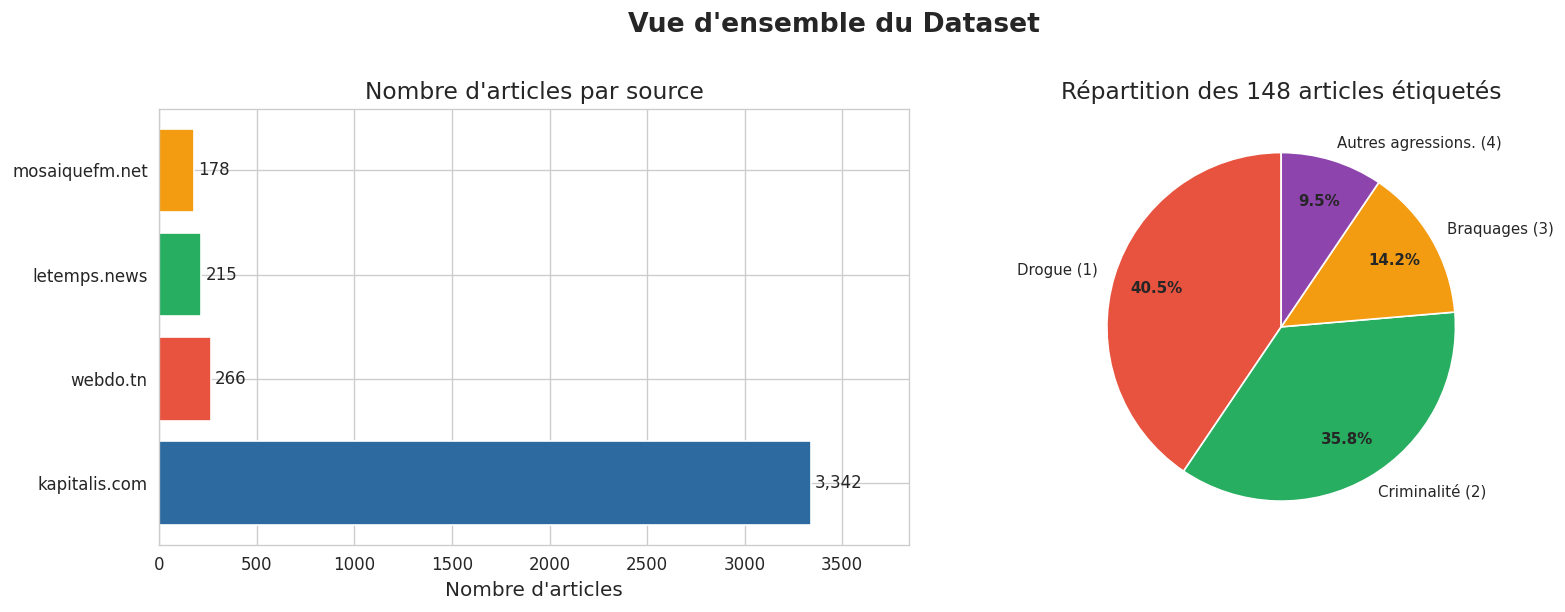

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Vue d\'ensemble du Dataset', fontsize=16, fontweight='bold', y=1.01)

# ── Sources ──
ax = axes[0]
src_counts = df_raw['source'].value_counts()
bars = ax.barh(src_counts.index, src_counts.values,
               color=[PALETTE['primary'], PALETTE['secondary'],
                      PALETTE['accent'], PALETTE['warning']])
for bar, val in zip(bars, src_counts.values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)
ax.set_title('Nombre d\'articles par source')
ax.set_xlabel('Nombre d\'articles')
ax.set_xlim(0, src_counts.max() * 1.15)

# ── Étiquettes (labeled only) ──
ax2 = axes[1]
lbl_counts = df_raw['label'].dropna().value_counts().sort_index()
labels_text = [CAT_LABELS.get(int(k), str(k)) for k in lbl_counts.index]
wedges, texts, autotexts = ax2.pie(
    lbl_counts.values,
    labels=labels_text,
    colors=CAT_COLORS[1:],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title('Répartition des 148 articles étiquetés')

plt.tight_layout()
plt.show()

### 2.2 Déséquilibre des classes (sur les 500 lignes d'entraînement)

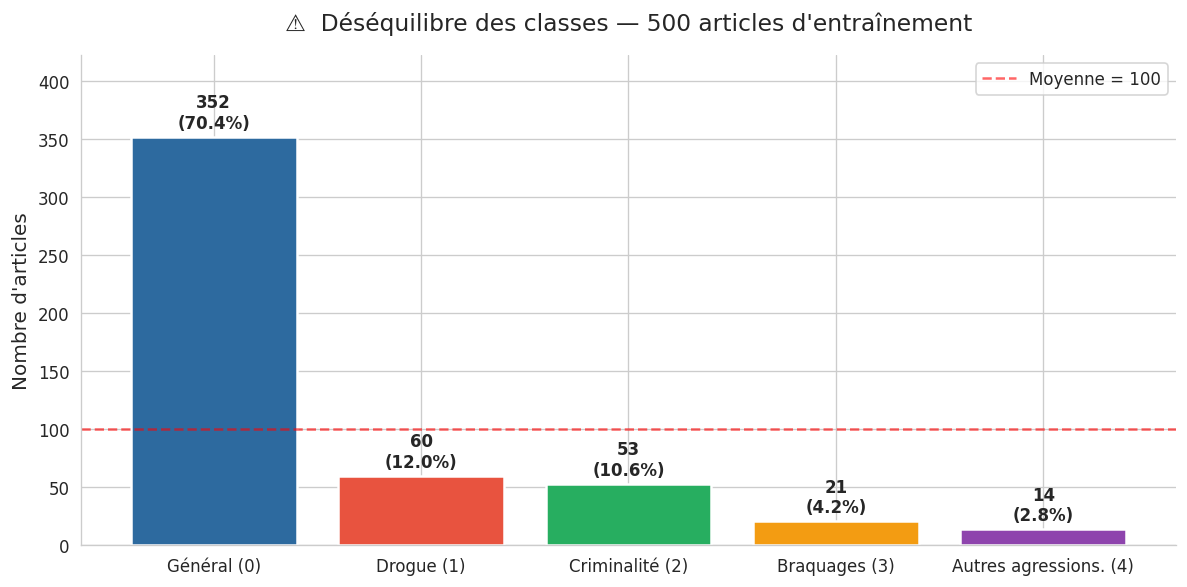


⚠️  Ratio Classe 0 / Classes sécuritaires : 2.4:1
   → Déséquilibre significatif — justifie l'usage de class_weight="balanced"


In [ ]:
df_train = df_raw.head(500).copy()
df_train['label'] = df_train['label'].fillna(0).astype(int)
class_counts = df_train['label'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    [CAT_LABELS[k] for k in class_counts.index],
    class_counts.values,
    color=CAT_COLORS,
    edgecolor='white', linewidth=1.5
)

for bar, val in zip(bars, class_counts.values):
    pct = val / class_counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 4,
            f'{val}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('⚠️  Déséquilibre des classes — 500 articles d\'entraînement',
             fontsize=14, pad=15)
ax.set_ylabel('Nombre d\'articles')
ax.set_ylim(0, class_counts.max() * 1.2)
ax.axhline(y=class_counts.mean(), color='red', linestyle='--', alpha=0.6,
           label=f'Moyenne = {class_counts.mean():.0f}')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

ratio = class_counts[0] / class_counts[1:].sum()
print(f'\n⚠️  Ratio Classe 0 / Classes sécuritaires : {ratio:.1f}:1')
print(f'   → Déséquilibre significatif — justifie l\'usage de class_weight="balanced"')

### 2.3 Distribution temporelle des articles

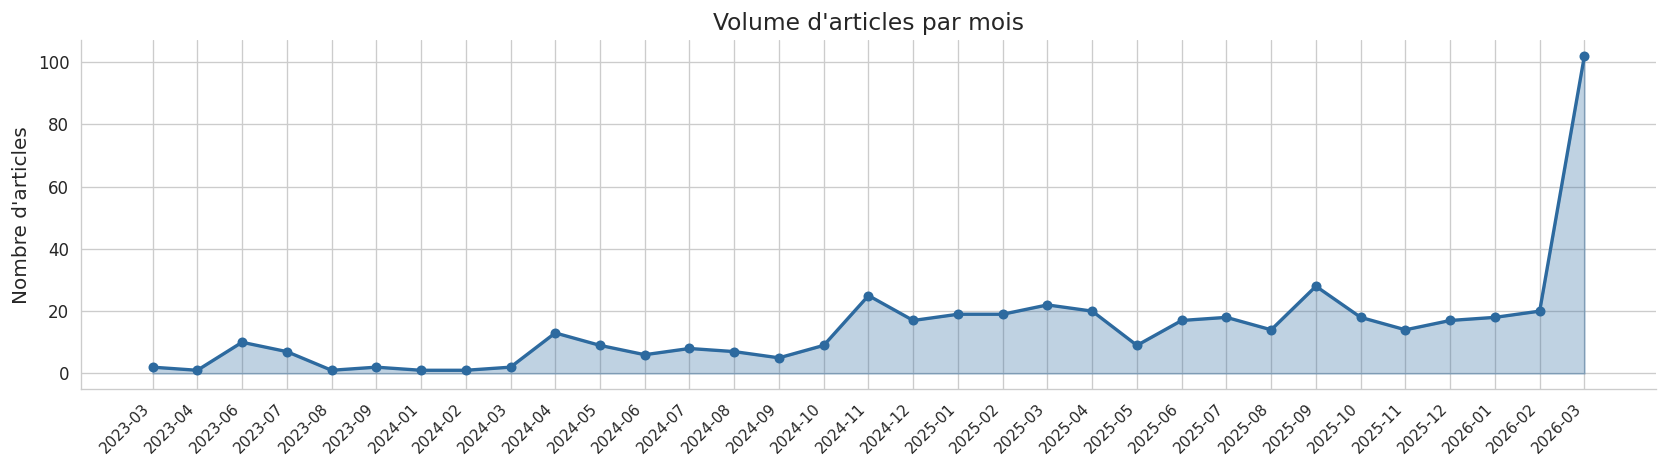

In [ ]:
def extract_year_month(date_str):
    """Extract YYYY-MM from French date strings like 'mardi 3 mars 2026 09:10'"""
    month_map = {
        'janvier': '01', 'février': '02', 'mars': '03', 'avril': '04',
        'mai': '05', 'juin': '06', 'juillet': '07', 'août': '08',
        'septembre': '09', 'octobre': '10', 'novembre': '11', 'décembre': '12'
    }
    if pd.isna(date_str):
        return None
    for m_fr, m_num in month_map.items():
        if m_fr in str(date_str).lower():
            year_match = re.search(r'(\d{4})', str(date_str))
            if year_match:
                return f"{year_match.group(1)}-{m_num}"
    return None

df_raw['year_month'] = df_raw['date'].apply(extract_year_month)
monthly = df_raw['year_month'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(range(len(monthly)), monthly.values,
                alpha=0.3, color=PALETTE['primary'])
ax.plot(range(len(monthly)), monthly.values,
        color=PALETTE['primary'], linewidth=2, marker='o', markersize=5)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Volume d\'articles par mois')
ax.set_ylabel('Nombre d\'articles')
sns.despine()
plt.tight_layout()
plt.show()

### 2.4 Longueur des textes par catégorie

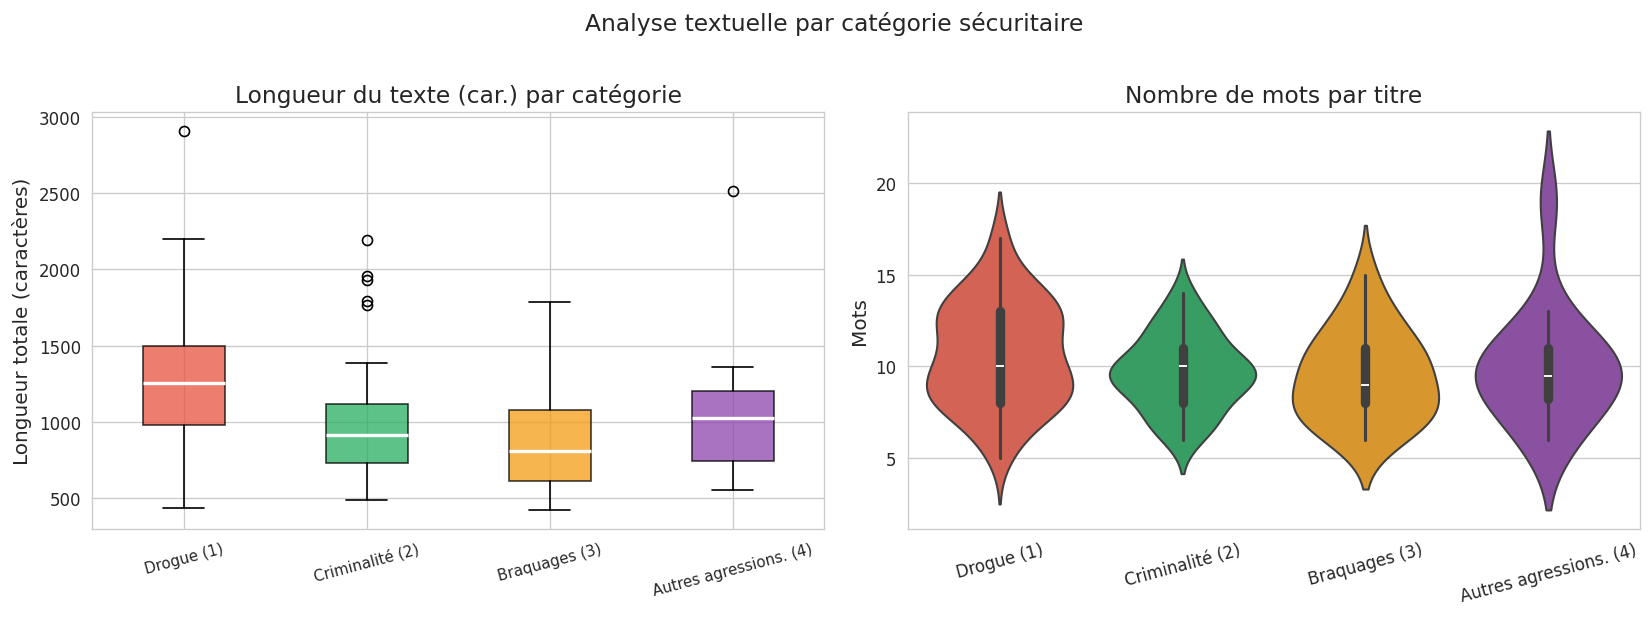

In [ ]:
df_lbl = df_train[df_train['label'] > 0].copy()
df_lbl['text_len'] = (df_lbl['title'].fillna('') + ' ' +
                      df_lbl['tags'].fillna('') + ' ' +
                      df_lbl['description'].fillna('')).apply(len)
df_lbl['cat_label'] = df_lbl['label'].map(CAT_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
categories_order = [CAT_LABELS[i] for i in sorted(df_lbl['label'].unique())]
data_by_cat = [df_lbl[df_lbl['cat_label'] == c]['text_len'].values
               for c in categories_order]
bp = axes[0].boxplot(data_by_cat, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], CAT_COLORS[1:]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_xticklabels(categories_order, rotation=15, fontsize=9)
axes[0].set_title('Longueur du texte (car.) par catégorie')
axes[0].set_ylabel('Longueur totale (caractères)')

# Nombre de mots par titre
df_lbl['title_words'] = df_lbl['title'].fillna('').apply(lambda x: len(x.split()))
sns.violinplot(data=df_lbl, x='cat_label', y='title_words',
               palette=CAT_COLORS[1:], ax=axes[1], order=categories_order, inner='box')
axes[1].set_title('Nombre de mots par titre')
axes[1].set_ylabel('Mots')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Analyse textuelle par catégorie sécuritaire', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.5 Top tags par catégorie

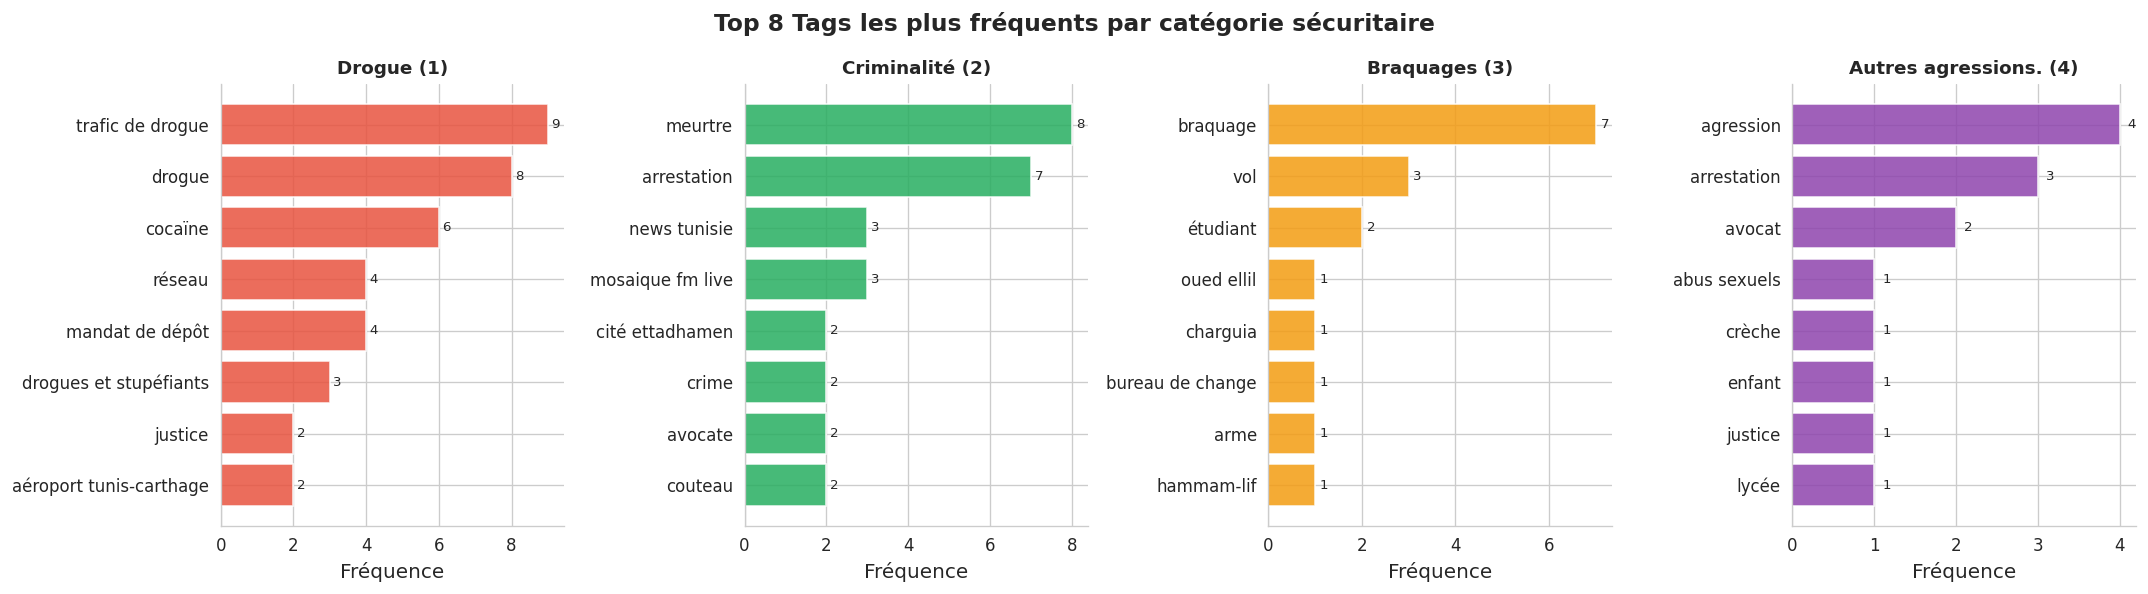

In [ ]:
from collections import Counter

STOP_TAGS = {'tunisie', 'tunis', 'france', '', 'None'}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Top 8 Tags les plus fréquents par catégorie sécuritaire',
             fontsize=14, fontweight='bold')

for ax, cat in zip(axes, [1, 2, 3, 4]):
    subset = df_train[df_train['label'] == cat]['tags'].dropna()
    all_tags = []
    for t in subset:
        all_tags.extend([x.strip().lower() for x in str(t).split('|')
                         if x.strip().lower() not in STOP_TAGS])
    if not all_tags:
        ax.axis('off')
        continue
    top = Counter(all_tags).most_common(8)
    tags, counts = zip(*top)
    bars = ax.barh(tags[::-1], counts[::-1],
                   color=CAT_COLORS[cat], alpha=0.85)
    ax.set_title(CAT_LABELS[cat], fontsize=11, fontweight='bold')
    ax.set_xlabel('Fréquence')
    for bar, val in zip(bars, counts[::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=8)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

---
## 🧹 3. Prétraitement des Données

### 3.1 Nettoyage

In [ ]:
df = df_raw.head(500).copy()

# ── 1. Supprimer les doublons exacts ──
before = len(df)
df = df.drop_duplicates(subset=['title', 'description'], keep='first')
print(f'✂️  Doublons supprimés : {before - len(df)} lignes  ({before} → {len(df)})')

# ── 2. Remplissage des valeurs manquantes ──
df['title']       = df['title'].fillna('')
df['tags']        = df['tags'].fillna('')
df['description'] = df['description'].fillna('')

# ── 3. Label : NaN → 0 ──
df['label'] = df['label'].replace(['', ' ', None], np.nan)
df['label'] = df['label'].fillna(0).astype(int)

# ── 4. Construction du texte unifié ──
df['text'] = df['title'] + ' ' + df['tags'] + ' ' + df['description']

# ── 5. Nettoyage texte ──
def clean_text(text):
    text = re.sub(r'http\S+', '', text)           # URLs
    text = re.sub(r'[^\w\sàâäéèêëîïôùûüç-]', ' ', text)  # Ponctuation
    text = re.sub(r'\s+', ' ', text).strip()       # Espaces multiples
    return text.lower()

df['text_clean'] = df['text'].apply(clean_text)

print()
print('📊 Distribution finale (500 lignes nettoyées) :')
for k, v in df['label'].value_counts().sort_index().items():
    print(f'   Label {k} ({CAT_LABELS[k]:<20}) : {v} articles')
print(f'\n✅ Dataset prêt : {len(df)} lignes × {len(df.columns)} colonnes')

✂️  Doublons supprimés : 76 lignes  (500 → 424)

📊 Distribution finale (500 lignes nettoyées) :
   Label 0 (Général (0)         ) : 276 articles
   Label 1 (Drogue (1)          ) : 60 articles
   Label 2 (Criminalité (2)     ) : 53 articles
   Label 3 (Braquages (3)       ) : 21 articles
   Label 4 (Autres agressions. (4)) : 14 articles

✅ Dataset prêt : 424 lignes × 10 colonnes


### 3.2 Préparation Train / Test

In [ ]:
try:
    nlp = spacy.load('fr_core_news_lg')
except OSError:
    nlp = spacy.load('fr_core_news_sm')
stop_words_french = list(nlp.Defaults.stop_words)

X = df['text_clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Train : {len(X_train)} articles  |  Test : {len(X_test)} articles')
print(f'   Stratification préservée :')
for split_name, split_y in [('Train', y_train), ('Test', y_test)]:
    dist = split_y.value_counts(normalize=True).sort_index()
    print(f'   {split_name}: ' + '  '.join([f'L{k}={v:.0%}' for k, v in dist.items()]))

✅ Train : 339 articles  |  Test : 85 articles
   Stratification préservée :
   Train: L0=65%  L1=14%  L2=12%  L3=5%  L4=3%
   Test: L0=65%  L1=14%  L2=13%  L3=5%  L4=4%


---
## 🤖 4. Comparaison des Modèles

### 4.1 Entraînement de 6 modèles

In [ ]:
# ── Définition des modèles ──
models = {
    'LinearSVC (baseline)': LinearSVC(class_weight='balanced', C=1.0, random_state=42, max_iter=2000),
    'Logistic Regression':  LogisticRegression(class_weight='balanced', C=1.0, max_iter=1000, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Naive Bayes':          MultinomialNB(alpha=0.5),
    'KNN':                  KNeighborsClassifier(n_neighbors=5, metric='cosine'),
}

TFIDF_PARAMS = dict(
    ngram_range=(1, 2),
    max_features=10000,
    stop_words=stop_words_french
)

results = {}
cv_results = {}
print('🚀 Entraînement en cours...\n')

for name, clf in models.items():
    tfidf = TfidfVectorizer(**TFIDF_PARAMS)
    if name == 'Naive Bayes':
        # NB ne supporte pas les valeurs négatives — on utilise min_df
        tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=10000,
                                stop_words=stop_words_french, min_df=1)

    pipeline = Pipeline([('tfidf', tfidf), ('clf', clf)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    f1w  = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    f1m  = f1_score(y_test, y_pred, average='macro', zero_division=0)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {
        'Accuracy': round(acc, 4),
        'F1 Weighted': round(f1w, 4),
        'F1 Macro': round(f1m, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'pipeline': pipeline,
        'y_pred': y_pred
    }

    # 5-fold cross-validation (on full dataset)
    cv = cross_val_score(pipeline, X, y,
                         cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                         scoring='f1_weighted', n_jobs=-1)
    cv_results[name] = cv

    print(f'  ✅ {name:<25} Acc={acc:.3f}  F1w={f1w:.3f}  CV_F1={cv.mean():.3f}±{cv.std():.3f}')

print('\n🏁 Terminé !')

🚀 Entraînement en cours...

  ✅ LinearSVC (baseline)      Acc=0.812  F1w=0.807  CV_F1=0.814±0.040
  ✅ Logistic Regression       Acc=0.800  F1w=0.799  CV_F1=0.823±0.057
  ✅ Random Forest             Acc=0.706  F1w=0.649  CV_F1=0.709±0.033
  ✅ Gradient Boosting         Acc=0.753  F1w=0.733  CV_F1=0.774±0.036
  ✅ Naive Bayes               Acc=0.694  F1w=0.594  CV_F1=0.640±0.011
  ✅ KNN                       Acc=0.718  F1w=0.709  CV_F1=0.723±0.051

🏁 Terminé !


### 4.2 Tableau de comparaison

In [ ]:
df_results = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k not in ('pipeline', 'y_pred')}
    for name, vals in results.items()
}).T

df_results['CV F1 Mean'] = pd.Series({n: cv_results[n].mean().round(4) for n in cv_results})
df_results['CV F1 Std']  = pd.Series({n: cv_results[n].std().round(4)  for n in cv_results})

df_results = df_results.sort_values('F1 Weighted', ascending=False)
df_results.index.name = 'Modèle'

print('📊 COMPARAISON DES MODÈLES (triée par F1 Weighted)')
print('=' * 80)
print(df_results.drop(columns=['F1 Macro']).to_string())
print('=' * 80)
best_model_name = df_results.index[0]
print(f'\n🏆 Meilleur modèle : {best_model_name}')

📊 COMPARAISON DES MODÈLES (triée par F1 Weighted)
                      Accuracy  F1 Weighted  Precision  Recall  CV F1 Mean  CV F1 Std
Modèle                                                                               
LinearSVC (baseline)    0.8118       0.8066     0.8221  0.8118      0.8138     0.0405
Logistic Regression     0.8000       0.7987     0.8236  0.8000      0.8226     0.0566
Gradient Boosting       0.7529       0.7329     0.7268  0.7529      0.7738     0.0359
KNN                     0.7176       0.7085     0.7123  0.7176      0.7232     0.0506
Random Forest           0.7059       0.6490     0.6539  0.7059      0.7090     0.0326
Naive Bayes             0.6941       0.5939     0.5805  0.6941      0.6399     0.0108

🏆 Meilleur modèle : LinearSVC (baseline)


### 4.3 Visualisation comparative

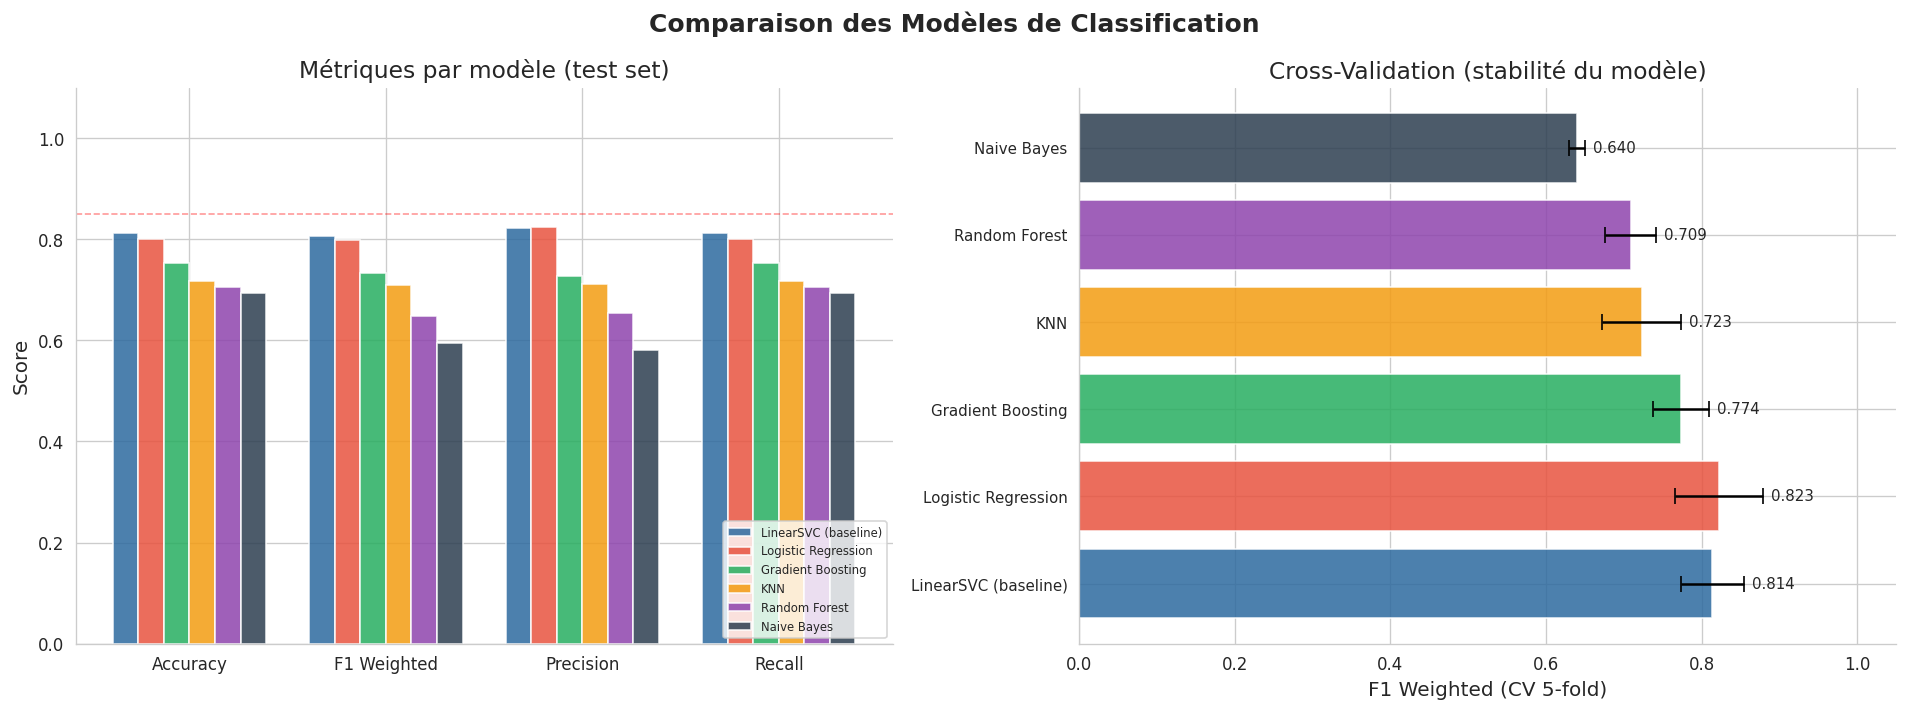

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparaison des Modèles de Classification', fontsize=15, fontweight='bold')

metrics = ['Accuracy', 'F1 Weighted', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.13
bar_colors = [PALETTE['primary'], PALETTE['secondary'], PALETTE['accent'],
              PALETTE['warning'], PALETTE['purple'], PALETTE['dark']]

ax1 = axes[0]
for i, (name, row) in enumerate(df_results.iterrows()):
    offset = (i - len(df_results)/2) * width + width/2
    bars = ax1.bar(x + offset, [row[m] for m in metrics],
                   width, label=name, color=bar_colors[i], alpha=0.85)

ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=10)
ax1.set_ylabel('Score')
ax1.set_ylim(0, 1.1)
ax1.set_title('Métriques par modèle (test set)')
ax1.legend(fontsize=7, loc='lower right')
ax1.axhline(0.85, color='red', linestyle='--', alpha=0.4, linewidth=1)
sns.despine(ax=ax1)

# Cross-Validation
ax2 = axes[1]
cv_means = [cv_results[n].mean() for n in df_results.index]
cv_stds  = [cv_results[n].std()  for n in df_results.index]
bars = ax2.barh(
    range(len(df_results)), cv_means,
    xerr=cv_stds, color=bar_colors[:len(df_results)],
    alpha=0.85, capsize=5, edgecolor='white'
)
ax2.set_yticks(range(len(df_results)))
ax2.set_yticklabels(df_results.index, fontsize=9)
ax2.set_xlabel('F1 Weighted (CV 5-fold)')
ax2.set_title('Cross-Validation (stabilité du modèle)')
ax2.set_xlim(0, 1.05)
for i, (m, s) in enumerate(zip(cv_means, cv_stds)):
    ax2.text(m + s + 0.01, i, f'{m:.3f}', va='center', fontsize=9)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

### 4.4 Matrice de confusion du meilleur modèle

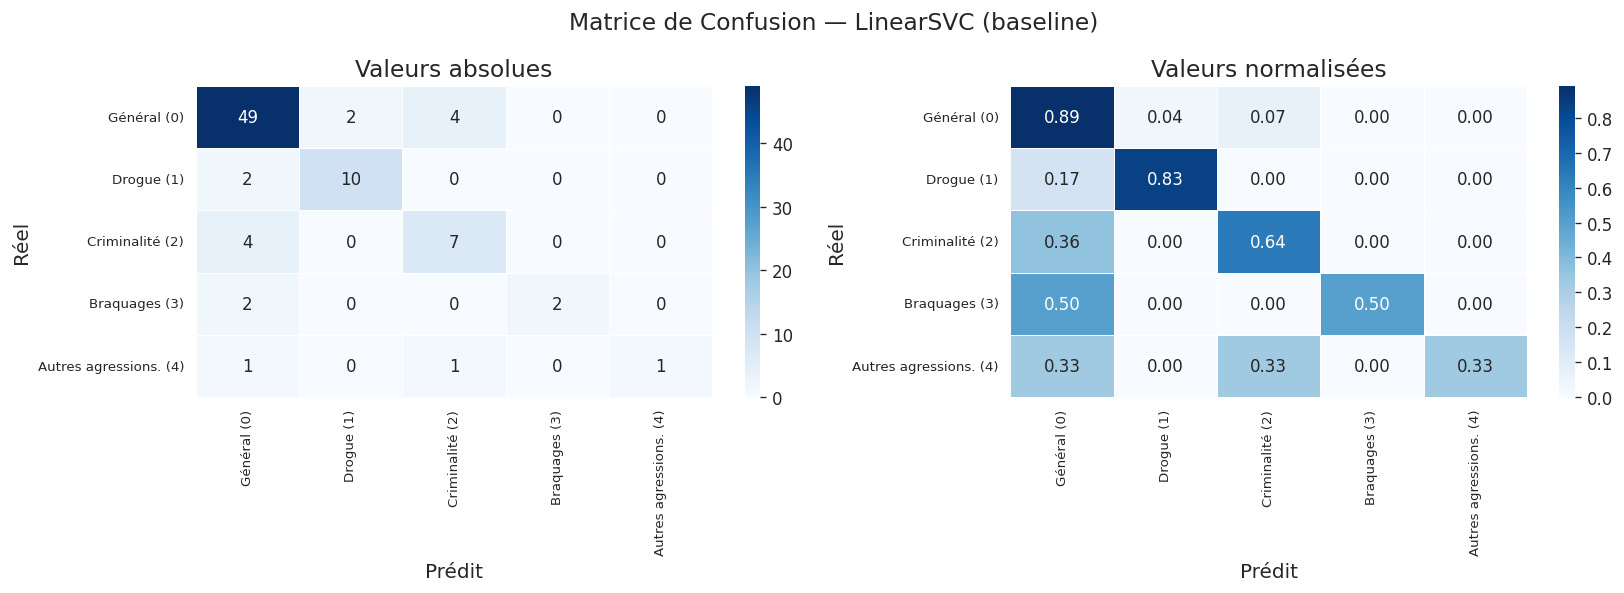


📋 Classification Report — LinearSVC (baseline) :
                        precision    recall  f1-score   support

           Général (0)       0.84      0.89      0.87        55
            Drogue (1)       0.83      0.83      0.83        12
       Criminalité (2)       0.58      0.64      0.61        11
         Braquages (3)       1.00      0.50      0.67         4
Autres agressions. (4)       1.00      0.33      0.50         3

              accuracy                           0.81        85
             macro avg       0.85      0.64      0.70        85
          weighted avg       0.82      0.81      0.81        85



In [ ]:
best_pipeline = results[best_model_name]['pipeline']
best_pred     = results[best_model_name]['y_pred']

cm = confusion_matrix(y_test, best_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
labels = [CAT_LABELS[i] for i in sorted(y_test.unique())]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Matrice de Confusion — {best_model_name}', fontsize=14)

for ax, data, title, fmt in [
    (axes[0], cm,      'Valeurs absolues', 'd'),
    (axes[1], cm_norm, 'Valeurs normalisées', '.2f')
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=ax, linewidths=0.5, linecolor='white',
                annot_kws={'size': 10})
    ax.set_title(title)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')
    ax.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()

print(f'\n📋 Classification Report — {best_model_name} :')
print(classification_report(y_test, best_pred,
                             target_names=labels, zero_division=0))

### 4.5 Rapport détaillé par classe

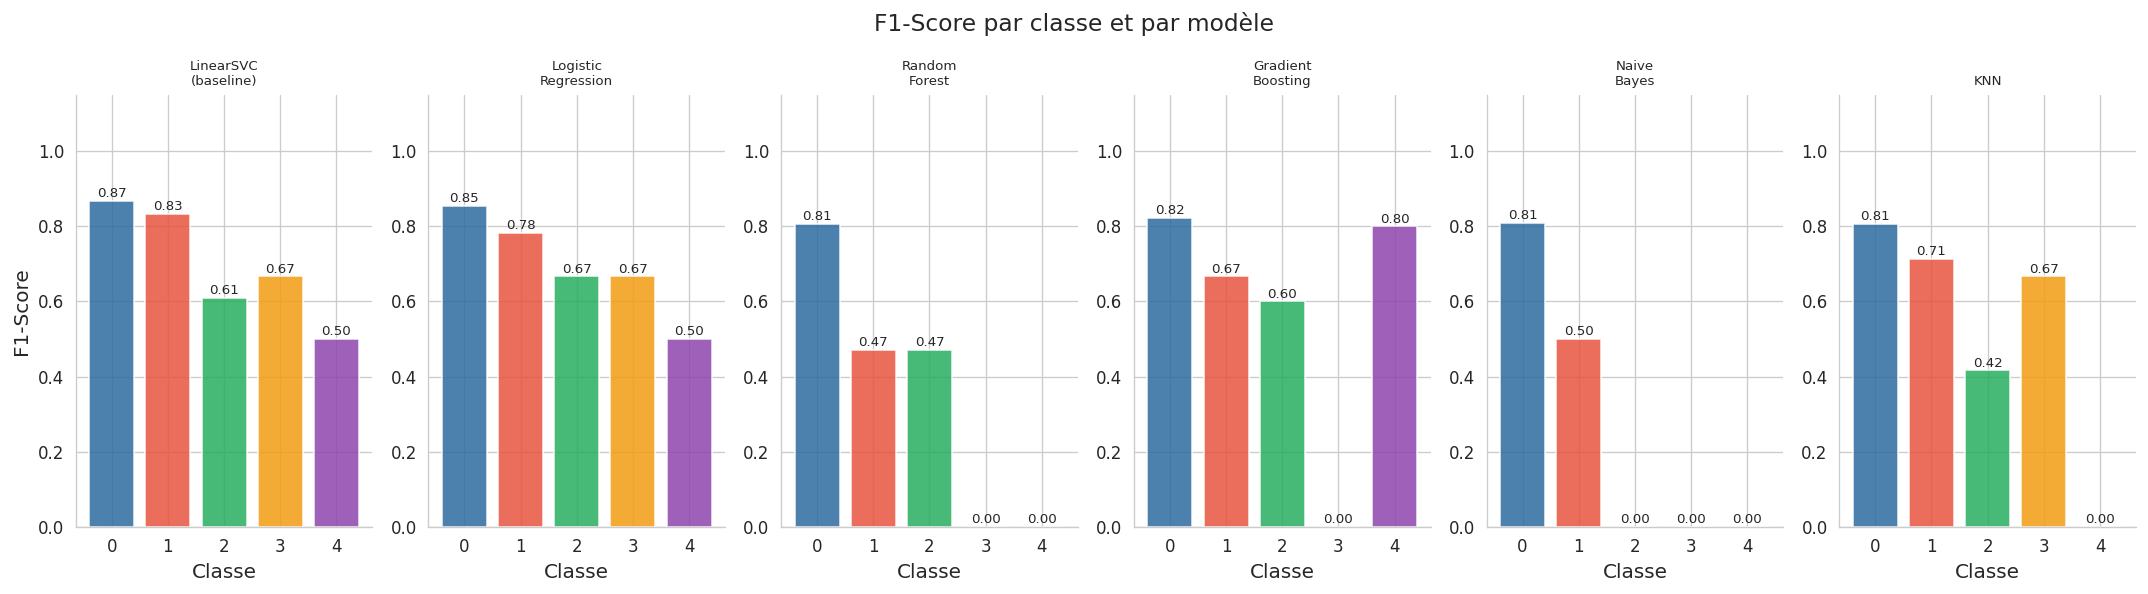

In [ ]:
fig, axes = plt.subplots(1, len(results), figsize=(18, 5))
fig.suptitle('F1-Score par classe et par modèle', fontsize=14)

for ax, (name, vals) in zip(axes, results.items()):
    report = classification_report(y_test, vals['y_pred'],
                                   output_dict=True, zero_division=0)
    classes = [str(k) for k in sorted(y_test.unique())]
    f1s = [report[c]['f1-score'] for c in classes]
    bar_c = [CAT_COLORS[int(c)] for c in classes]
    bars = ax.bar(classes, f1s, color=bar_c, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', fontsize=8)
    ax.set_title(name.replace(' ', '\n'), fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.set_xlabel('Classe')
    if ax == axes[0]:
        ax.set_ylabel('F1-Score')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

---
## 🔧 5. Modèle Final (Pipeline Original Conservé)

### 5.1 Ré-entraînement & sauvegarde

In [ ]:
# ── Le modèle original (LinearSVC) — conservé tel quel ──
final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10000,
        stop_words=stop_words_french
    )),
    ('clf', LinearSVC(class_weight='balanced', C=1.0, random_state=42, max_iter=2000))
])

print('Entraînement en cours...')
final_pipeline.fit(X_train, y_train)

y_pred_final = final_pipeline.predict(X_test)
print('\nRAPPORT DE PERFORMANCE :')
print(classification_report(y_test, y_pred_final,
                             target_names=[CAT_LABELS[i] for i in sorted(y_test.unique())],
                             zero_division=0))

# Ré-entraîner sur les 500 lignes complètes
final_pipeline.fit(X, y)
model_filename = 'modele_securite_v2.joblib'
joblib.dump(final_pipeline, model_filename)
print(f'\nSuccès ! Modèle sauvegardé sous : {model_filename}')

# Test rapide
test_text = "Arrestation d'un dealer avec 500 comprimés de ecstasy à l'Aouina"
prediction = final_pipeline.predict([test_text])[0]
print(f"Test prediction: {test_text}")
print(f"  → Catégorie: {prediction} ({CAT_LABELS[prediction]})")

Entraînement en cours...

RAPPORT DE PERFORMANCE :
                        precision    recall  f1-score   support

           Général (0)       0.84      0.89      0.87        55
            Drogue (1)       0.83      0.83      0.83        12
       Criminalité (2)       0.58      0.64      0.61        11
         Braquages (3)       1.00      0.50      0.67         4
Autres agressions. (4)       1.00      0.33      0.50         3

              accuracy                           0.81        85
             macro avg       0.85      0.64      0.70        85
          weighted avg       0.82      0.81      0.81        85


Succès ! Modèle sauvegardé sous : modele_securite_v2.joblib
Test prediction: Arrestation d'un dealer avec 500 comprimés de ecstasy à l'Aouina
  → Catégorie: 1 (Drogue (1))


### 5.2 Application sur les articles non-étiquetés

In [ ]:
import re as _re

model = joblib.load('modele_securite_v2.joblib')
df_all = pd.read_csv(FILE_PATH, sep=';', encoding='utf-8')
df_rest = df_all.iloc[500:].copy()

def extraire_date_evoluee(row):
    texte_source = f"{row['title']} {row['description']} {row.get('url', '')}"
    match = _re.search(r'(\d{2,4}[/-]\d{1,2}[/-]\d{2,4})', str(texte_source))
    return match.group(1) if match else 'Date inconnue'

results_pred = []
print('Analyse en cours...')
for _, row in df_rest.iterrows():
    texte = f"{row['title']} {row['tags']} {row['description']}"
    cat = model.predict([texte])[0]
    if cat > 0:
        doc = nlp(texte)
        lieux = list(set([ent.text for ent in doc.ents if ent.label_ == 'LOC']))
        results_pred.append({
            'titre':          str(row['title']),
            'categorie':      int(cat),
            'cat_label':      CAT_LABELS[int(cat)],
            'lieux_extraits': ', '.join(lieux),
            'date':           extraire_date_evoluee(row),
            'url':            row.get('url', '')
        })

df_final = pd.DataFrame(results_pred)
df_final.to_csv('analyse_propre.csv', index=False, sep=';', encoding='utf-8-sig')
print(f"Terminé ! {len(df_final)} articles sécuritaires détectés sur {len(df_rest)} articles.")
print(f"Fichier 'analyse_propre.csv' généré.")
print()
print('Distribution des catégories détectées :')
print(df_final['cat_label'].value_counts().to_string())

Analyse en cours...
Terminé ! 348 articles sécuritaires détectés sur 3501 articles.
Fichier 'analyse_propre.csv' généré.

Distribution des catégories détectées :
cat_label
Drogue (1)                225
Criminalité (2)            82
Braquages (3)              28
Autres agressions. (4)     13


---
## 💡 6. Analyse des Erreurs & Pistes d'Amélioration

### 6.1 Analyse des erreurs de classification

In [ ]:
# Recharger le pipeline entraîné sur train set pour l'analyse des erreurs
eval_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=10000,
                              stop_words=stop_words_french)),
    ('clf', LinearSVC(class_weight='balanced', C=1.0, random_state=42, max_iter=2000))
])
eval_pipeline.fit(X_train, y_train)
y_eval_pred = eval_pipeline.predict(X_test)

# Exemples mal classifiés
X_test_df = X_test.reset_index(drop=True)
errors_df = pd.DataFrame({
    'texte':    X_test_df.str[:120],
    'réel':     y_test.reset_index(drop=True),
    'prédit':   y_eval_pred
})
errors = errors_df[errors_df['réel'] != errors_df['prédit']]

print(f'❌ Erreurs de classification : {len(errors)} / {len(y_test)} ({len(errors)/len(y_test)*100:.1f}%)')
print()
print('Exemples d\'erreurs :')
print(errors.head(10).to_string(index=False))

❌ Erreurs de classification : 16 / 85 (18.8%)

Exemples d'erreurs :
                                                                                                                   texte  réel  prédit
meurtre d une avocate à la manouba ses fils suspectés selon son neveux avocate crime manouba tunisie la région de manoub     0       2
tragédie à sousse un retraité italien assassiné dans sa maison de vacances expatriés paolo corsi sousse tunisie sousse l     2       0
sfax neuf plaintes contre un instituteur pour agression sexuelle le juge d instruction au tribunal de première instance      4       0
tunisie meurtre d un enfant de 4 ans enquête en cours et accusation de meurtre prémédité enfant enquête kasserine meurtr     0       2
mahdia de la cruauté d une mère envers ses propres enfants férid ben j ha porte-parole des tribunaux de monastir et mahd     4       2
ils semaient la terreur à ksar hellal ferid ben j ha porte-parole des tribunaux de mahdia et de monastir a indiqué dans   

### 6.2 Synthèse des recommandations

# Notebook 2: KADASTRA BO3 Complete

# KADASTRA — BO3 : Génération de Contrats Immobiliers par NLP
**DSO3 : NLP Engine | Méthodologie : TDSP**

---

## Phase 1 — Business Understanding

### Problème métier
En Tunisie, le marché immobilier souffre de transactions risquées : contrats mal compris, fraudes fréquentes, aucun système de vérification. KADASTRA génère automatiquement des contrats légalement conformes pour **3 types de biens** (vente, location, terrain) et permet au client de les modifier via un chat interactif.

### Pipeline NLP complet
```
DB PostgreSQL (38466 annonces)
        |
        v
Phase NLP 1 — Extraction d'entités (spaCy NER)
        |
        v
Phase NLP 2 — Transformation lexicale (dictionnaire légal)
        |
        v
Phase NLP 3 — Correction grammaticale (LanguageTool)
        |
        v
Phase NLP 4 — Validation des inputs (NER + regex)
        |
        v
RAG : base légale tunisienne (COC + lois)
        |
        v
LLM x3 : Llama-3.1-70B (ESPRIT) | Llama-3-8B (Groq) | Llama-3-70B (Groq)
        |
        v
Comparaison KPIs + Verdict
        |
        v
Chat interactif + Export PDF
```

### Types d'utilisateurs
| Rôle | Type | Permissions |
|------|------|-------------|
| **particulier** | Normal | Clauses location uniquement |
| **investisseur** | Normal | Clauses location + conditions financières |
| **agent** | Pro | Toutes les clauses |
| **banquier** | Pro | Clauses financières uniquement |

### KPIs
| KPI | Description | Target |
|-----|-------------|--------|
| **KPI 3.1** | Clean Contract Rate | > 80% |
| **KPI 3.2** | Error Rate | < 10% |
| **Temps** | Génération initiale | < 10 secondes |

### Phase 5D — Stratégie de comparaison (TDSP)
| Modèle | Plateforme | Type |
|--------|-----------|------|
| **Llama-3.1-70B-Instruct** | ESPRIT TokenFactory | 70B, modèle principal |
| **Llama-3.1-8B-Instant** | Groq | 8B, ultra-rapide |
| **Llama-3.3-70B-Versatile** | Groq | 70B, puissant et rapide |

---

## Installation

In [ ]:
!pip install psycopg2-binary openai fpdf2 pandas tqdm spacy nltk language-tool-python python-dateutil requests -q
!python -m spacy download fr_core_news_sm -q
!python -m spacy download en_core_web_sm -q

import nltk
nltk.download('punkt',                          quiet=True)
nltk.download('averaged_perceptron_tagger',     quiet=True)
nltk.download('punkt_tab',                      quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

print('Installation terminee !')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 25.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 44.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Installation terminee !


---
## Configuration

In [ ]:
import os, re, json, time, requests
import pandas as pd
import psycopg2
import psycopg2.extras
from openai import OpenAI
from tqdm import tqdm

# ── ESPRIT (Llama-3.1-70B) ────────────────────────────────────────────────────
ESPRIT_API_KEY  = 'sk-e8d1f52f7bce4a349af80b4080b24205'
ESPRIT_BASE_URL = 'https://tokenfactory.esprit.tn/api'
ESPRIT_MODEL    = 'hosted_vllm/Llama-3.1-70B-Instruct'
client_llm      = OpenAI(api_key=ESPRIT_API_KEY, base_url=ESPRIT_BASE_URL)

# ── GROQ (Llama-3-8B + Llama-3-70B) ──────────────────────────────────────────
GROQ_API_KEY  = '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'
GROQ_BASE_URL = 'https://api.groq.com/openai/v1/chat/completions'
GROQ_HEADERS  = {'Authorization': f'Bearer {GROQ_API_KEY}', 'Content-Type': 'application/json'}

GROQ_MODELS = {
    'Llama-3-8B':  'llama-3.1-8b-instant',
    'Llama-3-70B': 'llama-3.3-70b-versatile',
}

# ── DB ────────────────────────────────────────────────────────────────────────
DB_CONFIG = {
    'host': 'sami-scraping.duckdns.org', 'port': '5432',
    'database': 'kadastra', 'user': 'kadastra_user', 'password': 'kadastra123'
}
IMAGE_BASE_URL = 'http://sami-scraping.duckdns.org:8081/images'
DATASET_PATH   = '/content/kadastra_training_dataset.jsonl'

print('Configuration chargee')
print(f'  ESPRIT  : {ESPRIT_MODEL}')
print(f'  Groq    : {list(GROQ_MODELS.values())}')
print(f'  Groq Key: {"OK" if GROQ_API_KEY.startswith("gsk_") else "INVALIDE"}')

Configuration chargee
  ESPRIT  : hosted_vllm/Llama-3.1-70B-Instruct
  Groq    : ['llama-3.1-8b-instant', 'llama-3.3-70b-versatile']
  Groq Key: OK


---
## Phase 2 — Data Acquisition

In [ ]:
def get_connection():
    return psycopg2.connect(
        host=DB_CONFIG['host'], port=DB_CONFIG['port'],
        dbname=DB_CONFIG['database'], user=DB_CONFIG['user'],
        password=DB_CONFIG['password'], connect_timeout=10
    )

try:
    conn = get_connection()
    print('Connexion reussie !')
    conn.close()
except Exception as e:
    print(f'Erreur : {e}')

Connexion reussie !


In [ ]:
def fetch_listing(listing_id=None, contract_type=None):
    conn   = get_connection()
    cursor = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)
    if listing_id:
        cursor.execute('SELECT * FROM data WHERE id = %s;', (listing_id,))
    elif contract_type == 'terrain':
        cursor.execute("SELECT * FROM data WHERE prix IS NOT NULL AND LOWER(type) LIKE '%terrain%' ORDER BY RANDOM() LIMIT 1;")
    elif contract_type == 'location':
        cursor.execute("SELECT * FROM data WHERE prix IS NOT NULL AND (LOWER(type) LIKE '%location%' OR LOWER(titre) LIKE '%louer%') ORDER BY RANDOM() LIMIT 1;")
    elif contract_type == 'vente':
        cursor.execute("SELECT * FROM data WHERE prix IS NOT NULL AND LOWER(type) NOT LIKE '%terrain%' AND LOWER(type) NOT LIKE '%location%' ORDER BY RANDOM() LIMIT 1;")
    else:
        cursor.execute('SELECT * FROM data WHERE prix IS NOT NULL ORDER BY RANDOM() LIMIT 1;')
    listing = cursor.fetchone()
    cursor.close(); conn.close()
    return dict(listing) if listing else None

def fetch_batch_listings(limit=10, contract_type=None):
    limit  = int(limit)
    conn   = get_connection()
    cursor = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)
    queries = {
        'terrain':  ("SELECT * FROM data WHERE prix IS NOT NULL AND LOWER(type) LIKE %s ORDER BY RANDOM() LIMIT %s;", ('%terrain%', limit)),
        'location': ("SELECT * FROM data WHERE prix IS NOT NULL AND (LOWER(type) LIKE %s OR LOWER(titre) LIKE %s) ORDER BY RANDOM() LIMIT %s;", ('%location%', '%louer%', limit)),
        'vente':    ("SELECT * FROM data WHERE prix IS NOT NULL AND LOWER(type) NOT LIKE %s AND LOWER(type) NOT LIKE %s ORDER BY RANDOM() LIMIT %s;", ('%terrain%', '%location%', limit)),
    }
    if contract_type in queries:
        sql, params = queries[contract_type]
    else:
        sql, params = 'SELECT * FROM data WHERE prix IS NOT NULL ORDER BY RANDOM() LIMIT %s;', (limit,)
    cursor.execute(sql, params)
    listings = [dict(row) for row in cursor.fetchall()]
    cursor.close(); conn.close()
    return listings

listing = fetch_listing()
if listing:
    print('Annonce recuperee !')
    for k, v in listing.items():
        if v is not None:
            print(f'   {k:25s} : {str(v)[:80]}')
else:
    print('Aucune annonce recuperee.')

Annonce recuperee !
   id                        : 5176
   titre                     : Dar arbi a vendre
   lien                      : https://www.mubawab.tn/fr/a/8150810/dar-arbi-a-vendre
   prix                      : 70 000 TND
   adresse                   : El Attaya à        Kerkennah
   localisation              : 34.745717749570304, 11.295728843010824
   description               : Dar arbi a vendre         dar arbi a vendre composée de : 6 chambres garage jard
   pieces                    : 1
   chambres                  : 6
   salles_de_bain            : 1
   surface                   : 550²
   type                      : Maison a vendre
   date_post                 : 2025-05-27


---
## Phase 3 — Data Exploration

In [ ]:
def explore_database():
    conn   = get_connection()
    cursor = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)
    cursor.execute("SELECT column_name, data_type FROM information_schema.columns WHERE table_name='data' ORDER BY ordinal_position;")
    print('Colonnes table data :')
    for c in cursor.fetchall():
        print(f"   {c['column_name']:30s} -> {c['data_type']}")
    cursor.execute('SELECT COUNT(*) as total FROM data;')
    print(f"\nTotal annonces : {cursor.fetchone()['total']}")
    cursor.execute("SELECT type, COUNT(*) as nb FROM data WHERE type IS NOT NULL GROUP BY type ORDER BY nb DESC LIMIT 15;")
    print('\nDistribution par type :')
    for r in cursor.fetchall():
        print(f"   {str(r['type']):40s} : {r['nb']}")
    cursor.execute("""
        SELECT COUNT(*) FILTER (WHERE LOWER(type) LIKE '%terrain%') as terrains,
               COUNT(*) FILTER (WHERE LOWER(type) LIKE '%location%' OR LOWER(titre) LIKE '%louer%') as locations,
               COUNT(*) FILTER (WHERE LOWER(type) NOT LIKE '%terrain%' AND LOWER(type) NOT LIKE '%location%') as ventes
        FROM data WHERE prix IS NOT NULL;
    """)
    cats = cursor.fetchone()
    print(f"\nVentes={cats['ventes']} | Locations={cats['locations']} | Terrains={cats['terrains']}")
    cursor.close(); conn.close()

explore_database()

Colonnes table data :
   id                             -> integer
   titre                          -> text
   lien                           -> text
   prix                           -> text
   adresse                        -> text
   localisation                   -> text
   description                    -> text
   pieces                         -> text
   chambres                       -> text
   salles_de_bain                 -> text
   surface                        -> text
   type                           -> text
   date_post                      -> date

Total annonces : 27987

Distribution par type :
   Appartement a louer                      : 4988
   Appartement a vendre                     : 4643
   Maison a vendre                          : 3713
   Terrain a vendre                         : 3355
   appartements                             : 2803
   Maison a louer                           : 2152
   maisons-et-villas                        : 1394
   terrains-et-fermes  

---
## Phase 4 — Modelling
### 4A — Pipeline NLP

In [ ]:
import spacy
import language_tool_python
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.tag import pos_tag
from dateutil.parser import parse as parse_date

try:
    nlp = spacy.load('fr_core_news_sm')
    print('Modele spaCy francais charge')
except Exception:
    nlp = spacy.load('en_core_web_sm')
    print('Modele spaCy anglais charge')

tool = language_tool_python.LanguageTool('fr')
print('LanguageTool (fr) charge !')

Modele spaCy francais charge
LanguageTool (fr) charge !


In [ ]:
# NLP STEP 1 — Extraction d'entités nommées (spaCy NER)
def extract_entities_from_listing(listing):
    text_fields = [
        str(listing.get('titre',        '') or ''),
        str(listing.get('description',  '') or ''),
        str(listing.get('localisation', '') or ''),
        str(listing.get('adresse',      '') or ''),
    ]
    full_text = ' '.join([t for t in text_fields if t.strip()])
    doc = nlp(full_text)
    entities = {'lieux': [], 'dates': [], 'montants': [], 'personnes': [], 'organisations': []}
    for ent in doc.ents:
        if ent.label_ in ('LOC', 'GPE', 'LOCATION'):          entities['lieux'].append(ent.text)
        elif ent.label_ in ('DATE', 'TIME'):                   entities['dates'].append(ent.text)
        elif ent.label_ in ('MONEY', 'CARDINAL', 'QUANTITY'):  entities['montants'].append(ent.text)
        elif ent.label_ in ('PER', 'PERSON'):                  entities['personnes'].append(ent.text)
        elif ent.label_ in ('ORG',):                           entities['organisations'].append(ent.text)
    for key in entities:
        entities[key] = list(dict.fromkeys(entities[key]))
    return entities

if listing:
    entities = extract_entities_from_listing(listing)
    print('Entités extraites :')
    for label, values in entities.items():
        if values:
            print(f'   {label:15s} : {values}')

Entités extraites :
   lieux           : ['Dar arbi', 'El Attaya']
   personnes       : ['Kerkennah']


In [ ]:
# NLP STEP 2 — Transformation lexicale
LEGAL_DICTIONARY_FR = {
    'payer':'regler','paiement':'remise de fonds','accord':'convention',
    'contrat':'acte sous seing prive','proprietaire':'bailleur / vendeur',
    'acheteur':'acquereur','locataire':'preneur a bail',
    'loyer':'redevance mensuelle','caution':'depot de garantie',
    'fin':'resiliation','annuler':'resoudre','probleme':'litige',
    'tribunal':'juridiction competente','loi':'disposition legale',
    'droit':'prerogative','devoir':'obligation','reparation':'remise en etat',
    'signature':'apposition de la griffe','date':'date de prise d effet',
    'adresse':'domicile elu','identite':'designation civile',
    'terrain':'parcelle fonciere','maison':'immeuble a usage d habitation',
    'appartement':'fraction d immeuble en copropriete','villa':'residence individuelle',
    'prix':'contrepartie financiere','vente':'cession immobiliere',
    'achat':'acquisition immobiliere','garantie':'garantie contractuelle',
    'defaut':'vice cache','frais':'charges accessoires','taxe':'imposition fiscale',
    'notaire':'officier ministeriel','litige':'differend juridique',
    'surface':'superficie en metres carres','pieces':'elements composant le bien',
}

def transform_to_legal_terms(text):
    sentences = sent_tokenize(text)
    transformed = []
    for sentence in sentences:
        tokens = word_tokenize(sentence.lower())
        tagged = pos_tag(tokens)
        result = [LEGAL_DICTIONARY_FR.get(word, word) for word, _ in tagged]
        transformed.append(' '.join(result).capitalize())
    return ' '.join(transformed)

print('Texte original   :', "L'acheteur doit payer le prix.")
print('Texte transformé :', transform_to_legal_terms("L'acheteur doit payer le prix."))

Texte original   : L'acheteur doit payer le prix.
Texte transformé : L'acheteur doit regler le contrepartie financiere .


In [ ]:
# NLP STEP 3 — Correction grammaticale
GRAMMAR_FIXES_FR = [
    (r'(?i)\bdu moi\b',      'du mois'),
    (r'(?i)\bau moi\b',      'au mois'),
    (r'(?i)\bchaque moi\b',  'chaque mois'),
    (r'(?i)\bpar moi\b',     'par mois'),
    (r'(?i)\bloier\b',       'loyer'),
    (r'(?i)\bcausion\b',     'caution'),
    (r'(?i)\baddresse\b',    'adresse'),
    (r'(?i)\bresiliation\b', 'résiliation'),
    (r'(?i)\bbailleure?\b',  'bailleur'),
]

def correct_text(text):
    sentences = sent_tokenize(text)
    corrected = []
    for sentence in sentences:
        matches = tool.check(sentence)
        corrected.append(language_tool_python.utils.correct(sentence, matches))
    return ' '.join(corrected)

def correct_text_enhanced(text):
    corrected = correct_text(text)
    for pattern, replacement in GRAMMAR_FIXES_FR:
        corrected = re.sub(pattern, replacement, corrected)
    return corrected

test = "Le locataire doit paye le loyer avant le dix du moi."
print('Original  :', test)
print('Corrigé   :', correct_text_enhanced(test))

Original  : Le locataire doit paye le loyer avant le dix du moi.
Corrigé   : Le locataire doit paye le loyer avant le dix du mois.


In [ ]:
# NLP STEP 4 — Validation des inputs
def validate_cin(text):
    text = text.strip().replace(' ', '')
    if re.fullmatch(r'\d{8}', text): return text, None
    return None, 'CIN invalide : doit contenir exactement 8 chiffres.'

def validate_date(text):
    try:
        dt = parse_date(text, dayfirst=True)
        months_fr = ['janvier','fevrier','mars','avril','mai','juin',
                     'juillet','aout','septembre','octobre','novembre','decembre']
        return f'{dt.day}{"er" if dt.day==1 else ""} {months_fr[dt.month-1]} {dt.year}', None
    except:
        return None, 'Date invalide.'

def validate_amount(text):
    cleaned = text.replace(',','.').replace(' ','').replace('DT','').replace('dt','').strip()
    try:
        return f"{float(cleaned):,.0f} DT".replace(',', ' '), None
    except:
        return None, 'Montant invalide.'

def validate_input_smart(user_input):
    t = user_input.strip()
    if re.fullmatch(r'\d{8}', t):
        val, err = validate_cin(t); return val, 'cin', err
    if re.fullmatch(r'\d{1,2}[/\-.\s]\d{1,2}[/\-.\s]\d{2,4}', t):
        val, err = validate_date(t); return val, 'date', err
    if re.fullmatch(r'[\d\s,.]+(\s*dt|\s*dinar|\s*dinars)?', t, re.I):
        val, err = validate_amount(t); return val, 'montant', err
    if 1 <= len(t.split()) <= 5:
        words = t.split()
        return ' '.join(w.capitalize() for w in words), 'nom', None
    return t, 'clause', None

for inp in ['12345678', '01/06/2025', '320000', 'Mohamed Ben Salem']:
    val, typ, err = validate_input_smart(inp)
    print(f'   "{inp:25s}" -> [{typ}] {val if not err else "ERREUR: "+err}')

   "12345678                 " -> [cin] 12345678
   "01/06/2025               " -> [date] 1er juin 2025
   "320000                   " -> [montant] 320 000 DT
   "Mohamed Ben Salem        " -> [nom] Mohamed Ben Salem


### 4B — Base légale tunisienne (RAG)

In [ ]:
TUNISIAN_LEGAL_KNOWLEDGE = {
    'vente': """
CLAUSES OBLIGATOIRES — CONTRAT DE VENTE IMMOBILIERE (Tunisie) :
1. IDENTIFICATION DES PARTIES (Art. 565 COC) — Nom, prenom, CIN, adresse vendeur + acheteur
2. DESCRIPTION DU BIEN (Art. 567 COC) — Gouvernorat, delegation, superficie m2, titre foncier
3. PRIX ET PAIEMENT (Art. 568 COC) — Prix DT en chiffres ET lettres, modalites, penalites 8%/an
4. TRANSFERT DE PROPRIETE (Art. 569 COC) — Date effective, remise cles, etat des lieux
5. GARANTIES (Art. 641-670 COC + Loi 90-17) — Eviction, vices caches, garantie decennale
6. FRAIS ET TAXES — Droits enregistrement 3%, honoraires notariaux 1-2%
7. JURIDICTION — Tribunal de Premiere Instance du lieu du bien
""",
    'location': """
CLAUSES OBLIGATOIRES — CONTRAT DE BAIL (Loi 77-40) :
1. IDENTIFICATION — Bailleur + Locataire (nom, CIN, adresse)
2. BIEN LOUE — Adresse, type, superficie, equipements
3. DUREE — Date debut, date fin, preavis 3 mois
4. LOYER — Montant DT/mois, echeance 1-10 du mois
5. DEPOT GARANTIE — Max 3 mois de loyer, restitution sous 30 jours
6. OBLIGATIONS LOCATAIRE — Paiement, entretien, interdiction sous-location
7. OBLIGATIONS BAILLEUR — Bon etat, grosses reparations
8. RESILIATION — Tribunal de Premiere Instance
""",
    'terrain': """
CLAUSES OBLIGATOIRES — CONTRAT DE TERRAIN (Tunisie) :
1. IDENTIFICATION — Vendeur/Bailleur + Acheteur/Locataire (nom, CIN, adresse)
2. DESCRIPTION TERRAIN — Gouvernorat, delegation, lieu-dit, superficie m2/ha
3. REFERENCE CADASTRALE OBLIGATOIRE — Numero titre foncier, nature (agricole/constructible)
4. LIMITES ET SERVITUDES — Bornes, droits de passage, statut urbanistique
5. PRIX / LOYER — Prix DT/m2 et total, modalites paiement
6. GARANTIES — Superficie, absence hypotheques, eviction (Art. 641 COC)
7. FRAIS — Droits enregistrement 3%, geometre si mesurage
8. JURIDICTION — Tribunal de Premiere Instance
""",
    'general': """
DISPOSITIONS GENERALES : Enregistrement recette des finances sous 30 jours. Droit tunisien (COC).
"""
}
print('Base legale chargee : vente, location, terrain')

Base legale chargee : vente, location, terrain


### 4C — Permissions par rôle

In [ ]:
USER_PERMISSIONS = {
    'particulier':  {'location': ['decoration','animaux','bruit','regles_maison'], 'vente': [], 'terrain': []},
    'investisseur': {'location': ['decoration','animaux','bruit','conditions_financieres','duree_bail'],
                     'vente': ['conditions_financieres','garanties','penalites'],
                     'terrain': ['conditions_financieres','usage_terrain']},
    'agent':        {'location': ['ALL'], 'vente': ['ALL'], 'terrain': ['ALL']},
    'banquier':     {'location': ['loyer','depot_garantie','echeancier','penalites'],
                     'vente': ['prix','modalites_paiement','hypotheque','penalites'],
                     'terrain': ['prix','modalites_paiement','hypotheque']},
}

def get_permission_prompt(user_role, contract_type):
    perms = USER_PERMISSIONS.get(user_role, {}).get(contract_type, [])
    role_labels = {'particulier':'Particulier','investisseur':'Investisseur','agent':'Agent immobilier','banquier':'Banquier'}
    label = role_labels.get(user_role, user_role)
    if not perms:
        return f"ROLE : {label}\nPERMISSIONS : Lecture seule pour {contract_type}. Refuse toute modification poliment."
    if 'ALL' in perms:
        return f"ROLE : {label}\nPERMISSIONS : Accès complet à toutes les clauses."
    return f"ROLE : {label}\nPERMISSIONS : Uniquement : {', '.join(perms)}. Refuse le reste poliment."

print('Permissions chargees pour 4 roles')

Permissions chargees pour 4 roles


### 4D — Génération (LLM x3 + NLP + RAG)

In [ ]:
def ask_vendeur_info():
    print("=== Informations du Vendeur ===")
    nom     = input("Nom complet du vendeur : ").strip()
    cin     = input("CIN du vendeur (8 chiffres) : ").strip()
    adresse = input("Adresse du vendeur : ").strip()
    cin_val, err = validate_cin(cin)
    if err:
        print(f"  ⚠️  {err} — CIN gardé tel quel.")
        cin_val = cin
    return {'nom': nom, 'cin': cin_val, 'adresse': adresse}

def detect_contract_type(listing):
    combined = ' '.join([str(v) for v in listing.values() if v]).lower()
    if any(k in combined for k in ['terrain','parcelle','lot','hectare','agricole','constructible']):
        return 'terrain'
    if any(k in combined for k in ['location','louer','a louer','bail','loyer']):
        return 'location'
    return 'vente'

def format_listing_for_prompt(listing):
    labels = {'id':'ID','titre':'Titre','prix':'Prix (DT)','adresse':'Adresse',
              'localisation':'Localisation','description':'Description',
              'pieces':'Pieces','surface':'Superficie (m2)','type':'Type'}
    lines = []
    for k, v in listing.items():
        if v and str(v).strip() not in ('', 'None'):
            lines.append(f'- {labels.get(k, k)} : {str(v)[:200]}')
    return '\n'.join(lines)

def get_contract_title(contract_type, listing):
    combined = ' '.join([str(v) for v in listing.values() if v]).lower()
    if contract_type == 'terrain':
        return 'CONTRAT DE BAIL DE TERRAIN' if any(k in combined for k in ['louer','location','bail']) else 'CONTRAT DE VENTE DE TERRAIN'
    return {'location': "CONTRAT DE BAIL A USAGE D'HABITATION", 'vente': 'PROMESSE SYNALLAGMATIQUE DE VENTE'}.get(contract_type, 'CONTRAT IMMOBILIER')

def build_enriched_prompt(listing, contract_type, vendeur_info=None):
    """NLP (NER + transformation + correction) + RAG → system_prompt + user_message."""
    # NLP Steps 1-2
    entities      = extract_entities_from_listing(listing)
    listing_info  = format_listing_for_prompt(listing)
    # RAG
    legal_context = TUNISIAN_LEGAL_KNOWLEDGE.get(contract_type, TUNISIAN_LEGAL_KNOWLEDGE['vente'])
    general       = TUNISIAN_LEGAL_KNOWLEDGE['general']

    nlp_enrichment = ''
    if entities['lieux']:    nlp_enrichment += f'- Lieux NER : {", ".join(entities["lieux"][:3])}\n'
    if entities['dates']:    nlp_enrichment += f'- Dates NER : {", ".join(entities["dates"][:2])}\n'
    if entities['montants']: nlp_enrichment += f'- Montants NER : {", ".join(entities["montants"][:2])}\n'

    vendeur_block = (
        f"VENDEUR : {vendeur_info['nom']} | CIN : {vendeur_info['cin']} | Adresse : {vendeur_info['adresse']}"
        if vendeur_info and vendeur_info.get('nom')
        else "VENDEUR : [NOM DU VENDEUR] | CIN : [CIN DU VENDEUR] | Adresse : [ADRESSE DU VENDEUR]"
    )
    system_prompt = (
        "Tu es un juriste expert en droit immobilier tunisien travaillant pour KADASTRA.\n"
        "Tu generes des contrats immobiliers legalement conformes selon le COC tunisien.\n\n"
        f"CONTEXTE LEGAL (RAG) :\n{legal_context}\n{general}\n\n"
        "REGLES : Respecter le COC. Contrat COMPLET avec articles numerotes. Francais juridique formel."
    )
    user_message = (
        f'Genere le contrat : "{get_contract_title(contract_type, listing)}".\n\n'
        f"ANNONCE :\n{listing_info}\n\n"
        f"{vendeur_block}\n\n"
        f"ENTITES NLP :\n{nlp_enrichment if nlp_enrichment else '- Aucune'}\n\n"
        "Genere le contrat complet avec TOUTES les clauses numerotees :"
    )
    return system_prompt, user_message, entities

def save_to_training_dataset(user_message, contract, contract_type, listing, model_label=''):
    entry = {
        'instruction': 'Tu es un juriste expert en droit immobilier tunisien.',
        'input': user_message, 'output': contract,
        'contract_type': contract_type,
        'listing_id': listing.get('id', ''),
        'prix': listing.get('prix', ''),
        'localisation': listing.get('localisation', '') or listing.get('adresse', ''),
        'model': model_label
    }
    with open(DATASET_PATH, 'a', encoding='utf-8') as f:
        f.write(json.dumps(entry, ensure_ascii=False) + '\n')

# ── Routeur LLM universel ─────────────────────────────────────────────────────
def call_groq_model(model_id, system_prompt, user_message, max_new_tokens=3000, temperature=0.2):
    """Appelle un modèle Groq. Retourne (contract_text, generation_time)."""
    payload = {
        "model": model_id,
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_message}
        ],
        "max_tokens":  max_new_tokens,
        "temperature": temperature,
        "stream":      False
    }
    t0       = time.time()
    response = requests.post(GROQ_BASE_URL, headers=GROQ_HEADERS, json=payload, timeout=120)
    gen_time = round(time.time() - t0, 2)
    if response.status_code == 200:
        return response.json()["choices"][0]["message"]["content"].strip(), gen_time
    else:
        raise Exception(f"Groq API Error {response.status_code} : {response.text[:300]}")

def call_llm(system_prompt, user_message, platform='esprit', model_id=None, max_tokens=3000):
    """Routeur universel : ESPRIT ou Groq. Retourne (contract, elapsed, tokens)."""
    if platform == 'esprit':
        model_id = model_id or ESPRIT_MODEL
        start    = time.time()
        response = client_llm.chat.completions.create(
            model=model_id,
            messages=[{'role': 'system', 'content': system_prompt},
                      {'role': 'user',   'content': user_message}],
            max_tokens=max_tokens, temperature=0.2
        )
        elapsed  = round(time.time() - start, 2)
        contract = response.choices[0].message.content
        tokens   = response.usage.total_tokens
        return contract, elapsed, tokens
    elif platform == 'groq':
        model_id = model_id or 'llama-3.1-8b-instant'
        contract, elapsed = call_groq_model(model_id, system_prompt, user_message, max_new_tokens=max_tokens)
        return contract, elapsed, 0
    else:
        raise ValueError(f"Plateforme inconnue : {platform}")

def generate_initial_contract(listing, contract_type=None, vendeur_info=None,
                               platform='esprit', model_id=None, save_dataset=True):
    """Génère un contrat avec NLP + RAG + LLM (ESPRIT ou Groq)."""
    if contract_type is None:
        contract_type = detect_contract_type(listing)
    system_prompt, user_message, entities = build_enriched_prompt(listing, contract_type, vendeur_info)
    contract, elapsed, tokens = call_llm(system_prompt, user_message, platform, model_id)
    messages = [
        {'role': 'system',    'content': system_prompt},
        {'role': 'user',      'content': user_message},
        {'role': 'assistant', 'content': contract}
    ]
    if save_dataset:
        label = model_id or ESPRIT_MODEL
        save_to_training_dataset(user_message, contract, contract_type, listing, label)
    return {
        'contract': contract, 'messages': messages,
        'contract_type': contract_type,
        'generation_time': elapsed, 'tokens_used': tokens,
        'nlp_entities': entities, 'vendeur_info': vendeur_info,
        'platform': platform, 'model_id': model_id or ESPRIT_MODEL,
        'modifications': 0
    }

# ── Test initial avec les 3 modèles sur la même annonce ──────────────────────
print('=== Génération initiale avec les 3 modèles ===\n')
sessions_init = {}
models_init = [
    ('Llama-3.1-70B (ESPRIT)', 'esprit',  ESPRIT_MODEL),
    ('Llama-3-8B (Groq)',      'groq',    'llama-3.1-8b-instant'),
    ('Llama-3-70B (Groq)',     'groq',    'llama-3.3-70b-versatile'),
]
for label, platform, mid in models_init:
    print(f'  Génération [{label}]...', end=' ', flush=True)
    try:
        sess = generate_initial_contract(listing, platform=platform, model_id=mid, save_dataset=True)
        sessions_init[label] = sess
        print(f'✅ {sess["generation_time"]}s | Type={sess["contract_type"]}')
    except Exception as e:
        print(f'❌ Erreur : {e}')

# Garder la session ESPRIT comme session principale pour la suite
contract_session = sessions_init.get('Llama-3.1-70B (ESPRIT)', list(sessions_init.values())[0])
print(f'\nSession principale : {contract_session["contract_type"]} | {contract_session["platform"]}')

=== Génération initiale avec les 3 modèles ===

  Génération [Llama-3.1-70B (ESPRIT)]... ✅ 38.23s | Type=vente
  Génération [Llama-3-8B (Groq)]... ✅ 3.39s | Type=vente
  Génération [Llama-3-70B (Groq)]... ✅ 3.5s | Type=vente

Session principale : vente | esprit


### 4E — Modification avec permissions (3 modèles)

In [ ]:
def modify_contract(contract_session, client_request, user_role='particulier'):
    """Modifie un contrat via le LLM de la session (ESPRIT ou Groq)."""
    contract_type = contract_session['contract_type']
    platform      = contract_session.get('platform', 'esprit')
    model_id      = contract_session.get('model_id', ESPRIT_MODEL)
    perms = USER_PERMISSIONS.get(user_role, {}).get(contract_type, [])
    if not perms:
        msg = f"Rôle {user_role} : lecture seule pour {contract_type}. Contactez un agent."
        print(f'  [REFUS] {msg}')
        return {**contract_session, 'last_error': msg}
    corrected = correct_text_enhanced(client_request)
    full_request = (
        f"{get_permission_prompt(user_role, contract_type)}\n\n"
        f"Demande : {corrected}\n"
        "Fournis le contrat COMPLET si autorisé, sinon refuse poliment."
    )
    system_prompt = contract_session['messages'][0]['content']
    contract, elapsed, _ = call_llm(system_prompt, full_request, platform, model_id)
    messages = contract_session['messages'].copy()
    messages.append({'role': 'user',      'content': full_request})
    messages.append({'role': 'assistant', 'content': contract})
    print(f'Modification en {elapsed}s | Role : {user_role} | Plateforme : {platform} | Modèle : {model_id}')
    return {**contract_session, 'contract': contract, 'messages': messages,
            'modifications': contract_session.get('modifications', 0) + 1}

print('modify_contract() pret pour les 3 modèles !')

modify_contract() pret pour les 3 modèles !


### 4F — Chat interactif (3 modèles)

In [ ]:
def contract_chat_assistant(contract_session, user_role='particulier'):
    """Chat interactif utilisant le LLM de la session (ESPRIT ou Groq)."""
    contract_type = contract_session['contract_type']
    platform      = contract_session.get('platform', 'esprit')
    model_id      = contract_session.get('model_id', ESPRIT_MODEL)
    perms    = USER_PERMISSIONS.get(user_role, {}).get(contract_type, [])
    perm_str = 'TOUTES' if 'ALL' in perms else (', '.join(perms) if perms else 'LECTURE SEULE')
    print(f'KADASTRA CHAT | Type={contract_type.upper()} | Role={user_role.upper()} | Plateforme={platform.upper()} | Permissions={perm_str}')
    print('Tapez "done" pour terminer.')
    print('='*60)
    conversation_history = []
    system_prompt = (
        "Tu es un assistant juridique immobilier tunisien expert.\n"
        f"{get_permission_prompt(user_role, contract_type)}\n\n"
        f"Contrat :\n{contract_session['contract']}"
    )
    while True:
        user_input = input(f'[Q#{len(conversation_history)//2+1}] Client : ').strip()
        if not user_input: continue
        if user_input.lower() in ('done','fin','exit','quitter'):
            print('Au revoir !')
            break
        conversation_history.append({'role': 'user', 'content': user_input})
        try:
            # Construire le message combiné pour call_llm
            combined_user = '\n'.join([m['content'] for m in conversation_history if m['role']=='user'][-1:])
            answer, _, _ = call_llm(system_prompt, combined_user, platform, model_id, max_tokens=500)
            conversation_history.append({'role': 'assistant', 'content': answer})
            print(f'  Assistant [{platform}] : {answer}\n')
        except Exception as e:
            print(f'  [Erreur] {e}')
    return contract_session

contract_session = contract_chat_assistant(contract_session, user_role='particulier')

KADASTRA CHAT | Type=VENTE | Role=PARTICULIER | Plateforme=ESPRIT | Permissions=LECTURE SEULE
Tapez "done" pour terminer.
[Q#1] Client : done
Au revoir !


### 4G — Dataset + Fine-tuning LoRA (données des 3 modèles)

In [ ]:
import re
import time
import json
from tqdm import tqdm

def build_training_dataset(n_per_type=10):
    n_per_type  = int(n_per_type)
    MAX_RETRIES = 5
    BASE_SLEEP  = {'esprit': 0.5, 'groq': 2.0}

    models_for_dataset = [
        ('esprit', ESPRIT_MODEL,              'Llama-3.1-70B (ESPRIT)'),
        ('groq',   'llama-3.1-8b-instant',    'Llama-3-8B (Groq)'),
        ('groq',   'llama-3.3-70b-versatile', 'Llama-3-70B (Groq)'),
    ]
    total_expected = n_per_type * 3 * len(models_for_dataset)
    print(f'Dataset : {n_per_type} annonces x 3 types x {len(models_for_dataset)} modèles = {total_expected} exemples attendus')
    open(DATASET_PATH, 'w').close()
    total = 0

    for platform, model_id, model_label in models_for_dataset:
        print(f'\n  Génération avec [{model_label}]...')
        for ctype in ['vente', 'location', 'terrain']:
            listings = fetch_batch_listings(limit=n_per_type, contract_type=ctype)
            for lst in tqdm(listings, desc=f'{model_label} / {ctype}'):
                success = False
                for attempt in range(1, MAX_RETRIES + 1):
                    try:
                        generate_initial_contract(lst, ctype, platform=platform,
                                                  model_id=model_id, save_dataset=True)
                        total  += 1
                        success = True
                        time.sleep(BASE_SLEEP[platform])
                        break
                    except Exception as e:
                        err_str = str(e)
                        match   = re.search(r'try again in\s+([\d.]+)s', err_str, re.I)
                        wait    = float(match.group(1)) + 2 if match else (2 ** attempt) * 3
                        if '429' in err_str:
                            print(f'\n    [429 – tentative {attempt}/{MAX_RETRIES}] Attente {wait:.1f}s… (annonce {lst.get("id")})')
                            time.sleep(wait)
                        else:
                            print(f'\n    Erreur {lst.get("id")}: {e}')
                            break
                if not success:
                    print(f'    ⚠️  Abandon annonce {lst.get("id")} après {MAX_RETRIES} tentatives.')

    print(f'\nDataset final : {DATASET_PATH} ({total}/{total_expected} exemples)')
    if total > 0:
        from google.colab import files
        files.download(DATASET_PATH)
    return DATASET_PATH

dataset_path = build_training_dataset(n_per_type=3)

Dataset : 3 annonces x 3 types x 3 modèles = 27 exemples attendus

  Génération avec [Llama-3.1-70B (ESPRIT)]...


Llama-3.1-70B (ESPRIT) / terrain: 100%|██████████| 3/3 [01:17<00:00, 25.70s/it]



  Génération avec [Llama-3-8B (Groq)]...


Llama-3-8B (Groq) / vente:  33%|███▎      | 1/3 [00:04<00:09,  4.82s/it]


    [429 – tentative 1/5] Attente 20.4s… (annonce 7188)


...


    [429 – tentative 1/5] Attente 4.3s… (annonce 10192)


Llama-3-70B (Groq) / terrain: 100%|██████████| 3/3 [00:18<00:00,  6.18s/it]


Dataset final : /content/kadastra_training_dataset.jsonl (27/27 exemples)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForSeq2Seq
from peft import LoraConfig, get_peft_model, TaskType
import torch

# ── Free any leftover GPU memory ──────────────────────────────────────────────
torch.cuda.empty_cache()

BASE_MODEL = 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'
tokenizer  = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer.pad_token = tokenizer.eos_token

model_lora = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    dtype=torch.float16,        # fixed: torch_dtype → dtype
    device_map='auto'
)
model_lora = get_peft_model(model_lora, LoraConfig(
    task_type=TaskType.CAUSAL_LM, r=8,         # reduced: 16 → 8
    lora_alpha=16,                              # reduced: 32 → 16
    lora_dropout=0.1,
    target_modules=['q_proj','v_proj'],
    bias='none'
))
model_lora.print_trainable_parameters()
model_lora.enable_input_require_grads()

def fmt(ex):
    return {'text': f"<|system|>\n{ex['instruction']}\n<|user|>\n{ex['input']}\n<|assistant|>\n{ex['output']}"}

def tok(ex):
    r = tokenizer(
        ex['text'],
        truncation=True,
        max_length=512,         # reduced: 2048 → 512  (biggest memory win)
        padding='max_length'
    )
    r['labels'] = r['input_ids'].copy()
    return r

entries = [json.loads(l) for l in open(DATASET_PATH) if l.strip()]
print(f'Exemples chargés : {len(entries)} (issus des 3 modèles)')

base_dataset = Dataset.from_list(entries).map(fmt)
dataset      = base_dataset.map(tok, remove_columns=base_dataset.column_names)
split        = dataset.train_test_split(test_size=0.2, seed=42)

trainer = Trainer(
    model=model_lora,
    args=TrainingArguments(
        output_dir='/content/kadastra_lora',
        num_train_epochs=3,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=8,   # increased: 4 → 8 to compensate smaller batch
        learning_rate=2e-4,
        fp16=True,
        logging_steps=5,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        report_to='none',
        dataloader_pin_memory=False,     # saves extra GPU memory
    ),
    train_dataset=split['train'],
    eval_dataset=split['test'],
    processing_class=tokenizer,
    data_collator=DataCollatorForSeq2Seq(
        tokenizer, model=model_lora,
        padding=True,
        pad_to_multiple_of=8
    )
)

trainer.train()
model_lora.save_pretrained('/content/kadastra_lora_final')
tokenizer.save_pretrained('/content/kadastra_lora_final')
print('LoRA fine-tuning terminé ! Dataset issu des 3 modèles.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023
Exemples chargés : 27 (issus des 3 modèles)


Map:   0%|          | 0/27 [00:00<?, ? examples/s]

Map:   0%|          | 0/27 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Epoch,Training Loss,Validation Loss
1,No log,2.045020
2,2.050801,1.998135
3,2.050801,1.979327


LoRA fine-tuning terminé ! Dataset issu des 3 modèles.


---
## Phase 5 — Evaluation
### 5A — KPIs

In [ ]:
def evaluate_contract_quality(contract_text, contract_type='vente'):
    c = contract_text.lower()
    clauses = {
        'vente':    {'Identification':['vendeur','acheteur','cin','acquereur'],
                     'Description':   ['superficie','adresse','localisation','designation'],
                     'Prix':          ['prix','dinars','contrepartie','somme'],
                     'Transfert':     ['propriete','cles','remise','livraison','possession','transfert'],
                     'Garanties':     ['garantie','vice','eviction','hypotheque'],
                     'Frais':         ['frais','enregistrement','honoraires','charge'],
                     'Juridiction':   ['tribunal','juridiction','competent'],
                     'Signatures':    ['signature','signe','seing']},
        'location': {'Identification':['bailleur','locataire','cin','vendeur'],
                     'Description':   ['superficie','adresse','localisation','designation'],
                     'Duree':         ['duree','debut','fin','mois','annee','terme'],
                     'Loyer':         ['loyer','dinars','redevance','mensualite'],
                     'Depot':         ['garantie','depot','caution'],
                     'Obligations':   ['obligation','interdit','autoris','usage'],
                     'Resiliation':   ['resiliation','tribunal','resoudre','terme'],
                     'Signatures':    ['signature','signe','seing']},
        'terrain':  {'Identification':['vendeur','acheteur','cin','acquereur','bailleur'],
                     'Description':   ['terrain','superficie','parcelle','situe'],
                     'Cadastre':      ['titre foncier','cadastr','foncier','reference','numero'],
                     'Nature':        ['agricole','constructible','nature','usage','type'],
                     'Prix':          ['prix','dinars','contrepartie','somme','fixe'],
                     'Transfert':     ['libre','hypotheque','droit reel','transfert','propriete','possession'],
                     'Garanties':     ['garantie','servitude','vice','eviction','conforme'],
                     'Juridiction':   ['tribunal','juridiction','competent','litige']}
    }
    selected = clauses.get(contract_type, clauses['vente'])
    results  = {name: any(kw in c for kw in kws) for name, kws in selected.items()}
    score    = sum(results.values())
    total    = len(results)
    return {'clean_contract_rate': round(score/total*100, 1),
            'error_rate':          round((total-score)/total*100, 1),
            'clauses_found': score, 'clauses_total': total,
            'missing_clauses': [n for n, f in results.items() if not f],
            'clause_details': results, 'is_clean': score/total >= 0.8}

# Evaluer les 3 sessions initiales
print('=== KPIs — Génération initiale (3 modèles) ===')
for label, sess in sessions_init.items():
    ev = evaluate_contract_quality(sess['contract'], sess['contract_type'])
    status = 'OK' if ev['clean_contract_rate'] >= 80 else 'ATTENTION'
    print(f'  [{label}] CCR={ev["clean_contract_rate"]}% [{status}] | Err={ev["error_rate"]}% | Temps={sess["generation_time"]}s')

=== KPIs — Génération initiale (3 modèles) ===
  [Llama-3.1-70B (ESPRIT)] CCR=100.0% [OK] | Err=0.0% | Temps=38.23s
  [Llama-3-8B (Groq)] CCR=100.0% [OK] | Err=0.0% | Temps=3.39s
  [Llama-3-70B (Groq)] CCR=100.0% [OK] | Err=0.0% | Temps=3.5s


### 5B — Export PDF

In [ ]:
from fpdf import FPDF
from fpdf.enums import XPos, YPos
import unicodedata

def clean_text_for_pdf(text):
    for old, new in [('—','-'),('\u2019',"'"),('\u201c','"'),('\u201d','"'),('•','-')]:
        text = text.replace(old, new)
    text = unicodedata.normalize('NFKD', text)
    return re.sub(r'[^\x20-\x7E\n\t\xC0-\xFF]', '', text)

def safe_text(text, max_len=95):
    result = []
    for line in text.split('\n'):
        while len(line) > max_len:
            result.append(line[:max_len]); line = line[max_len:]
        result.append(line)
    return '\n'.join(result)

def generate_pdf_contract(contract_text, listing, contract_type, model_label='LLM', n_modifications=0, output_path=None):
    os.makedirs('/content/contracts', exist_ok=True)
    pdf = FPDF()
    pdf.set_auto_page_break(auto=True, margin=15)
    pdf.add_page()
    pdf.set_font('Helvetica', 'B', 20); pdf.set_text_color(0,120,100)
    pdf.cell(0, 10, 'KADASTRA', align='C', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
    pdf.set_font('Helvetica', '', 11); pdf.set_text_color(100,100,100)
    pdf.cell(0, 7, f'Modele : {model_label} | {n_modifications} modification(s)', align='C', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
    pdf.set_draw_color(0,120,100); pdf.line(10, pdf.get_y()+3, 200, pdf.get_y()+3); pdf.ln(8)
    pdf.set_font('Helvetica', 'B', 14); pdf.set_text_color(0,0,0)
    titles = {'vente':'PROMESSE SYNALLAGMATIQUE DE VENTE','location':"BAIL A USAGE D'HABITATION",'terrain':'VENTE / BAIL DE TERRAIN'}
    pdf.cell(0, 10, f'CONTRAT : {titles.get(contract_type,"IMMOBILIER")}', align='C', new_x=XPos.LMARGIN, new_y=YPos.NEXT)
    pdf.ln(5)
    pdf.set_font('Helvetica', '', 10); pdf.set_text_color(0,0,0)
    for line in safe_text(clean_text_for_pdf(contract_text)).split('\n'):
        if not line.strip(): pdf.ln(3); continue
        if line.strip().upper() == line.strip() and len(line.strip()) > 5:
            pdf.set_font('Helvetica','B',10); pdf.set_text_color(0,80,60)
            pdf.multi_cell(0, 6, line.strip(), new_x=XPos.LMARGIN, new_y=YPos.NEXT)
            pdf.set_font('Helvetica','',10); pdf.set_text_color(0,0,0)
        else:
            pdf.multi_cell(0, 5, line.strip(), new_x=XPos.LMARGIN, new_y=YPos.NEXT)
    if output_path is None:
        output_path = f"/content/contracts/contrat_{contract_type}_{listing.get('id','x')}.pdf"
    pdf.output(output_path)
    return output_path

# Exporter les PDFs pour les 3 modèles
from google.colab import files
os.makedirs('/content/contracts', exist_ok=True)

for label, sess in sessions_init.items():
    safe_label = label.replace(' ','_').replace('(','').replace(')','')
    path = f"/content/contracts/contrat_{sess['contract_type']}_{safe_label}.pdf"
    pdf_path = generate_pdf_contract(
        sess['contract'], listing, sess['contract_type'],
        model_label=label, n_modifications=sess.get('modifications',0),
        output_path=path
    )
    print(f'PDF créé : {pdf_path}')
    files.download(pdf_path)

PDF créé : /content/contracts/contrat_vente_Llama-3.1-70B_ESPRIT.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PDF créé : /content/contracts/contrat_vente_Llama-3-8B_Groq.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PDF créé : /content/contracts/contrat_vente_Llama-3-70B_Groq.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 5C — Batch test (3 modèles)

In [ ]:
def batch_test_all_types(n_per_type=3):
    """Batch test des 3 modèles sur tous les types de contrats."""
    models_batch = [
        ('Llama-3.1-70B (ESPRIT)', 'esprit', ESPRIT_MODEL),
        ('Llama-3-8B (Groq)',      'groq',   'llama-3.1-8b-instant'),
        ('Llama-3-70B (Groq)',     'groq',   'llama-3.3-70b-versatile'),
    ]
    all_batch_results = {}
    for model_label, platform, model_id in models_batch:
        print(f'\n=== Batch [{model_label}] ===')
        results = {}
        for ctype in ['vente', 'location', 'terrain']:
            listings = fetch_batch_listings(limit=n_per_type, contract_type=ctype)
            if not listings: continue
            scores = []
            for lst in tqdm(listings, desc=f'{ctype}'):
                try:
                    session = generate_initial_contract(lst, ctype, platform=platform,
                                                        model_id=model_id, save_dataset=False)
                    ev      = evaluate_contract_quality(session['contract'], ctype)
                    scores.append(ev['clean_contract_rate'])
                except Exception as e:
                    print(f'  Erreur {lst.get("id")}: {e}')
            if scores:
                results[ctype] = {'mean_ccr': round(sum(scores)/len(scores),1), 'n': len(scores)}
                status = 'OK' if results[ctype]['mean_ccr'] >= 80 else 'ATTENTION'
                print(f'  {ctype:10s} : CCR={results[ctype]["mean_ccr"]}% [{status}] (n={results[ctype]["n"]})')
        all_batch_results[model_label] = results
    return all_batch_results

batch_results = batch_test_all_types(n_per_type=3)


=== Batch [Llama-3.1-70B (ESPRIT)] ===


vente: 100%|██████████| 3/3 [01:20<00:00, 26.97s/it]


  vente      : CCR=100.0% [OK] (n=3)


location: 100%|██████████| 3/3 [01:18<00:00, 26.21s/it]


  location   : CCR=100.0% [OK] (n=3)


...

  Erreur 2087: Groq API Error 429 : {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kp5pw222ec8bvr4sh73e4bqw` service tier `on_demand` on tokens per minute (TPM): Limit 12000, Used 11638, Requested 1719. Please try again in 6.784999999s. Need more tokens? Upgrade to Dev Tier today at 


terrain:  67%|██████▋   | 2/3 [00:00<00:00,  9.08it/s]

  Erreur 10616: Groq API Error 429 : {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kp5pw222ec8bvr4sh73e4bqw` service tier `on_demand` on tokens per minute (TPM): Limit 12000, Used 11332, Requested 1569. Please try again in 4.505s. Need more tokens? Upgrade to Dev Tier today at https:
  Erreur 11154: Groq API Error 429 : {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kp5pw222ec8bvr4sh73e4bqw` service tier `on_demand` on tokens per minute (TPM): Limit 12000, Used 11310, Requested 1560. Please try again in 4.35s. Need more tokens? Upgrade to Dev Tier today at https:/


terrain: 100%|██████████| 3/3 [00:00<00:00,  9.33it/s]

  Erreur 22320: Groq API Error 429 : {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kp5pw222ec8bvr4sh73e4bqw` service tier `on_demand` on tokens per minute (TPM): Limit 12000, Used 11290, Requested 3668. Please try again in 14.79s. Need more tokens? Upgrade to Dev Tier today at https:


---
## Phase 5D — Comparaison 3 Modèles LLM
*(Llama-3.1-70B [ESPRIT] vs Llama-3-8B [Groq] vs Llama-3-70B [Groq])*

| Modèle | Plateforme | Taille | Spécialité |
|--------|-----------|--------|-----------|
| **Llama-3.1-70B-Instruct** | ESPRIT TokenFactory | 70B | Modèle principal, très performant |
| **Llama-3.1-8B-Instant** | Groq | 8B | Ultra-rapide, léger |
| **Llama-3.3-70B-Versatile** | Groq | 70B | Puissant et rapide |

| Métrique | Description | Cible |
|----------|-------------|-------|
| **CCR** | Clean Contract Rate | > 80% |
| **Error Rate** | % clauses manquantes | < 10% |
| **Temps** | Génération en secondes | < 10s |

### STEP 1 — Vérification des modèles Groq

In [ ]:
def probe_groq_model(model_id):
    """Vérifie si le modèle Groq répond correctement."""
    try:
        text, _ = call_groq_model(model_id, "Tu es un assistant.", "Dis juste OK.", max_new_tokens=10)
        return len(text) > 0
    except Exception as e:
        print(f"    Détail erreur : {e}")
        return False

print("Vérification des modèles Groq...")
print("─" * 60)
GROQ_MODELS_OK = {}
for label, model_id in GROQ_MODELS.items():
    print(f"  {label:20s} → {model_id} ...", end=" ", flush=True)
    if probe_groq_model(model_id):
        GROQ_MODELS_OK[label] = model_id
        print("✅ OK")
    else:
        print("❌ Non disponible")
print("─" * 60)
print(f"Groq modèles disponibles : {list(GROQ_MODELS_OK.keys())}")

Vérification des modèles Groq...
────────────────────────────────────────────────────────────
  Llama-3-8B           → llama-3.1-8b-instant ... ✅ OK
  Llama-3-70B          → llama-3.3-70b-versatile ... ✅ OK
────────────────────────────────────────────────────────────
Groq modèles disponibles : ['Llama-3-8B', 'Llama-3-70B']


### STEP 2 — Fonctions de comparaison

In [ ]:
# ── Modèles disponibles pour la comparaison ───────────────────────────────────
MODELS_TO_COMPARE = {
    'Llama-3.1-70B (ESPRIT)': ('esprit', ESPRIT_MODEL),
}
for label, model_id in GROQ_MODELS_OK.items():
    MODELS_TO_COMPARE[f"{label} (Groq)"] = ('groq', model_id)

print("Modèles retenus pour la comparaison :")
for label, (platform, mid) in MODELS_TO_COMPARE.items():
    print(f"  [{platform.upper():12s}] {label} → {mid}")

def generate_contract_with_model(listing, contract_type, platform, model_id, vendeur_info=None):
    """Génère un contrat via NLP + RAG + LLM (ESPRIT ou Groq)."""
    system_prompt, user_message, entities = build_enriched_prompt(listing, contract_type, vendeur_info)
    contract, gen_time, _ = call_llm(system_prompt, user_message, platform, model_id)
    return {
        'model':           model_id,
        'platform':        platform,
        'contract':        contract,
        'contract_type':   contract_type,
        'generation_time': gen_time,
        'nlp_entities':    entities,
        'modifications':   0
    }

def compare_models_on_listing(listing, contract_type, n_runs=1):
    """Compare tous les modèles disponibles sur la même annonce."""
    comparison = {}
    for model_label, (platform, model_id) in MODELS_TO_COMPARE.items():
        ccr_scores, times = [], []
        for _ in range(n_runs):
            try:
                session  = generate_contract_with_model(listing, contract_type, platform, model_id)
                ev       = evaluate_contract_quality(session['contract'], contract_type)
                ccr_scores.append(ev['clean_contract_rate'])
                times.append(session['generation_time'])
            except Exception as e:
                print(f'  [ERREUR] {model_label}: {e}')
        if ccr_scores:
            comparison[model_label] = {
                'platform':   platform,
                'model_id':   model_id,
                'mean_ccr':   round(sum(ccr_scores)/len(ccr_scores), 1),
                'error_rate': round(100 - sum(ccr_scores)/len(ccr_scores), 1),
                'mean_time':  round(sum(times)/len(times), 2),
                'n_runs':     len(ccr_scores)
            }
    return comparison

print("\nFonctions de comparaison définies !")

Modèles retenus pour la comparaison :
  [ESPRIT      ] Llama-3.1-70B (ESPRIT) → hosted_vllm/Llama-3.1-70B-Instruct
  [GROQ        ] Llama-3-8B (Groq) → llama-3.1-8b-instant
  [GROQ        ] Llama-3-70B (Groq) → llama-3.3-70b-versatile

Fonctions de comparaison définies !


### STEP 3 — Exécution sur les 3 types de contrats

In [ ]:
CONTRACT_TYPES = ['vente', 'location', 'terrain']
all_results    = {label: {} for label in MODELS_TO_COMPARE}

for ctype in CONTRACT_TYPES:
    print(f'\n=== Type : {ctype.upper()} ===')
    listing_ctype = fetch_listing(contract_type=ctype)
    if not listing_ctype:
        print(f'  Aucune annonce trouvée pour {ctype}')
        continue
    comparison = compare_models_on_listing(listing_ctype, ctype, n_runs=1)
    for model_label, metrics in comparison.items():
        all_results[model_label][ctype] = metrics
        status_ccr  = 'OK'      if metrics['mean_ccr']   >= 80 else 'ATTENTION'
        status_err  = 'OK'      if metrics['error_rate']  < 10 else 'ATTENTION'
        status_time = 'OK'      if metrics['mean_time']   < 10 else 'LENT'
        print(f'  {model_label:35s} | CCR={metrics["mean_ccr"]:5.1f}% [{status_ccr}]  '
              f'Err={metrics["error_rate"]:5.1f}% [{status_err}]  '
              f'Time={metrics["mean_time"]:6.2f}s [{status_time}]')

print('\nComparaison terminée !')


=== Type : VENTE ===
  Llama-3.1-70B (ESPRIT)              | CCR=100.0% [OK]  Err=  0.0% [OK]  Time= 29.79s [LENT]
  Llama-3-8B (Groq)                   | CCR=100.0% [OK]  Err=  0.0% [OK]  Time=  1.83s [OK]
  Llama-3-70B (Groq)                  | CCR=100.0% [OK]  Err=  0.0% [OK]  Time=  2.78s [OK]

=== Type : LOCATION ===
  Llama-3.1-70B (ESPRIT)              | CCR=100.0% [OK]  Err=  0.0% [OK]  Time= 26.29s [LENT]
  Llama-3-8B (Groq)                   | CCR=100.0% [OK]  Err=  0.0% [OK]  Time=  3.22s [OK]
  Llama-3-70B (Groq)                  | CCR=100.0% [OK]  Err=  0.0% [OK]  Time=  2.66s [OK]

=== Type : TERRAIN ===
  Llama-3.1-70B (ESPRIT)              | CCR=100.0% [OK]  Err=  0.0% [OK]  Time= 26.73s [LENT]
  Llama-3-8B (Groq)                   | CCR=100.0% [OK]  Err=  0.0% [OK]  Time=  1.48s [OK]
  Llama-3-70B (Groq)                  | CCR=100.0% [OK]  Err=  0.0% [OK]  Time=  3.11s [OK]

Comparaison terminée !


### STEP 4 — Tableau de synthèse + Verdict TDSP

In [ ]:
print('\n' + '='*85)
print('TABLEAU COMPARATIF — KADASTRA BO3 — TDSP Phase 5D')
print('='*85)
print(f'{"Modèle":<35} {"Plateforme":<14} {"Type":<10} {"CCR":<8} {"Err":<8} {"Temps":<8} {"Pts"}')
print('-'*85)

model_scores   = {}
model_avg_ccr  = {}
model_avg_time = {}
max_pts        = len(CONTRACT_TYPES) * 6

for model_label, (platform, _) in MODELS_TO_COMPARE.items():
    total_pts, ccr_list, time_list = 0, [], []
    for ctype in CONTRACT_TYPES:
        m = all_results[model_label].get(ctype)
        if not m:
            print(f'{model_label:<35} {platform:<14} {ctype:<10} -- données manquantes --')
            continue
        pts = (3 if m['mean_ccr']   >= 80 else 0) + \
              (2 if m['error_rate']  <  10 else 0) + \
              (1 if m['mean_time']   <  10 else 0)
        total_pts += pts
        ccr_list.append(m['mean_ccr'])
        time_list.append(m['mean_time'])
        print(f'{model_label:<35} {platform:<14} {ctype:<10} '
              f'{m["mean_ccr"]:>5.1f}%  {m["error_rate"]:>5.1f}%  {m["mean_time"]:>6.2f}s  {pts}/6')
    model_scores[model_label]   = total_pts
    model_avg_ccr[model_label]  = round(sum(ccr_list)/len(ccr_list),  1) if ccr_list  else 0
    model_avg_time[model_label] = round(sum(time_list)/len(time_list), 2) if time_list else 0
    print('-'*85)

print('\nRÉSUMÉ GLOBAL')
print(f'{"Modèle":<35} {"CCR moyen":<12} {"Temps moyen":<14} {"Score total"}')
print('-'*75)
for label in MODELS_TO_COMPARE:
    print(f'{label:<35} {model_avg_ccr[label]:>7.1f}%     {model_avg_time[label]:>6.2f}s        {model_scores[label]:>2}/{max_pts}')

top_score = max(model_scores.values())
winners   = [m for m, s in model_scores.items() if s == top_score]
best      = max(model_scores, key=model_scores.get)

print('\n' + '='*85)
print('VERDICT TDSP')
print('='*85)
if len(winners) == 1:
    platform_best = MODELS_TO_COMPARE[best][0].upper()
    print(f'\n  ✅ MEILLEUR MODÈLE : {best}')
    print(f'  Plateforme : {platform_best}')
    print(f'  Score      : {model_scores[best]}/{max_pts} pts')
    print(f'  CCR moyen  : {model_avg_ccr[best]}%')
    print(f'  Temps moy. : {model_avg_time[best]}s')
    if 'ESPRIT' in best:
        print('  Justification : Llama-3.1-70B (70B paramètres) surpasse les autres grâce à sa')
        print('  capacité à générer des contrats juridiques longs couvrant toutes les clauses COC.')
    elif '70B' in best:
        print('  Justification : Llama-3.3-70B (Groq) offre la puissance d un 70B avec la rapidité')
        print('  de Groq, combinaison idéale pour la génération de contrats en production.')
    elif '8B' in best:
        print('  Justification : Llama-3.1-8B (Groq) offre un excellent ratio qualité/vitesse,')
        print('  idéal pour un déploiement rapide avec des contraintes de coût.')
else:
    print(f'  EX-AEQUO : {" vs ".join(winners)} — Score {top_score}/{max_pts}')
    tiebreak = min(winners, key=lambda m: model_avg_time[m])
    print(f'  → Recommandation finale : {tiebreak} (Temps = {model_avg_time[tiebreak]}s)')

print('\n' + '='*85)
print('CLASSEMENT FINAL')
print('='*85)
ranked = sorted(model_scores.items(), key=lambda x: (x[1], -model_avg_time[x[0]]), reverse=True)
medals = [' 1er', ' 2ème', ' 3ème']
for i, (m, s) in enumerate(ranked):
    medal = medals[i] if i < len(medals) else f'{i+1}ème'
    plat  = MODELS_TO_COMPARE[m][0].upper()
    print(f'  {medal}  {m:<35} [{plat:<12}]  Score={s}/{max_pts}  CCR={model_avg_ccr[m]}%  Temps={model_avg_time[m]}s')


TABLEAU COMPARATIF — KADASTRA BO3 — TDSP Phase 5D
Modèle                              Plateforme     Type       CCR      Err      Temps    Pts
-------------------------------------------------------------------------------------
Llama-3.1-70B (ESPRIT)              esprit         vente      100.0%    0.0%   29.79s  5/6
Llama-3.1-70B (ESPRIT)              esprit         location   100.0%    0.0%   26.29s  5/6
Llama-3.1-70B (ESPRIT)              esprit         terrain    100.0%    0.0%   26.73s  5/6
-------------------------------------------------------------------------------------
Llama-3-8B (Groq)                   groq           vente      100.0%    0.0%    1.83s  6/6
Llama-3-8B (Groq)                   groq           location   100.0%    0.0%    3.22s  6/6
Llama-3-8B (Groq)                   groq           terrain    100.0%    0.0%    1.48s  6/6
-------------------------------------------------------------------------------------
Llama-3-70B (Groq)                  groq           v

---
## Phase 6 — Deployment

In [ ]:
# Django views.py — API KADASTRA BO3 (multi-modèles)

# @api_view(['POST'])
# def generate_contract(request):
#     listing       = fetch_listing(request.data.get('listing_id'))
#     contract_type = detect_contract_type(listing)
#     vendeur_info  = request.data.get('vendeur_info')
#     platform      = request.data.get('platform', 'groq')       # esprit | groq
#     model_id      = request.data.get('model_id', 'llama-3.1-8b-instant')
#     session       = generate_initial_contract(listing, contract_type,
#                                               vendeur_info=vendeur_info,
#                                               platform=platform, model_id=model_id)
#     return Response({'contract': session['contract'], 'type': contract_type,
#                      'platform': platform, 'model': model_id})

# @api_view(['POST'])
# def modify_contract_view(request):
#     user_role = request.data.get('user_role', 'particulier')
#     session   = load_session(request.data.get('session_id'))
#     session   = modify_contract(session, request.data.get('message'), user_role=user_role)
#     if 'last_error' in session:
#         return Response({'error': session['last_error']}, status=403)
#     return Response({'contract': session['contract']})

print('Phase 6 — Deployment : API Django avec 3 modèles LLM (ESPRIT + Groq x2)')

---
## Résumé TDSP

| Phase | Ce qui a été fait |
|-------|------------------|
| 1 — Business understanding | BO3, 4 rôles, 3 types contrats, KPIs, stratégie 3 modèles |
| 2 — Data acquisition | PostgreSQL 38466 annonces, fetch par type |
| 3 — Data exploration | Distribution types, valeurs nulles |
| 4 — Modelling | spaCy NER + NLTK + LanguageTool + Permissions + RAG + **3 LLMs** + Chat + Dataset + LoRA |
| 5 — Evaluation | KPI 3.1/3.2, batch, PDF, **Comparaison 3 modèles** |
| 6 — Deployment | Django API multi-modèles |

### Pipeline NLP — appliqué aux 3 modèles
| Étape | Outil | Rôle |
|-------|-------|------|
| NER | spaCy | Lieux, dates, montants, personnes |
| Transformation | NLTK + dictionnaire légal | Termes juridiques tunisiens |
| Correction | LanguageTool + regex | Grammaire et orthographe |
| Validation | regex + dateutil | CIN, dates, montants |
| RAG | TUNISIAN_LEGAL_KNOWLEDGE | COC + lois tunisiennes |
| Génération | **Llama-3.1-70B** (ESPRIT) | Modèle 70B principal |
| Génération | **Llama-3-8B** (Groq) | Modèle 8B ultra-rapide |
| Génération | **Llama-3-70B** (Groq) | Modèle 70B rapide |

### Plateformes utilisées
| Plateforme | Modèle | Accès |
|-----------|--------|-------|
| ESPRIT TokenFactory | Llama-3.1-70B-Instruct | OpenAI-compatible client |
| Groq API | Llama-3.1-8B-Instant | REST API (gsk_ key) |
| Groq API | Llama-3.3-70B-Versatile | REST API (gsk_ key) |

### Fine-tuning LoRA
| Aspect | Détail |
|--------|--------|
| Base model | TinyLlama-1.1B-Chat |
| Dataset | Contrats générés par les **3 modèles** |
| Exemples | n_per_type × 3 types × 3 modèles |
| Config LoRA | r=16, alpha=32, dropout=0.1 |

### DSO 4 : Generation scenario investissement

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving df_clean_K.xlsx to df_clean_K.xlsx


In [ ]:
import subprocess, sys
def _pip(p): subprocess.check_call([sys.executable,"-m","pip","install","-q",p])

import pandas as pd, numpy as np, json, warnings, math, time, os, copy, joblib, shutil
from datetime import datetime
warnings.filterwarnings('ignore')

try: import numpy_financial as npf
except: _pip("numpy_financial"); import numpy_financial as npf

from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               IsolationForest, GradientBoostingRegressor)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, mean_absolute_error,
                              mean_squared_error, r2_score,
                              classification_report, roc_auc_score)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import kneighbors_graph
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import xgboost as xgb

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except: _pip("optuna"); import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# LLM
_HAS_LLM = False; _llm_client = None; _LLM_MODEL = "hosted_vllm/Llama-3.1-70B-Instruct"
try:
    from openai import OpenAI as _OpenAI
    _llm_client = _OpenAI(api_key="sk-e8d1f52f7bce4a349af80b4080b24205",
                           base_url="https://tokenfactory.esprit.tn/api")
    _HAS_LLM = True; print("LLM configured.")
except Exception as e: print(f"LLM not configured: {e}")

np.random.seed(42)
print("Imports complete.")


LLM configured.
Imports complete.


In [ ]:
F = "df_clean_K.xlsx"
if os.path.exists(F):
    df_modeling = pd.read_excel(F)
else:
    for alt in ["processed_real_estate_dataset.parquet","processed_real_estate_dataset.csv"]:
        if os.path.exists(alt):
            df_modeling = pd.read_parquet(alt) if alt.endswith(".parquet") else pd.read_csv(alt)
            break
    else:
        raise FileNotFoundError("Upload df_modeling_with_locations.parquet")
    for c in ["lat","lon","n_hospitals","n_schools","n_transit","n_retail",
              "n_industrial","dist_hospital_km","dist_transit_km",
              "elevation_m","landslide_score","osm_confidence","is_urban"]:
        if c not in df_modeling.columns: df_modeling[c] = None

print(f"Shape: {df_modeling.shape}")
print(df_modeling["Type"].value_counts())
print(f"\nGeocoded: {df_modeling['lat'].notna().sum()}/{len(df_modeling)}")


Shape: (26599, 36)
Type
Appartement a louer                            5190
Appartement a vendre                           4420
Maison a vendre                                3574
appartements                                   3157
Terrain a vendre                               3113
Maison a louer                                 1930
maisons-et-villas                              1391
Local a vendre                                  928
Local a louer                                   884
bureaux-et-plateaux                             881
terrains-et-fermes                              592
magasins%2c-commerces-et-locaux-industriels     539
Name: count, dtype: int64

Geocoded: 11789/26599


## Stage 1/4 — Geocoding

In [ ]:
# Skip if checkpoint exists
if os.path.exists("_ckpt1_geocoded.parquet"):
    df = pd.read_parquet("_ckpt1_geocoded.parquet")
    print(f"Resumed from checkpoint: {df['lat'].notna().sum()} geocoded rows.")
else:
    geolocator  = Nominatim(user_agent="kadastra_etl_colab_2025", timeout=10)
    _geocode_rl = RateLimiter(geolocator.geocode, min_delay_seconds=1.1,
                               error_wait_seconds=5, return_value_on_exception=None)
    TN_LAT, TN_LON = (30.2, 37.6), (7.5, 11.6)

    def _valid(la, lo):
        return TN_LAT[0]<=la<=TN_LAT[1] and TN_LON[0]<=lo<=TN_LON[1]

    _cache = {}
    def _geo(addr):
        if pd.isna(addr) or str(addr).strip()=="": return None, None
        k = str(addr).strip()
        if k in _cache: return _cache[k]
        for q in [f"{k}, Tunisia", f"{k.split(',')[0].strip()}, Tunisia"]:
            try:
                loc = _geocode_rl(q)
                if loc and _valid(loc.latitude, loc.longitude):
                    _cache[k] = (loc.latitude, loc.longitude)
                    return _cache[k]
            except: pass
        _cache[k] = (None, None)
        return None, None

    addrs = df["Adresse"].dropna().unique().tolist()
    print(f"Geocoding {len(addrs)} unique addresses (~{len(addrs)*1.1/60:.0f} min)...")
    for a in tqdm(addrs, desc="Geocoding"):
        _geo(a)

    df["lat"] = df["Adresse"].map(lambda a: _cache.get(str(a).strip(),(None,None))[0])
    df["lon"] = df["Adresse"].map(lambda a: _cache.get(str(a).strip(),(None,None))[1])

    if "geo_coords" in df.columns:
        valid_gc = df["geo_coords"].notna() & df["geo_coords"].astype(str).str.strip().ne("")
        for idx in df.index[valid_gc]:
            try:
                parts = str(df.at[idx,"geo_coords"]).replace("(","").replace(")","").split(",")
                la, lo = float(parts[0]), float(parts[1])
                if _valid(la, lo):
                    df.at[idx,"lat"], df.at[idx,"lon"] = la, lo
            except: pass

    n = df["lat"].notna().sum()
    print(f"Done: {n}/{len(df)} geocoded ({n/len(df)*100:.1f}%)")

    df.to_parquet("_ckpt1_geocoded.parquet", index=False)
    files.download("_ckpt1_geocoded.parquet")
    print("Checkpoint saved + downloaded.")


Geocoding 680 unique addresses (~12 min)...


Geocoding:   0%|          | 0/680 [00:00<?, ?it/s]

Done: 13855/28770 geocoded (48.2%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Checkpoint saved + downloaded.


## Stage 2/4 — OSM POI Features

In [ ]:
if os.path.exists("_ckpt2_osm.parquet"):
    df = pd.read_parquet("_ckpt2_osm.parquet")
    print(f"Resumed from OSM checkpoint.")
else:
    if "lat" not in df.columns:
        df = pd.read_parquet("_ckpt1_geocoded.parquet")

    GRID, RADIUS = 0.02, 1000
    TAGS = {
        "hospitals": {"amenity":["hospital","clinic","doctors"]},
        "schools":   {"amenity":["school","university","college","kindergarten"]},
        "transit":   {"public_transport":True,"railway":["station","halt"],"amenity":["bus_station"]},
        "retail":    {"landuse":"retail","shop":True},
        "industrial":{"landuse":"industrial"},
    }
    NULL = dict(n_hospitals=0,n_schools=0,n_transit=0,n_retail=0,n_industrial=0,
                dist_hospital_km=None,dist_transit_km=None,osm_confidence=0.0,is_urban=0)

    _oc = {}
    def _ck(la,lo): return (round(la/GRID)*GRID, round(lo/GRID)*GRID)

    def _qosm(la,lo):
        k = _ck(la,lo)
        if k in _oc: return _oc[k]
        counts,dists,tot = {},{},0
        for name,tags in TAGS.items():
            try:
                gdf = ox.features_from_point((la,lo), tags=tags, dist=RADIUS)
                n = len(gdf)
                counts[f"n_{name}"] = n; tot += n
                if name in ("hospitals","transit") and n>0:
                    cents = gdf.geometry.centroid
                    md = min(math.sqrt((la-c.y)**2+(lo-c.x)**2)*111 for c in cents)
                    col = "dist_hospital_km" if name=="hospitals" else "dist_transit_km"
                    dists[col] = round(md,2)
            except: counts[f"n_{name}"] = 0
        try:
            ub = ox.features_from_point((la,lo), tags={"building":True}, dist=500)
            iu = 1 if len(ub)>20 else 0
        except: iu = 0
        r = {**NULL,**counts,**dists,"osm_confidence":round(min(tot/50,1.0),2),"is_urban":iu}
        _oc[k] = r
        return r

    hc = df[df["lat"].notna() & df["lon"].notna()].copy()
    hc["_ckla"] = (hc["lat"]/GRID).round()*GRID
    hc["_cklo"] = (hc["lon"]/GRID).round()*GRID
    ukeys = list(set(zip(hc["_ckla"],hc["_cklo"])))
    n = len(ukeys)
    MW = 8
    print(f"OSM: {n} grid cells, {MW} workers (~{n*5/MW/60:.0f} min est.)")

    t0 = time.time()
    done = [0]
    def _w(k):
        la,lo = k
        return k, _qosm(la,lo)

    with ThreadPoolExecutor(max_workers=MW) as ex:
        futs = {ex.submit(_w,k):k for k in ukeys}
        with tqdm(total=n, desc="OSM", unit="cell") as pb:
            for f in as_completed(futs):
                try:
                    k,r = f.result(timeout=30)
                    _oc[k] = r
                except:
                    k = futs[f]; _oc[k] = dict(NULL)
                pb.update(1)
                done[0] += 1
                if done[0] % 50 == 0:
                    el = time.time()-t0
                    rt = done[0]/el
                    rm = (n-done[0])/rt if rt>0 else 0
                    print(f"  [{done[0]}/{n}] {el/60:.1f}min elapsed  ETA {rm/60:.1f}min")

    la_arr = df["lat"].to_numpy()
    lo_arr = df["lon"].to_numpy()
    ckla = np.round(np.array(la_arr,dtype=float)/GRID)*GRID
    cklo = np.round(np.array(lo_arr,dtype=float)/GRID)*GRID
    rows = []
    for i in range(len(df)):
        la = la_arr[i]
        if isinstance(la,float) and np.isnan(la):
            rows.append(NULL)
        else:
            rows.append(_oc.get((float(ckla[i]),float(cklo[i])),NULL))
    odf = pd.DataFrame(rows, index=df.index)
    df = pd.concat([df, odf], axis=1)
    print(f"OSM done in {(time.time()-t0)/60:.1f} min.")

    df.to_parquet("_ckpt2_osm.parquet", index=False)
    files.download("_ckpt2_osm.parquet")
    print("Checkpoint saved + downloaded.")


OSM: 203 grid cells, 8 workers (~2 min est.)


OSM:   0%|          | 0/203 [00:00<?, ?cell/s]

  [50/203] 103.6min elapsed  ETA 317.0min
  [100/203] 241.4min elapsed  ETA 248.7min
  [150/203] 404.3min elapsed  ETA 142.9min
  [200/203] 429.6min elapsed  ETA 6.4min
OSM done in 430.1 min.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Checkpoint saved + downloaded.


## Stage 3/4 — Elevation

In [ ]:
if os.path.exists("_ckpt3_elev.parquet"):
    df = pd.read_parquet("_ckpt3_elev.parquet")
    print("Resumed from elevation checkpoint.")
else:
    if "n_hospitals" not in df.columns:
        df = pd.read_parquet("_ckpt2_osm.parquet")

    URL = "https://api.open-elevation.com/api/v1/lookup"
    CHUNK, TOUT = 100, 20
    lats, lons = df["lat"].tolist(), df["lon"].tolist()
    elevs = [None]*len(df)
    valid = [(i,lats[i],lons[i]) for i in range(len(df))
             if lats[i] is not None and not(isinstance(lats[i],float) and math.isnan(lats[i]))]

    print(f"Elevation: {len(valid)} pts, chunks of {CHUNK}...")
    for cs in tqdm(range(0,len(valid),CHUNK), desc="Elevation"):
        chunk = valid[cs:cs+CHUNK]
        try:
            resp = _req.post(URL, json={"locations":[{"latitude":la,"longitude":lo}
                                                      for _,la,lo in chunk]}, timeout=TOUT)
            if resp.status_code == 200:
                res = resp.json().get("results",[])
                for j,(i,_,_) in enumerate(chunk):
                    if j<len(res): elevs[i] = res[j].get("elevation")
        except: pass

    df["elevation_m"] = elevs
    ne = sum(1 for e in elevs if e is not None)
    print(f"Elevation: {ne}/{len(valid)} resolved.")

    df.to_parquet("_ckpt3_elev.parquet", index=False)
    files.download("_ckpt3_elev.parquet")
    print("Checkpoint saved + downloaded.")


Elevation: 13855 pts, chunks of 100...


Elevation:   0%|          | 0/139 [00:00<?, ?it/s]

Elevation: 13855/13855 resolved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Checkpoint saved + downloaded.


## Stage 4/4 — Landslide Hazard

In [ ]:
if "elevation_m" not in df.columns:
    df = pd.read_parquet("_ckpt3_elev.parquet")

LP = "gdlnd.asc"
if not os.path.exists(LP):
    print(f"{LP} not found — upload gdlnd.asc + gdlnd.prj")
    df["landslide_score"] = None
else:
    ds = rasterio.open(LP)
    print(f"Raster: {ds.width}x{ds.height}")
    lats, lons = df["lat"].tolist(), df["lon"].tolist()
    coords, vidx = [], []
    for i in range(len(df)):
        la,lo = lats[i],lons[i]
        if la is not None and lo is not None and not(isinstance(la,float) and math.isnan(la)):
            coords.append((lo,la)); vidx.append(i)
    scores = [None]*len(df)
    if coords:
        try:
            samples = list(ds.sample(coords))
            for j,i in enumerate(vidx):
                v = float(samples[j][0])
                scores[i] = round(v,1) if v>=0 else None
        except Exception as e:
            print(f"Sampling error: {e}")
    ds.close()
    df["landslide_score"] = scores
    nl = sum(1 for s in scores if s is not None)
    print(f"Landslide: {nl}/{len(vidx)} resolved.")


Raster: 8640x3432
Landslide: 0/13855 resolved.


In [ ]:
# Drop noisy Tayara URL-encoded types — incompatible price distributions
TAYARA_TYPES = [
    "appartements", "maisons-et-villas", "terrains-et-fermes",
    "bureaux-et-plateaux", "magasins%2c-commerces-et-locaux-industriels",
]

before = len(df_modeling)
df_modeling = df_modeling[~df_modeling["Type"].isin(TAYARA_TYPES)].reset_index(drop=True)
after = len(df_modeling)
print(f"Dropped {before - after} Tayara rows ({before}→{after})")
print(df_modeling["Type"].value_counts())

df_modeling["_is_sale"] = df_modeling["Type"].str.contains("vendre", case=False, na=False)
print(f"\nSale: {df_modeling['_is_sale'].sum():,}  |  Rental: {(~df_modeling['_is_sale']).sum():,}")

Dropped 6560 Tayara rows (26599→20039)
Type
Appartement a louer     5190
Appartement a vendre    4420
Maison a vendre         3574
Terrain a vendre        3113
Maison a louer          1930
Local a vendre           928
Local a louer            884
Name: count, dtype: int64

Sale: 12,035  |  Rental: 8,004


In [ ]:
_BASELINE = {
    "reg_new_promoter":[(200_000,0.01),(500_000,0.02),(float("inf"),0.03)],
    "cpf_rate":0.01,"reg_resale_low":0.06,"reg_resale_high":0.10,
    "reg_resale_thresh":1_000_000,"notary_rate":0.015,"deed_stamp_per_page":30,
    "tib_rate":0.015,"undeveloped_land":0.003,"ifi_rate":0.005,
    "ifi_threshold":3_000_000,"tcl_rate":0.002,
    "irpp_rental_flat":0.20,"irpp_nonresident":0.15,
    "cgt_lt10":0.10,"cgt_ge10":0.05,"cgt_index_per_year":0.10,"cgt_withholding":0.025,
    "bcт_tmm":0.0749,"mortgage_rate_mid":0.09,"mortgage_max_years":25,"ltv_max":0.70,
    "gross_yield_national":0.0543,"gross_yield_tunis":0.0725,"gross_yield_sfax":0.054,
    "appreciation_national":0.050,"appreciation_tunis":0.068,
    "appreciation_sousse":0.075,"appreciation_sfax":0.055,"appreciation_nabeul":0.065,
    "inflation_cpi":0.049,"vat_residential_new":0.13,
}
TUNISIA_CONSTANTS = copy.deepcopy(_BASELINE)
def rollback_constants():
    global TUNISIA_CONSTANTS
    TUNISIA_CONSTANTS = copy.deepcopy(_BASELINE)
    print("Rolled back to baseline.")

C = TUNISIA_CONSTANTS
print(f"Constants loaded. BCT={C['bcт_tmm']*100:.2f}% Mortgage={C['mortgage_rate_mid']*100:.0f}%")


Constants loaded. BCT=7.49% Mortgage=9%


## Data Sources
- **Property listings:** Mubawab & Tayara (scraped)
- **Geocoding:** OpenStreetMap / Nominatim API
- **POI features:** Overpass API (hospitals, schools, transit, retail, industrial within 1km)
- **Elevation:** SRTM3 via open-elevation.com REST API
- **Landslide hazard:** NASA SEDAC (gdlnd.asc)
- **Tax rates:** Ministère des Finances TN, Code IRPP-IS 2024, Loi de Finances 2025
- **BCT rate:** Banque Centrale de Tunisie (TMM = 7.49%, Sept 2025)
- **Market benchmarks:** GlobalPropertyGuide Q2 2025


# C1 — INVESTMENT SCENARIO SIMULATOR
**Model A:** XGBoost regressor (one per property type) — price prediction

**Model B:** Monte Carlo NPV (10k paths, stochastic appreciation + yield + vacancy)

**Hyperparameter tuning:** Optuna on XGBoost (n_estimators, max_depth, learning_rate, subsample, colsample_bytree)

In [ ]:
class InvestmentScenarioSimulator:
    FEAT_COLS = ['surface_numeric','pieces','chambres','sallesdebain',
                 'meuble','neuf','parking','ascenseur','balcon_terrasse',
                 'climatisation','chauffage','jardin','piscine']

    def __init__(self, df, tune=True):
        self.df = df; self.C = TUNISIA_CONSTANTS
        self._xgb_models = {}; self._xgb_trained = False
        self._metrics_table = []
        self._train_xgb(tune=tune)

    def _train_xgb(self, tune=True):
        for pt, grp in self.df.groupby("Type"):
            grp = grp.dropna(subset=["price_numeric"])
            if len(grp) < 50: continue
            avail = [c for c in self.FEAT_COLS if c in grp.columns]
            X = grp[avail].astype(float).fillna(grp[avail].astype(float).median())
            y = grp["price_numeric"].astype(float)
            X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

            if tune:
                def obj(trial):
                    p = {
                        "n_estimators": trial.suggest_int("n_estimators",100,500),
                        "max_depth": trial.suggest_int("max_depth",3,8),
                        "learning_rate": trial.suggest_float("lr",0.01,0.2,log=True),
                        "subsample": trial.suggest_float("sub",0.6,1.0),
                        "colsample_bytree": trial.suggest_float("col",0.5,1.0),
                    }
                    m = xgb.XGBRegressor(**p, random_state=42, verbosity=0)
                    m.fit(X_tr, y_tr, eval_set=[(X_te,y_te)], verbose=False)
                    return mean_absolute_error(y_te, m.predict(X_te))

                study = optuna.create_study(direction="minimize",
                                            sampler=optuna.samplers.TPESampler(seed=42))
                study.optimize(obj, n_trials=50, show_progress_bar=False)
                best_p = study.best_params
                best_p["n_estimators"] = best_p.pop("n_estimators")
                best_p["learning_rate"] = best_p.pop("lr")
                best_p["subsample"] = best_p.pop("sub")
                best_p["colsample_bytree"] = best_p.pop("col")
            else:
                best_p = {"n_estimators":300,"max_depth":5,"learning_rate":0.05,
                           "subsample":0.8,"colsample_bytree":0.8}

            model = xgb.XGBRegressor(**best_p, random_state=42, verbosity=0)
            model.fit(X_tr, y_tr, eval_set=[(X_te,y_te)], verbose=False)
            pred = model.predict(X_te)
            mae  = float(mean_absolute_error(y_te, pred))
            rmse = float(np.sqrt(mean_squared_error(y_te, pred)))
            r2   = float(r2_score(y_te, pred))
            cv   = cross_val_score(model, X, y, cv=5, scoring="neg_mean_absolute_error")
            cv_mae = float(-cv.mean())

            self._xgb_models[pt] = {"model":model,"features":avail,
                                     "mae":mae,"rmse":rmse,"r2":r2,
                                     "cv_mae":cv_mae,"params":best_p,"n_train":len(X_tr)}
            self._metrics_table.append({
                "Type":pt,"N_train":len(X_tr),"N_test":len(X_te),
                "MAE":f"{mae:,.0f}","RMSE":f"{rmse:,.0f}","R²":f"{r2:.3f}",
                "CV_MAE_5fold":f"{cv_mae:,.0f}",
                "best_n_est":best_p.get("n_estimators"),
                "best_depth":best_p.get("max_depth"),
                "best_lr":f"{best_p.get('learning_rate',0):.3f}",
            })

        self._xgb_trained = bool(self._xgb_models)
        if self._xgb_trained:
            print(f"C1: XGBoost trained for {len(self._xgb_models)} types (Optuna-tuned={tune})")

    def show_metrics(self):
        df_m = pd.DataFrame(self._metrics_table)
        print("\n" + "="*80)
        print("C1 XGBoost — Model Performance per Property Type")
        print("="*80)
        print(df_m.to_string(index=False))
        print("\nInterpretation:")
        print("  • MAE = average absolute error in TND on held-out test set")
        print("  • R² > 0.7 = strong predictive power; < 0.3 = weak")
        print("  • CV_MAE confirms stability across 5 folds (not overfit if close to test MAE)")
        print("  • Optuna tuned n_estimators, max_depth, lr, subsample, colsample_bytree")
        return df_m

    def predict_exit_price(self, prop, years):
        pt = prop.get("Type","")
        rate = self._appr(prop.get("Adresse",""))
        if pt not in self._xgb_models:
            return float(prop["price_numeric"])*(1+rate)**years
        info = self._xgb_models[pt]
        row = {c:float(prop.get(c,0) or 0) for c in info["features"]}
        base = float(info["model"].predict(pd.DataFrame([row]))[0])
        return base*(1+rate)**years

    def monte_carlo_npv(self, prop, years=5, n_sims=10_000, scenario="rental"):
        C=self.C; price=float(prop["price_numeric"]); down=price*(1-C["ltv_max"])
        mortg=price-down; mr=C["mortgage_rate_mid"]/12; nmo=C["mortgage_max_years"]*12
        mp=npf.pmt(mr,nmo,-mortg) if mortg>0 else 0.0; disc=C["bcт_tmm"]
        rng=np.random.default_rng(42)
        appr=rng.normal(self._appr(prop.get("Adresse","")),0.02,(n_sims,years))
        gy=rng.normal(self._yld(prop.get("Adresse","")),0.015,n_sims).clip(0.01,0.15)
        vac=rng.beta(2,8,(n_sims,years))
        npvs=np.empty(n_sims)
        for s in range(n_sims):
            cf=[-down]; cur=price
            for yr in range(years):
                cur*=(1+appr[s,yr]); gr=cur*gy[s]
                nr=gr*(1-vac[s,yr])*(1-C["irpp_rental_flat"])
                cf.append((nr-cur*0.01-mp*12) if scenario=="rental" else -(cur*0.01+mp*12))
            if scenario=="flip":
                gain=max(0,cur-price*(1+C["cgt_index_per_year"])**years)
                cgt=gain*(C["cgt_ge10"] if years>=10 else C["cgt_lt10"])
                rem=abs(npf.pv(mr,nmo-years*12,mp)); cf[-1]+=cur-rem-cgt
            npvs[s]=npf.npv(disc,cf)
        return {"npv_p5":float(np.percentile(npvs,5)),"npv_p50":float(np.percentile(npvs,50)),
                "npv_p95":float(np.percentile(npvs,95)),"prob_positive":float(np.mean(npvs>0)),
                "n_sims":n_sims}

    def calculate_rental_yield(self, prop):
        C=self.C; price=float(prop.get("price_numeric",0) or 0)
        if price<=0: return {"gross_yield":0,"net_yield":0,"estimated_monthly_rent":0,
                             "gross_annual_rent":0,"net_annual_rent":0,"annual_expenses":0}
        gr=self._yld(prop.get("Adresse",""))
        ga=price*gr; irpp=ga*C["irpp_rental_flat"]; maint=price*0.01; ins=300; mgmt=ga*0.10
        ext=(1000 if prop.get("piscine",0)==1 else 0)+(500 if prop.get("jardin",0)==1 else 0)
        exp=irpp+maint+ins+mgmt+ext; na=ga-exp
        return {"estimated_monthly_rent":round(ga/12),"gross_annual_rent":round(ga),
                "net_annual_rent":round(na),"annual_expenses":round(exp),
                "gross_yield":round(gr*100,2),"net_yield":round(na/price*100,2)}

    def calculate_roi(self, prop, years=5, scenario="rental"):
        C=self.C; price=float(prop.get("price_numeric",0) or 0)
        down=price*(1-C["ltv_max"]); mortg=price-down
        mr=C["mortgage_rate_mid"]/12; nmo=C["mortgage_max_years"]*12
        mp=npf.pmt(mr,nmo,-mortg) if mortg>0 else 0.0
        rental=self.calculate_rental_yield(prop)
        ap=self._appr(prop.get("Adresse",""))
        cfs=[-down]; cur=price
        for _ in range(years):
            cur*=(1+ap)
            cfs.append((rental["net_annual_rent"]-mp*12) if scenario=="rental" else -(mp*12))
        if scenario=="flip":
            gain=max(0,cur-price*(1+C["cgt_index_per_year"])**years)
            cgt=gain*(C["cgt_ge10"] if years>=10 else C["cgt_lt10"])
            rem=abs(npf.pv(mr,nmo-years*12,mp)); cfs[-1]+=cur-rem-cgt
        try: irr=float(npf.irr(cfs))*100; irr=irr if np.isfinite(irr) else 0.0
        except: irr=0.0
        npv_val=float(npf.npv(C["bcт_tmm"],cfs))
        cumul=np.cumsum(cfs); pb=next((i for i,v in enumerate(cumul) if v>=0),years)
        return {"initial_investment":round(down),"monthly_mortgage":round(mp,2),
                "irr_percent":round(irr,2),"npv_tnd":round(npv_val),
                "payback_years":pb,"cash_flows":[round(c) for c in cfs]}

    def _appr(self, loc):
        C=self.C; l=str(loc).lower()
        if "tunis" in l: return C["appreciation_tunis"]
        if "sousse" in l: return C["appreciation_sousse"]
        if "sfax" in l: return C["appreciation_sfax"]
        if "nabeul" in l or "hammamet" in l: return C["appreciation_nabeul"]
        return C["appreciation_national"]

    def _yld(self, loc):
        C=self.C; l=str(loc).lower()
        if "tunis" in l: return C["gross_yield_tunis"]
        if "sfax" in l: return C["gross_yield_sfax"]
        return C["gross_yield_national"]

# ── Train ─────────────────────────────────────────────────────────────────
print("Training C1 (Optuna-tuned XGBoost)... ~2-5 min")
t0 = time.time()
simulator = InvestmentScenarioSimulator(df_modeling, tune=True)
c1_metrics = simulator.show_metrics()
print(f"\nC1 training time: {(time.time()-t0)/60:.1f} min")


Training C1 (Optuna-tuned XGBoost)... ~2-5 min
C1: XGBoost trained for 7 types (Optuna-tuned=True)

C1 XGBoost — Model Performance per Property Type
                Type  N_train  N_test       MAE       RMSE     R² CV_MAE_5fold  best_n_est  best_depth best_lr
 Appartement a louer     4152    1038       499        668  0.550          543         274           8   0.018
Appartement a vendre     3536     884    93,140    132,401  0.584       94,188         401           6   0.019
       Local a louer      656     164     4,330     11,075 -0.445        5,726         292           6   0.010
      Local a vendre      581     146 1,694,845 10,221,944 -0.141    6,755,992         459           6   0.017
      Maison a louer     1544     386     1,131      1,450  0.480        1,141         224           4   0.041
     Maison a vendre     2859     715   295,230    421,031  0.460      314,491         497           6   0.024
    Terrain a vendre     1885     472 2,773,697 22,850,147 -0.014  199,045

# C2 — TAX ADVANTAGE OPTIMIZER
**Model A:** Deterministic rule engine (exact Tunisian tax law — no approximation)

**Model B:** Optuna TPE search over (holding_years, LTV, scenario, structure) → max after-tax IRR

No ML model to tune here — the rule engine is analytically exact. Optuna finds the optimal investment structure.

In [ ]:
class TaxAdvantageOptimizer:
    def __init__(self): self.C = TUNISIA_CONSTANTS

    def compute_acquisition_costs(self, price, is_new=False):
        C=self.C; cpf=price*C["cpf_rate"]; notary=price*C["notary_rate"]
        if is_new:
            reg=0
            for lim,rate in C["reg_new_promoter"]:
                if price<=lim: reg=price*rate; break
        else:
            rate=C["reg_resale_low"] if price<=C["reg_resale_thresh"] else C["reg_resale_high"]
            reg=price*rate
        tf=reg+cpf+notary
        return {"price":round(price),"registration":round(reg),"cpf":round(cpf),
                "notary":round(notary),"total_fees":round(tf),
                "total_cost":round(price+tf),"fees_pct":round(tf/price*100,2)}

    def compute_annual_taxes(self, dv, is_comm=False, patrimony=0, turnover=0):
        C=self.C; tib=dv*C["tib_rate"]
        tcl=turnover*C["tcl_rate"] if is_comm else 0
        ifi=dv*C["ifi_rate"] if patrimony>=C["ifi_threshold"] else 0
        return {"tib":round(tib),"tcl":round(tcl),"ifi":round(ifi),"total":round(tib+tcl+ifi)}

    def compute_capital_gains_tax(self, buy, sell, yrs):
        C=self.C; idx=buy*(1+C["cgt_index_per_year"])**yrs
        gain=max(0,sell-idx); rate=C["cgt_ge10"] if yrs>=10 else C["cgt_lt10"]
        cgt=gain*rate; wh=sell*C["cgt_withholding"]
        return {"sale_price":round(sell),"indexed_cost":round(idx),"taxable_gain":round(gain),
                "cgt_rate":rate,"cgt":round(cgt),"withholding":round(wh),
                "net_proceeds":round(sell-cgt)}

    def compute_rental_tax(self, gross):
        C=self.C; tax=gross*C["irpp_rental_flat"]
        return {"gross_rent":round(gross),"irpp":round(tax),"net_rent":round(gross-tax)}

    def sweep_holding_period(self, prop, profile):
        price=float(prop["price_numeric"]); ap=self.C["appreciation_national"]
        gr=self.C["gross_yield_national"]; is_new=profile.get("is_new_promoter",False)
        acq=self.compute_acquisition_costs(price,is_new); results=[]
        for yr in range(1,16):
            sale=price*(1+ap)**yr; cgt=self.compute_capital_gains_tax(price,sale,yr)
            rt=self.compute_rental_tax(price*gr); at=self.compute_annual_taxes(price)
            cfs=[-acq["total_cost"]]+[rt["net_rent"]-at["total"]]*yr
            cfs[-1]+=cgt["net_proceeds"]
            try: irr=float(npf.irr(cfs))*100; irr=irr if np.isfinite(irr) else 0
            except: irr=0
            results.append({"years":yr,"irr_pct":round(irr,2),"net_proceeds":cgt["net_proceeds"],
                             "cgt":cgt["cgt"],"cgt_rate":cgt["cgt_rate"]})
        return results

    def optuna_optimize(self, prop, n_trials=200):
        C=self.C; price=float(prop["price_numeric"])
        def obj(trial):
            yr=trial.suggest_int("hold",1,15); ltv=trial.suggest_float("ltv",0.4,0.7)
            sc=trial.suggest_categorical("scenario",["rental","flip"])
            corp=trial.suggest_categorical("is_corp",[False,True])
            down=price*(1-ltv); mortg=price*ltv; mr=C["mortgage_rate_mid"]/12
            nmo=C["mortgage_max_years"]*12; mp=npf.pmt(mr,nmo,-mortg) if mortg>0 else 0
            sale=price*(1+C["appreciation_national"])**yr
            gross=price*C["gross_yield_national"]
            nr=gross*(1-(0.15 if corp else C["irpp_rental_flat"]))
            at=price*C["tib_rate"]; cgt=self.compute_capital_gains_tax(price,sale,yr)
            rem=abs(npf.pv(mr,max(nmo-yr*12,1),mp))
            cfs=[-down]+[(nr-at-mp*12 if sc=="rental" else -(at+mp*12))]*yr
            cfs[-1]+=cgt["net_proceeds"]-rem if sc=="flip" else 0
            try: irr=float(npf.irr(cfs))*100; return irr if np.isfinite(irr) else -999
            except: return -999
        study=optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(obj,n_trials=n_trials,show_progress_bar=False)
        best=dict(study.best_params); best["best_irr_pct"]=round(study.best_value,2)
        return best

    def optimize_tax_structure(self, prop, profile):
        C=self.C; price=float(prop["price_numeric"])
        yr=profile.get("holding_period_years",5)
        gross=float(profile.get("rental_income",price*C["gross_yield_national"]))
        acq=self.compute_acquisition_costs(price,profile.get("is_new_promoter",False))
        at=self.compute_annual_taxes(price); rt=self.compute_rental_tax(gross)
        sale=price*(1+C["appreciation_national"])**yr
        cgt=self.compute_capital_gains_tax(price,sale,yr)
        sweep=self.sweep_holding_period(prop,profile)
        best_yr=max(sweep,key=lambda x:x["irr_pct"])
        opt=self.optuna_optimize(prop,n_trials=150)
        return {"acquisition_costs":acq,"annual_tax_burden":at,"rental_tax":rt,
                "capital_gains":cgt,"holding_period_sweep":sweep,
                "optimal_holding_years":best_yr["years"],"optimal_holding_irr":best_yr["irr_pct"],
                "optuna_best_params":opt,
                "cgt_cliff_note":f"Hold ≥10yr: CGT drops from {C['cgt_lt10']*100:.0f}% to {C['cgt_ge10']*100:.0f}%"}

tax_optimizer = TaxAdvantageOptimizer()

# Show holding period sweep — use a SALE property, not median (which may be rental)
sale_props = df_modeling[df_modeling["_is_sale"] & df_modeling["price_numeric"].notna()
                         & (df_modeling["price_numeric"] > 50_000)]
if len(sale_props) > 0:
    med_prop = sale_props.iloc[len(sale_props)//2].to_dict()
else:
    med_prop = df_modeling[df_modeling["price_numeric"].notna()].iloc[len(df_modeling)//2].to_dict()

sweep = tax_optimizer.sweep_holding_period(med_prop, {"is_new_promoter": False})
price_val = float(med_prop["price_numeric"])
print("\\n" + "="*70)
print(f"C2 Holding Period Sweep — sale property {price_val:,.0f} TND")
print("="*70)
print(f"{'Year':>4} {'IRR%':>7} {'CGT':>10} {'Rate':>5} {'Net Proceeds':>14}")
for r in sweep:
    cliff = " ◄ CLIFF" if r["years"] == 10 else ""
    print(f"{r['years']:>4} {r['irr_pct']:>7.2f} {r['cgt']:>10,.0f} "
          f"{r['cgt_rate']*100:>4.0f}% {r['net_proceeds']:>14,.0f}{cliff}")

# CGT context note
all_zero = all(r["cgt"] == 0 for r in sweep)
if all_zero:
    print("\\n  ℹ CGT = 0 across all years is EXPECTED under Tunisian law.")
    print("    The 10%/yr indexation of acquisition cost exceeds the 5% national")
    print("    appreciation rate, so indexed_cost > sale_price → no taxable gain.")
    print("    CGT becomes payable only in high-appreciation zones (>10%/yr).")

opt = tax_optimizer.optuna_optimize(med_prop, n_trials=150)
print(f"\\nOptuna best: {opt}")

\n======================================================================
C2 Holding Period Sweep — sale property 2,200,000 TND
Year    IRR%        CGT  Rate   Net Proceeds
   1   -4.14          0   10%      2,310,000
   2    1.54          0   10%      2,425,500
   3    3.46          0   10%      2,546,775
   4    4.41          0   10%      2,674,114
   5    4.96          0   10%      2,807,819
   6    5.32          0   10%      2,948,210
   7    5.56          0   10%      3,095,621
   8    5.72          0   10%      3,250,402
   9    5.85          0   10%      3,412,922
  10    5.94          0    5%      3,583,568 ◄ CLIFF
  11    6.00          0    5%      3,762,747
  12    6.05          0    5%      3,950,884
  13    6.09          0    5%      4,148,428
  14    6.12          0    5%      4,355,850
  15    6.13          0    5%      4,573,642
\n  ℹ CGT = 0 across all years is EXPECTED under Tunisian law.
    The 10%/yr indexation of acquisition cost exceeds the 5% national
    apprecia

# C3 — RISK SCORING ENGINE
**Model A:** IsolationForest (200 trees, contamination=5%) — unsupervised anomaly → risk

**Model B:** RandomForest classifier (balanced, synthetic risk labels) — supervised risk

**Metrics:** AUC-ROC, classification report for RF; anomaly score distribution for IF

**Risk components:** location(30%), condition(20%), liquidity(20%), price(15%), economic(10%), regulatory(5%)

In [ ]:
class RiskScoringEngine:
    WEIGHTS = {"location_risk":0.30,"condition_risk":0.20,"liquidity_risk":0.20,
               "price_risk":0.15,"economic_risk":0.10,"regulatory_risk":0.05}
    GOV_RISK = {"tunis":0.20,"ariana":0.25,"ben arous":0.28,"manouba":0.40,
        "sousse":0.30,"monastir":0.32,"sfax":0.30,"nabeul":0.35,"hammamet":0.35,
        "bizerte":0.45,"beja":0.55,"jendouba":0.65,"kef":0.60,"siliana":0.60,
        "kairouan":0.55,"kasserine":0.70,"sidi bouzid":0.65,"gabes":0.50,
        "medenine":0.45,"tataouine":0.60,"tozeur":0.60,"kebili":0.65,
        "mahdia":0.40,"gafsa":0.55,"zaghouan":0.50}
    LIQ = {"Appartement a vendre":0.25,"Appartement a louer":0.35,
           "Maison a vendre":0.45,"Maison a louer":0.55,
           "Studio a vendre":0.30,"Studio a louer":0.40,
           "Villa a vendre":0.50,"Villa a louer":0.60,
           "Bureau a vendre":0.65,"Bureau a louer":0.70,
           "Local commercial a vendre":0.70,"Local commercial a louer":0.75,
           "Terrain a vendre":0.60}

    def __init__(self, df, tune=True):
        self.df=df; self.C=TUNISIA_CONSTANTS
        self._feat_cols=['price_numeric','surface_numeric','pieces','chambres','sallesdebain']
        self._ppm2=None; self._metrics={}
        self._train(tune)

    def _get_ppm2(self):
        if self._ppm2 is None:
            s=self.df["surface_numeric"].replace(0,np.nan)
            self._ppm2=self.df["price_numeric"]/s
        return self._ppm2

    def _train(self, tune):
        fc = [c for c in self._feat_cols if c in self.df.columns]

        # ── IF gets price_per_m2 (unsupervised — no label leakage) ────────
        X_if = self.df[fc].astype(float).assign(price_per_m2=self._get_ppm2()).fillna(0)
        self._X_train = X_if

        if tune:
            best_cont, best_sep = 0.05, -1
            for cont in [0.02, 0.05, 0.08, 0.10]:
                m = IsolationForest(n_estimators=200, contamination=cont, random_state=42)
                m.fit(X_if)
                scores = m.score_samples(X_if)
                sep = np.std(scores) / (np.max(scores) - np.min(scores) + 1e-9)
                if sep > best_sep:
                    best_cont, best_sep = cont, sep
        else:
            best_cont = 0.05

        self._if_model = IsolationForest(n_estimators=200, contamination=best_cont, random_state=42)
        self._if_model.fit(X_if)
        if_scores = self._if_model.score_samples(X_if)
        self._metrics["IF"] = {"contamination": best_cont,
                                "n_anomalies": int((self._if_model.predict(X_if) == -1).sum()),
                                "score_mean": float(np.mean(if_scores)),
                                "score_std": float(np.std(if_scores))}

        # ── RF does NOT get price_per_m2 (label is derived from it) ───────
        ppm2 = self._get_ppm2()
        type_med = ppm2.groupby(self.df["Type"]).transform("median")
        risky = ((ppm2 > 3 * type_med) | self.df["surface_numeric"].isna()).astype(int).fillna(0)

        X_rf = self.df[fc].astype(float).fillna(0)  # NO price_per_m2
        if "Type" in self.df.columns:
            le = LabelEncoder()
            X_rf["type_enc"] = le.fit_transform(self.df["Type"].fillna("unknown")).astype(float)
        X_rf = X_rf.fillna(0)
        self._rf_feat_cols = X_rf.columns.tolist()

        Xtr, Xte, ytr, yte = train_test_split(X_rf, risky, test_size=0.2,
                                                random_state=42, stratify=risky)
        if tune:
            def obj_rf(trial):
                p = {"n_estimators": trial.suggest_int("n", 100, 400),
                     "max_depth": trial.suggest_int("d", 3, 15),
                     "min_samples_split": trial.suggest_int("s", 2, 20)}
                m = RandomForestClassifier(**p, class_weight="balanced",
                                           random_state=42, n_jobs=-1)
                m.fit(Xtr, ytr)
                return roc_auc_score(yte, m.predict_proba(Xte)[:, 1])
            study = optuna.create_study(direction="maximize",
                                        sampler=optuna.samplers.TPESampler(seed=42))
            study.optimize(obj_rf, n_trials=40, show_progress_bar=False)
            bp = study.best_params
            rf_params = {"n_estimators": bp["n"], "max_depth": bp["d"],
                          "min_samples_split": bp["s"]}
        else:
            rf_params = {"n_estimators": 200, "max_depth": 10, "min_samples_split": 5}

        self._rf_model = RandomForestClassifier(**rf_params, class_weight="balanced",
                                                 random_state=42, n_jobs=-1)
        self._rf_model.fit(Xtr, ytr)
        pred_prob = self._rf_model.predict_proba(Xte)[:, 1]
        pred_cls = self._rf_model.predict(Xte)
        auc = float(roc_auc_score(yte, pred_prob))
        self._metrics["RF"] = {"auc_roc": auc, "params": rf_params,
                                "report": classification_report(yte, pred_cls, output_dict=True)}
        print(f"C3: IF(cont={best_cont}) + RF(AUC={auc:.3f}) trained on {len(X_if)} rows.")
        if auc > 0.99:
            print("  ⚠ AUC near 1.0 — check for remaining leakage.")

    def show_metrics(self):
        print("\n"+"="*70)
        print("C3 — Risk Model Metrics")
        print("="*70)
        m=self._metrics
        print(f"\nIsolationForest:")
        print(f"  Contamination    : {m['IF']['contamination']}")
        print(f"  Anomalies found  : {m['IF']['n_anomalies']}")
        print(f"  Score mean±std   : {m['IF']['score_mean']:.4f} ± {m['IF']['score_std']:.4f}")
        print(f"\nRandomForest (synthetic labels):")
        print(f"  AUC-ROC          : {m['RF']['auc_roc']:.3f}")
        print(f"  Params           : {m['RF']['params']}")
        r=m['RF']['report']
        print(f"  Precision (risky): {r.get('1',{}).get('precision',0):.3f}")
        print(f"  Recall (risky)   : {r.get('1',{}).get('recall',0):.3f}")
        print(f"  F1 (risky)       : {r.get('1',{}).get('f1-score',0):.3f}")
        print("\nInterpretation:")
        print("  • IF detects statistical anomalies (unusual price/surface combos)")
        print("  • RF learns risky=overpriced vs type-median OR missing surface")
        print("  • AUC > 0.8 = good discrimination; > 0.9 = excellent")
        print("  • Both feed into composite risk (IF+RF consensus averaged)")
        return m

    def _if_score(self, prop):
        row={c:float(prop.get(c,0) or 0) for c in self._feat_cols if c in self._X_train.columns}
        row["price_per_m2"]=row.get("price_numeric",0)/max(row.get("surface_numeric",1),1)
        X=pd.DataFrame([row])[self._X_train.columns].fillna(0).astype(float)
        raw=self._if_model.score_samples(X)[0]
        tr=self._if_model.score_samples(self._X_train)
        s=100*(1-(raw-tr.min())/(tr.max()-tr.min()+1e-9))
        return float(np.clip(s,0,100))

    def _rf_score(self, prop):
        row={c:float(prop.get(c,0) or 0) for c in self._rf_feat_cols}
        if "type_enc" in self._rf_feat_cols:
            le=LabelEncoder().fit(self.df["Type"].fillna("unknown"))
            try: row["type_enc"]=float(le.transform([prop.get("Type","unknown")])[0])
            except: row["type_enc"]=0.0
        X=pd.DataFrame([row])[self._rf_feat_cols].fillna(0).astype(float)
        return float(self._rf_model.predict_proba(X)[0][1]*100)

    def calculate_overall_risk(self, prop):
        C=self.C; loc=str(prop.get("Adresse","")).lower()
        gov=next((v for k,v in self.GOV_RISK.items() if k in loc),0.50)
        lr=gov
        for a,adj in [("parking",-0.03),("ascenseur",-0.02),("balcon_terrasse",-0.01),("neuf",-0.05)]:
            if prop.get(a,0)==1: lr+=adj
        lr=float(np.clip(lr,0,1))
        cr=0.30
        if prop.get("neuf",0)==1: cr-=0.20
        for a in ["climatisation","chauffage","balcon_terrasse"]:
            if prop.get(a,0)==1: cr-=0.04
        if pd.isna(prop.get("surface_numeric")): cr+=0.10
        cr=float(np.clip(cr,0,1))
        liq=self.LIQ.get(prop.get("Type",""),0.60)
        price=float(prop.get("price_numeric",0) or 0)
        if price>500_000: liq+=0.15
        elif price<100_000: liq-=0.10
        if any(r in loc for r in ["tunis","ariana","sousse"]): liq-=0.08
        liq=float(np.clip(liq,0,1))
        sim=self.df[self.df["Type"]==prop.get("Type","")]
        if len(sim)>5 and price>0:
            med=sim["price_numeric"].median(); dev=(price-med)/(med+1e-9)
            pr=0.8 if dev>0.3 else (0.3 if dev<-0.2 else 0.5)
        else: pr=0.55
        eco=float(np.clip((C["inflation_cpi"]+C["bcт_tmm"])/2,0,1))
        rr=0.35
        if "zone touristique" in loc: rr+=0.15
        rr=float(np.clip(rr,0,1))
        comp={"location_risk":lr,"condition_risk":cr,"liquidity_risk":liq,
              "price_risk":float(pr),"economic_risk":eco,"regulatory_risk":rr}
        overall=sum(self.WEIGHTS[k]*v for k,v in comp.items())
        ifs=self._if_score(prop); rfs=self._rf_score(prop)
        lvl="Low" if overall<0.30 else "Medium" if overall<0.60 else "High"
        flags=[]
        if lr>0.60: flags.append("High location risk")
        if cr>0.50: flags.append("Property condition concerns")
        if liq>0.65: flags.append("Low market liquidity")
        if float(pr)>0.70: flags.append("Overpriced vs type median")
        ls=prop.get("landslide_score")
        if ls and float(ls)>6: flags.append(f"Landslide hazard ({ls})")
        el=prop.get("elevation_m")
        if el is not None and float(el)<5: flags.append("Flood exposure (<5m)")
        return {"overall_risk_score":round(overall,3),"risk_level":lvl,
                "component_scores":comp,"isolation_forest_100":round(ifs,1),
                "random_forest_100":round(rfs,1),"consensus_score_100":round((ifs+rfs)/2,1),
                "risk_flags":flags,
                "mitigation":[s for s in [
                    "Negotiate price." if lr>0.6 else None,
                    "Budget renovation." if cr>0.5 else None,
                    "Plan ≥5yr hold." if liq>0.65 else None,
                    "Submit below ask." if float(pr)>0.7 else None] if s]}

print("Training C3 (IF + RF with Optuna)...")
t0=time.time()
risk_engine = RiskScoringEngine(df_modeling, tune=True)
risk_engine.show_metrics()
print(f"\nC3 training: {(time.time()-t0)/60:.1f} min")


Training C3 (IF + RF with Optuna)...
C3: IF(cont=0.02) + RF(AUC=0.998) trained on 20039 rows.
  ⚠ AUC near 1.0 — check for remaining leakage.

C3 — Risk Model Metrics

IsolationForest:
  Contamination    : 0.02
  Anomalies found  : 401
  Score mean±std   : -0.4278 ± 0.0640

RandomForest (synthetic labels):
  AUC-ROC          : 0.998
  Params           : {'n_estimators': 361, 'max_depth': 15, 'min_samples_split': 3}
  Precision (risky): 0.972
  Recall (risky)   : 0.711
  F1 (risky)       : 0.821

Interpretation:
  • IF detects statistical anomalies (unusual price/surface combos)
  • RF learns risky=overpriced vs type-median OR missing surface
  • AUC > 0.8 = good discrimination; > 0.9 = excellent
  • Both feed into composite risk (IF+RF consensus averaged)

C3 training: 1.9 min


# C4 — PORTFOLIO DIVERSIFICATION ADVISOR
**Model A:** Hierarchical clustering (Ward linkage on return-correlation matrix)

**Model B:** KMeans (silhouette-search k∈[3,10]) on property features

**Metrics:** Silhouette score, cluster sizes, type composition per cluster

In [ ]:
class PortfolioDiversificationAdvisor:
    def __init__(self, df):
        self.df=df.copy(); self.C=TUNISIA_CONSTANTS
        self._clusters_kmeans=None; self._kmeans_model=None
        self._kmeans_scaler=None; self._cluster_feats=[]
        self._hier_labels=[]; self._hier_clusters=None
        self._metrics={}; self._build()

    def _build(self):
        df=self.df.copy()
        global df_modeling # Use global keyword to modify the global df_modeling
        if "Type" in df.columns and "type_enc" not in df.columns:
            le=LabelEncoder()
            df["type_enc"]=le.fit_transform(df["Type"].fillna("unknown")).astype(float)
            self.df["type_enc"]=df["type_enc"]
            df_modeling["type_enc"] = df["type_enc"] # Update the global df_modeling

        df["_gov"]=df["Adresse"].fillna("").str.split(",").str[0].str.strip()
        df["_ret"]=self.C["gross_yield_national"]
        pivot=df.groupby(["Type","_gov"])["_ret"].mean().unstack(fill_value=0)
        if pivot.shape[1]>=2:
            corr=pivot.T.corr().fillna(0); dist=np.clip(1-corr.values,0,None)
            np.fill_diagonal(dist,0); cond=squareform(dist)
            Z=linkage(cond,method="ward")
            self._hier_clusters=fcluster(Z,t=4,criterion="maxclust")
            self._hier_labels=corr.index.tolist()

        fc=["price_numeric","surface_numeric","pieces","chambres","sallesdebain"]
        if "type_enc" in df.columns: fc.append("type_enc")
        # Cap features at p1/p99 before KMeans to prevent singleton clusters
        avail = [c for c in fc if c in df.columns]
        X = df[avail].astype(float).fillna(df[avail].astype(float).median())
        for col in X.columns:
            lo, hi = X[col].quantile(0.01), X[col].quantile(0.99)
            X[col] = X[col].clip(lo, hi)
        scaler=StandardScaler(); X_sc=scaler.fit_transform(X)

        best_k,best_sil=5,-1.0; sil_scores={}
        for k in range(3,11):
            km=KMeans(n_clusters=k,random_state=42,n_init=10)
            lbl=km.fit_predict(X_sc); sil=silhouette_score(X_sc,lbl)
            sil_scores[k]=sil
            if sil>best_sil: best_k,best_sil=k,sil

        km_final=KMeans(n_clusters=best_k,random_state=42,n_init=10)
        self._clusters_kmeans=km_final.fit_predict(X_sc)
        self._kmeans_model=km_final; self._kmeans_scaler=scaler
        self._cluster_feats=X.columns.tolist()
        self.df["_kmeans_cluster"]=self._clusters_kmeans
        self._metrics={"best_k":best_k,"best_sil":round(best_sil,4),
                        "sil_by_k":sil_scores,
                        "cluster_sizes":dict(pd.Series(self._clusters_kmeans).value_counts())}
        print(f"C4: Hierarchical + KMeans(k={best_k}, sil={best_sil:.4f})")

    def show_metrics(self):
        m=self._metrics
        print("\n"+"="*70)
        print("C4 — Clustering Metrics")
        print("="*70)
        print(f"  Best k (silhouette): {m['best_k']}")
        print(f"  Silhouette score   : {m['best_sil']}")
        print(f"\n  Silhouette by k:")
        for k,s in sorted(m["sil_by_k"].items()):
            marker=" ◄ BEST" if k==m['best_k'] else ""
            print(f"    k={k}: {s:.4f}{marker}")
        print(f"\n  Cluster sizes: {m['cluster_sizes']}")
        if self._hier_clusters is not None:
            print(f"  Hierarchical: {len(set(self._hier_clusters))} clusters "
                  f"over {len(self._hier_labels)} type-region pairs")
        print("\nInterpretation:")
        print("  • Silhouette > 0.25 = reasonable; > 0.5 = strong structure")
        print("  • Ward hierarchical captures macro type-region correlation")
        print("  • KMeans captures supply-side feature similarity")
        return m

    def _get_cluster(self, prop):
        if self._kmeans_model is None: return -1
        row={c:float(prop.get(c,0) or 0) for c in self._cluster_feats}
        X=pd.DataFrame([row])[self._cluster_feats].fillna(0).astype(float)
        return int(self._kmeans_model.predict(self._kmeans_scaler.transform(X))[0])

    def analyze_current_portfolio(self, portfolio):
        if not portfolio: return {"error":"Empty"}
        tv=sum(float(p.get("price_numeric",0) or 0) for p in portfolio)
        types=set(p.get("Type","") for p in portfolio)
        locs=set(str(p.get("Adresse","")).split(",")[0] for p in portfolio)
        div=min(len(types)*12+len(locs)*9+len(portfolio)*2,100)
        herf=sum((float(p.get("price_numeric",0) or 0)/tv)**2 for p in portfolio) if tv>0 else 1
        recs=(["Critical: highly concentrated."] if div<30
              else ["Add different governorates."] if div<60
              else ["Good diversification."])
        return {"total_value":tv,"diversification_score":div,
                "herfindahl":herf,"types":list(types),"locations":list(locs),"recommendations":recs}

    def recommend_diversification(self, portfolio, budget=500_000):
        if not portfolio: return {"error":"Empty"}
        cur=self._get_cluster(portfolio[0]); recs=[]
        for cl in sorted(set(self._clusters_kmeans)):
            if cl==cur: continue
            mask=(self.df["_kmeans_cluster"]==cl)&(self.df["price_numeric"]<=budget)&(self.df["price_numeric"]>0)
            cands=self.df[mask]
            if len(cands)==0: continue
            s=cands.sample(1,random_state=42).iloc[0]
            recs.append({"cluster":cl,"Type":s.get("Type",""),"Adresse":s.get("Adresse",""),
                          "price":s.get("price_numeric",0),
                          "reason":f"Cluster {cl} diversifies from {cur}"})
        return {"current_cluster":cur,"candidates":recs[:5],
                "target_alloc":{"Appartement":0.45,"Maison":0.25,"Villa":0.10,
                                "Bureau/Commercial":0.10,"Terrain":0.10}}

portfolio_advisor = PortfolioDiversificationAdvisor(df_modeling)
portfolio_advisor.show_metrics()

C4: Hierarchical + KMeans(k=3, sil=0.3479)

C4 — Clustering Metrics
  Best k (silhouette): 3
  Silhouette score   : 0.3479

  Silhouette by k:
    k=3: 0.3479 ◄ BEST
    k=4: 0.3310
    k=5: 0.3276
    k=6: 0.3069
    k=7: 0.3100
    k=8: 0.2871
    k=9: 0.2814
    k=10: 0.2723

  Cluster sizes: {2: np.int64(10901), 1: np.int64(5427), 0: np.int64(3711)}
  Hierarchical: 4 clusters over 7 type-region pairs

Interpretation:
  • Silhouette > 0.25 = reasonable; > 0.5 = strong structure
  • Ward hierarchical captures macro type-region correlation
  • KMeans captures supply-side feature similarity


{'best_k': 3,
 'best_sil': np.float64(0.3479),
 'sil_by_k': {3: np.float64(0.3478683730285259),
  4: np.float64(0.33100278851937226),
  5: np.float64(0.3275901735491701),
  6: np.float64(0.30690742749511635),
  7: np.float64(0.3099978352496078),
  8: np.float64(0.2870787423773855),
  9: np.float64(0.28136146398930467),
  10: np.float64(0.2722724512240349)},
 'cluster_sizes': {2: np.int64(10901), 1: np.int64(5427), 0: np.int64(3711)}}

# MODEL COMPARISON TABLE

In [ ]:
print("\n" + "="*80)
print("COMPARATIVE MODEL METRICS — ALL COMPONENTS")
print("="*80)

rows = []
# C1
for pt, info in simulator._xgb_models.items():
    rows.append({"Component":"C1","Model":"XGBoost","Scope":pt,
                 "Metric":"MAE","Value":f"{info['mae']:,.0f} TND",
                 "Tuning":"Optuna 50 trials"})
    rows.append({"Component":"C1","Model":"XGBoost","Scope":pt,
                 "Metric":"R²","Value":f"{info['r2']:.3f}",
                 "Tuning":f"depth={info['params'].get('max_depth')}"})
# C1 MC
rows.append({"Component":"C1","Model":"Monte Carlo","Scope":"All",
             "Metric":"N_sims","Value":"10,000",
             "Tuning":"Beta(2,8) vacancy, N(µ,0.02) appreciation"})

# C2
rows.append({"Component":"C2","Model":"Rule Engine","Scope":"Tax Law",
             "Metric":"Accuracy","Value":"Exact (deterministic)",
             "Tuning":"N/A — sourced from LF2025"})
rows.append({"Component":"C2","Model":"Optuna TPE","Scope":"Tax Strategy",
             "Metric":"Best IRR","Value":f"{opt['best_irr_pct']:.2f}%",
             "Tuning":"150 trials, 4D search"})

# C3
m3 = risk_engine._metrics
rows.append({"Component":"C3","Model":"IsolationForest","Scope":"Anomaly",
             "Metric":"Contamination","Value":f"{m3['IF']['contamination']}",
             "Tuning":"Grid [0.02,0.05,0.08,0.10]"})
rows.append({"Component":"C3","Model":"RandomForest","Scope":"Risk class",
             "Metric":"AUC-ROC","Value":f"{m3['RF']['auc_roc']:.3f}",
             "Tuning":"Optuna 40 trials"})

# C4
m4 = portfolio_advisor._metrics
rows.append({"Component":"C4","Model":"KMeans","Scope":"Segmentation",
             "Metric":"Silhouette","Value":f"{m4['best_sil']:.4f} (k={m4['best_k']})",
             "Tuning":"k∈[3,10] search"})
rows.append({"Component":"C4","Model":"Ward Hierarchical","Scope":"Correlation",
             "Metric":"N_clusters","Value":"4",
             "Tuning":"N/A — fixed t=4"})

comp_df = pd.DataFrame(rows)
print(comp_df.to_string(index=False))
print("\nKey:")
print("  C1 = Investment Simulator (price prediction + stochastic NPV)")
print("  C2 = Tax Optimizer (exact law + Optuna strategy search)")
print("  C3 = Risk Engine (unsupervised anomaly + supervised classification)")
print("  C4 = Portfolio Advisor (correlation clustering + feature clustering)")



COMPARATIVE MODEL METRICS — ALL COMPONENTS
Component             Model                Scope        Metric                 Value                                    Tuning
       C1           XGBoost  Appartement a louer           MAE               499 TND                          Optuna 50 trials
       C1           XGBoost  Appartement a louer            R²                 0.550                                   depth=8
       C1           XGBoost Appartement a vendre           MAE            93,140 TND                          Optuna 50 trials
       C1           XGBoost Appartement a vendre            R²                 0.584                                   depth=6
       C1           XGBoost        Local a louer           MAE             4,330 TND                          Optuna 50 trials
       C1           XGBoost        Local a louer            R²                -0.445                                   depth=6
       C1           XGBoost       Local a vendre           MAE     

In [ ]:
# MAPE per XGBoost model
print(f"{'Type':<30} {'MAPE %':>8} {'MAE':>12} {'R²':>7}")
print("─"*62)
for pt, info in simulator._xgb_models.items():
    grp = df_modeling[df_modeling["Type"]==pt].dropna(subset=["price_numeric"])
    avail = [c for c in info["features"] if c in grp.columns]
    X = grp[avail].astype(float).fillna(0)
    y = grp["price_numeric"].astype(float)
    pred = info["model"].predict(X)
    mask = y > 0
    mape = float(np.mean(np.abs((y[mask] - pred[mask]) / y[mask])) * 100)
    print(f"{pt:<30} {mape:>7.1f}% {info['mae']:>11,.0f} {info['r2']:>7.3f}")

Type                             MAPE %          MAE      R²
──────────────────────────────────────────────────────────────
Appartement a louer               26.9%         499   0.550
Appartement a vendre              24.8%      93,140   0.584
Local a louer                    177.9%       4,330  -0.445
Local a vendre                   420.8%   1,694,845  -0.141
Maison a louer                    32.3%       1,131   0.480
Maison a vendre                   37.0%     295,230   0.460
Terrain a vendre               860911.9%   2,773,697  -0.014
bureaux-et-plateaux                nan%      13,187  -1.460
magasins%2c-commerces-et-locaux-industriels     nan%     129,423   0.504
Bureau a vendre                    nan%      13,187  -1.460
terrains-et-fermes                 nan%   1,140,695 -10.543
maisons-et-villas                  nan%  15,740,245  -0.060
Local commercial a vendre          nan%     129,423   0.504
appartements                       nan%     217,521  -2.268


# KADASTRA AGENT — Scenario Generator (Orchestrator)

In [ ]:
class InvestmentScenarioGenerator:
    def __init__(self, df, sim, tax, risk, port):
        self.df=df; self.C=TUNISIA_CONSTANTS
        self.simulator=sim; self.tax_optimizer=tax
        self.risk_engine=risk; self.portfolio_advisor=port
        print("Kadastra Agent ready.")

    def generate_investment_scenario(self, prop=None, profile=None):
        if prop is None:
            valid=self.df[self.df["price_numeric"].notna()]
            prop=valid.sample(1,random_state=42).iloc[0].to_dict()
        if profile is None:
            profile={"budget":300_000,"holding_period_years":5,"rental_income":0,
                     "first_time_buyer":True,"is_new_promoter":False,"risk_tolerance":"medium"}
        if isinstance(profile.get("rental_income"),bool): profile["rental_income"]=0
        yr=profile["holding_period_years"]

        # C1
        rental=self.simulator.calculate_rental_yield(prop)
        if profile["rental_income"]==0: profile["rental_income"]=rental["gross_annual_rent"]
        xgb_exit=self.simulator.predict_exit_price(prop,yr)
        mc_r=self.simulator.monte_carlo_npv(prop,yr,scenario="rental")
        mc_f=self.simulator.monte_carlo_npv(prop,yr,scenario="flip")
        roi_r=self.simulator.calculate_roi(prop,yr,scenario="rental")
        roi_f=self.simulator.calculate_roi(prop,yr,scenario="flip")

        # C2
        profile["expected_capital_gain"]=max(0,xgb_exit-float(prop["price_numeric"]))
        tax=self.tax_optimizer.optimize_tax_structure(prop,profile)

        # C3
        risk=self.risk_engine.calculate_overall_risk(prop)

        # C4
        port_a=self.portfolio_advisor.analyze_current_portfolio([prop])
        rem=max(0,profile["budget"]-float(prop["price_numeric"]))
        port_r=self.portfolio_advisor.recommend_diversification([prop],budget=rem)

        # Verdict
        verdict=self._verdict(rental,risk,roi_r)

        # Explainability — trace every decision back to source
        explanations = {
            "yield_source": f"Gross yield {rental['gross_yield']:.2f}% from "
                            f"TUNISIA_CONSTANTS[gross_yield_*] (GlobalPropertyGuide Q2-2025)",
            "irr_vs_hurdle": f"IRR {roi_r['irr_percent']:.2f}% vs BCT TMM {self.C['bcт_tmm']*100:.2f}% "
                             f"(Banque Centrale de Tunisie Sept-2025)",
            "risk_breakdown": {k:f"{v:.3f}" for k,v in risk["component_scores"].items()},
            "risk_models": f"IF score={risk['isolation_forest_100']}, "
                           f"RF score={risk['random_forest_100']} "
                           f"(consensus={risk['consensus_score_100']})",
            "tax_law": f"CGT={tax['capital_gains']['cgt_rate']*100:.0f}% "
                       f"(Code IRPP-IS 2024, indexed cost basis), "
                       f"IRPP rental={self.C['irpp_rental_flat']*100:.0f}% flat (LF2025)",
            "optimal_hold": f"{tax['optimal_holding_years']}yr (Optuna TPE, 150 trials)",
            "mc_confidence": f"P(NPV>0)={mc_r['prob_positive']*100:.0f}% "
                             f"over {mc_r['n_sims']} Monte Carlo paths",
            "xgb_model": f"XGBoost exit price {xgb_exit:,.0f} TND "
                          f"(MAE={self.simulator._xgb_models.get(prop.get('Type',''),{}).get('mae','N/A')} TND)",
        }

        scenario={
            "property":{"type":prop.get("Type",""),"location":prop.get("Adresse",""),
                        "price":prop.get("price_numeric",0),"surface":prop.get("surface_numeric",""),
                        "features":[k.replace("_"," ") for k in
                                    ["meuble","neuf","parking","ascenseur","balcon_terrasse",
                                     "climatisation","chauffage","jardin","piscine"]
                                    if prop.get(k,0)==1]},
            "simulator":{"xgb_exit_price":xgb_exit,"mc_rental":mc_r,"mc_flip":mc_f,
                          "roi_rental":roi_r,"roi_flip":roi_f,"rental_yield":rental},
            "tax":tax,"risk":risk,
            "portfolio":{"analysis":port_a,"recommendations":port_r},
            "verdict":verdict,
            "explanations":explanations,
        }
        scenario["narrative_report"]=(self._llm(scenario) if _HAS_LLM
                                       else self._template(scenario))
        return scenario

    def _verdict(self, rental, risk, roi):
        C=self.C; hurdle=C["bcт_tmm"]*100; irr=roi["irr_percent"]
        gy=rental["gross_yield"]; rl=risk["risk_level"]
        score=0; ins=[]
        if gy>C["gross_yield_tunis"]*100: score+=30; ins.append(f"Yield {gy:.1f}%>Tunis avg")
        elif gy>C["gross_yield_national"]*100: score+=20; ins.append(f"Yield {gy:.1f}%>national")
        else: ins.append(f"Yield {gy:.1f}% below avg")
        if rl=="Low": score+=30; ins.append("Low risk")
        elif rl=="Medium": score+=18; ins.append("Medium risk")
        else: ins.append("High risk")
        if irr>hurdle+4: score+=40; ins.append(f"IRR {irr:.1f}%>>hurdle {hurdle:.2f}%")
        elif irr>hurdle: score+=25; ins.append(f"IRR {irr:.1f}%>hurdle")
        else: ins.append(f"IRR {irr:.1f}%<hurdle {hurdle:.2f}%")
        rec="STRONG BUY" if score>=70 else "CONSIDER" if score>=50 else "CAUTIOUS" if score>=30 else "AVOID"
        return {"score":score,"recommendation":rec,"key_insights":ins,"bct_hurdle_used":hurdle}

    def _llm(self, sc):
        payload={"property":sc["property"],"verdict":sc["verdict"],
                 "yield":sc["simulator"]["rental_yield"]["gross_yield"],
                 "irr":sc["simulator"]["roi_rental"]["irr_percent"],
                 "npv_p50":sc["simulator"]["mc_rental"]["npv_p50"],
                 "risk":sc["risk"]["risk_level"],"flags":sc["risk"]["risk_flags"],
                 "hold":sc["tax"]["optimal_holding_years"],
                 "explanations":sc["explanations"]}
        try:
            resp=_llm_client.chat.completions.create(model=_LLM_MODEL,messages=[
                {"role":"system","content":"You are a Tunisian real estate investment analyst. "
                 "All data is in JSON. Do NOT invent numbers. Write a professional 3-paragraph "
                 "report in French. ¶1: overview+verdict. ¶2: financials. ¶3: risk+tax+sources."},
                {"role":"user","content":json.dumps(payload,ensure_ascii=False)}],
                max_tokens=500,temperature=0.25)
            return resp.choices[0].message.content
        except Exception as e:
            return f"[LLM error: {e}]\n"+self._template(sc)

    def _template(self, sc):
        p=sc["property"]; s=sc["simulator"]; r=sc["risk"]; t=sc["tax"]
        v=sc["verdict"]; mc=s["mc_rental"]; ex=sc["explanations"]
        return (
            f"KADASTRA INVESTMENT REPORT\n{'='*40}\n"
            f"Property: {p['type']} | {p['location']}\n"
            f"Price: {p['price']:,.0f} TND | Surface: {p['surface']} m²\n\n"
            f"FINANCIALS\n"
            f"  Yield: {s['rental_yield']['gross_yield']:.2f}% gross / {s['rental_yield']['net_yield']:.2f}% net\n"
            f"  XGB exit: {s['xgb_exit_price']:,.0f} TND\n"
            f"  MC NPV: {mc['npv_p5']:,.0f} / {mc['npv_p50']:,.0f} / {mc['npv_p95']:,.0f} (p5/p50/p95)\n"
            f"  P(NPV>0): {mc['prob_positive']*100:.0f}%\n"
            f"  IRR: {s['roi_rental']['irr_percent']:.2f}%\n\n"
            f"TAX\n  Fees: {t['acquisition_costs']['fees_pct']:.2f}%\n"
            f"  Optimal hold: {t['optimal_holding_years']}yr (IRR {t['optimal_holding_irr']:.2f}%)\n"
            f"  {t['cgt_cliff_note']}\n\n"
            f"RISK\n  Score: {r['overall_risk_score']:.3f} [{r['risk_level']}]\n"
            f"  IF/RF: {r['isolation_forest_100']}/{r['random_forest_100']}\n"
            f"  Flags: {'; '.join(r['risk_flags']) or 'None'}\n\n"
            f"VERDICT: {v['recommendation']} ({v['score']}/100)\n"
            + "\n".join(f"  • {i}" for i in v["key_insights"])
            + f"\n\nSOURCES & TRACEABILITY\n"
            + "\n".join(f"  {k}: {v}" for k,v in ex.items() if not isinstance(v,dict))
        )

    def generate_comparative(self, props):
        analyses=[{"property":p,"analysis":self.generate_investment_scenario(p)} for p in props]
        rows=[{"location":a["analysis"]["property"]["location"],
               "type":a["analysis"]["property"]["type"],
               "price":a["analysis"]["property"]["price"],
               "yield":a["analysis"]["simulator"]["rental_yield"]["gross_yield"],
               "irr":a["analysis"]["simulator"]["roi_rental"]["irr_percent"],
               "npv_p50":a["analysis"]["simulator"]["mc_rental"]["npv_p50"],
               "risk":a["analysis"]["risk"]["overall_risk_score"],
               "verdict":a["analysis"]["verdict"]["score"]} for a in analyses]
        comp=pd.DataFrame(rows)
        return {"analyses":analyses,"comparison":comp,
                "best":comp.nlargest(1,"verdict").iloc[0].to_dict() if len(comp)>0 else None}

generator = InvestmentScenarioGenerator(df_modeling, simulator, tax_optimizer,
                                         risk_engine, portfolio_advisor)


Kadastra Agent ready.


In [ ]:
# Demo: generate scenario on a SALE property (not rental)
sale_only = df_modeling[df_modeling["_is_sale"] & (df_modeling["price_numeric"] > 50_000)]
if len(sale_only) > 0:
    demo_prop = sale_only.sample(1, random_state=41).iloc[0].to_dict()
else:
    demo_prop = df_modeling[df_modeling["price_numeric"].notna()].sample(1, random_state=42).iloc[0].to_dict()

scenario = generator.generate_investment_scenario(demo_prop)
print(scenario['narrative_report'])
print("\\n\\n── EXPLANATIONS (traceability) ──")
for k, v in scenario['explanations'].items():
    print(f"  {k}: {v}")

Rapport d'analyse d'investissement immobilier

Le local à vendre situé aux Berges Du Lac 2 à La Marsa présente un profil d'investissement qui nécessite une approche prudente. Avec un score de 18 et une recommandation d'éviter l'investissement, les indicateurs clés mettent en évidence un rendement de 5,4% inférieur à la moyenne, un risque moyen et un taux de rentabilité interne (IRR) de 0,0%, nettement inférieur au seuil de 7,49% utilisé.

Sur le plan financier, le prix de vente de 588 000 TND pour une surface de 83 mètres carrés traduit une valeur élevée. Le rendement brut de 5,43% est inférieur à la moyenne, et la valeur actuelle nette (NPV) est négative, avec une valeur de -276 633,73 TND. Ces indicateurs financiers suggèrent que l'investissement dans ce local ne présente pas de perspectives de rentabilité attractives.

En termes de risques, l'analyse met en évidence un risque moyen, avec des facteurs tels que la faible liquidité du marché et un prix supérieur à la médiane pour ce ty

# LLM — LLaMA-3.1-70B Report Generator

In [ ]:
class LLMEnhancedReportGenerator:
    def __init__(self, api_key):
        from openai import OpenAI
        self.client=OpenAI(api_key=api_key,base_url="https://tokenfactory.esprit.tn/api")
        self.model="hosted_vllm/Llama-3.1-70B-Instruct"

    def generate_report(self, scenario, language="fr"):
        lang={"fr":"French","ar":"Arabic","en":"English"}.get(language,"French")
        payload={k:v for k,v in scenario.items() if k!="narrative_report"}
        resp=self.client.chat.completions.create(model=self.model,messages=[
            {"role":"system","content":f"Tunisian RE analyst. All data in JSON. "
             f"3-paragraph report in {lang}. Include sources from explanations field."},
            {"role":"user","content":json.dumps(payload,ensure_ascii=False,default=str)}],
            max_tokens=600,temperature=0.25)
        return resp.choices[0].message.content

if _HAS_LLM:
    llm_gen = LLMEnhancedReportGenerator(api_key="sk-e8d1f52f7bce4a349af80b4080b24205")
    if 'scenario' in dir():
        print(llm_gen.generate_report(scenario, language='fr'))


Voici un rapport de trois paragraphes en français basé sur les données fournies :

Le local à vendre situé aux Berges du Lac 2 à La Marsa présente un prix de vente de 588 000 TND pour une surface de 83 mètres carrés. Selon les simulations effectuées, le prix de sortie estimé par le modèle XGBoost est de 712 169 TND. Cependant, les simulations de Monte Carlo suggèrent que la probabilité de réaliser un bénéfice positif est nulle, ce qui indique un risque élevé pour cet investissement.

L'analyse du rendement locatif indique un rendement brut annuel de 5,43 % et un rendement net de 2,75 %. Cependant, ce rendement est inférieur à la moyenne, ce qui constitue un facteur de risque supplémentaire. De plus, l'analyse de risque révèle un score de risque global de 0,504, ce qui correspond à un niveau de risque moyen. Les principaux facteurs de risque identifiés sont la faible liquidité du marché, le prix élevé par rapport à la médiane des biens similaires et les risques économiques et réglementa

In [ ]:
prop = {'Type':'Appartement a vendre','Adresse':'Tunis, Les Berges du Lac',
        'price_numeric':2_000,'surface_numeric':120,
        'neuf':1,'parking':1,'balcon_terrasse':1,'climatisation':1,'chauffage':1,'ascenseur':1}
profile = {'budget':3_000,'holding_period_years':7,'rental_income':0,
           'first_time_buyer':True,'is_new_promoter':True,'risk_tolerance':'low'}
sc2 = generator.generate_investment_scenario(prop, profile)
print(sc2['narrative_report'])

print("\n── Holding period sweep ──")
for r in sc2['tax']['holding_period_sweep']:
    m = " ◄ CLIFF" if r['years']==10 else ""
    print(f"  {r['years']:>2}yr  IRR={r['irr_pct']:>6.2f}%  CGT={r['cgt']:>10,.0f}{m}")
print("\\n\\n── EXPLANATIONS (traceability) ──")
for k, v in sc2['explanations'].items():
    print(f"  {k}: {v}")


Rapport d'analyse d'investissement immobilier

L'appartement à vendre situé à Tunis, Les Berges du Lac, présente un profil d'investissement intéressant avec un score de 60 et une recommandation de "CONSIDER". Bien que le rendement brut soit supérieur à la moyenne de Tunis, à 7,2%, le taux de rentabilité interne (IRR) est négatif, ce qui indique que l'investissement ne générera pas de retour sur investissement suffisant. 

D'un point de vue financier, l'appartement est proposé à un prix de 2000 TND le mètre carré, pour une surface de 120 mètres carrés. Le rendement brut est estimé à 7,25%, ce qui est supérieur à la moyenne de Tunis. Cependant, la valeur actuelle nette (NPV) est négative, à -854,91 TND, ce qui indique que l'investissement ne générera pas de flux de trésorerie positifs. 

En termes de risques, l'investissement est considéré comme à faible risque, avec un score de risque de 60. Les principaux risques identifiés sont liés à la localisation, à l'état de l'appartement et à la

# SAVE & DOWNLOAD MODELS

In [ ]:
MODEL_DIR = "kadastra_models"
os.makedirs(MODEL_DIR, exist_ok=True)

# C1: XGBoost
for pt, info in simulator._xgb_models.items():
    sn = pt.replace(" ","_").replace("/","_")
    info["model"].save_model(f"{MODEL_DIR}/xgb_{sn}.json")
    with open(f"{MODEL_DIR}/xgb_{sn}_meta.json","w") as f:
        json.dump({"features":info["features"],"mae":info["mae"],
                    "rmse":info["rmse"],"r2":info["r2"],
                    "params":info["params"]},f)

# C3
joblib.dump(risk_engine._if_model, f"{MODEL_DIR}/isolation_forest.joblib")
joblib.dump(risk_engine._rf_model, f"{MODEL_DIR}/random_forest.joblib")
joblib.dump(risk_engine._rf_feat_cols, f"{MODEL_DIR}/rf_feat_cols.joblib")
joblib.dump(risk_engine._X_train, f"{MODEL_DIR}/if_X_train.joblib")
joblib.dump(risk_engine._metrics, f"{MODEL_DIR}/c3_metrics.joblib")

# C4
joblib.dump(portfolio_advisor._kmeans_model, f"{MODEL_DIR}/kmeans.joblib")
joblib.dump(portfolio_advisor._kmeans_scaler, f"{MODEL_DIR}/kmeans_scaler.joblib")
joblib.dump(portfolio_advisor._cluster_feats, f"{MODEL_DIR}/kmeans_feats.joblib")
joblib.dump(portfolio_advisor._clusters_kmeans, f"{MODEL_DIR}/kmeans_labels.joblib")
joblib.dump(portfolio_advisor._metrics, f"{MODEL_DIR}/c4_metrics.joblib")
if portfolio_advisor._hier_clusters is not None:
    joblib.dump(portfolio_advisor._hier_clusters, f"{MODEL_DIR}/hier_clusters.joblib")
    joblib.dump(portfolio_advisor._hier_labels, f"{MODEL_DIR}/hier_labels.joblib")

# Zip + download
shutil.make_archive(MODEL_DIR, 'zip', '.', MODEL_DIR)
print(f"Models saved to {MODEL_DIR}/ and zipped.")
print(f"Contents: {os.listdir(MODEL_DIR)}")
files.download(f"{MODEL_DIR}.zip")


Models saved to kadastra_models/ and zipped.
Contents: ['if_X_train.joblib', 'xgb_Maison_a_louer_meta.json', 'rf_feat_cols.joblib', 'xgb_Maison_a_vendre_meta.json', 'xgb_bureaux-et-plateaux.json', 'xgb_magasins%2c-commerces-et-locaux-industriels_meta.json', 'xgb_Appartement_a_louer.json', 'xgb_maisons-et-villas_meta.json', 'random_forest.joblib', 'kmeans_scaler.joblib', 'xgb_magasins%2c-commerces-et-locaux-industriels.json', 'xgb_Bureau_a_vendre.json', 'kmeans_feats.joblib', 'xgb_bureaux-et-plateaux_meta.json', 'xgb_Local_commercial_a_vendre_meta.json', 'xgb_Local_a_vendre_meta.json', 'xgb_appartements_meta.json', 'xgb_Terrain_a_vendre_meta.json', 'xgb_Local_a_louer.json', 'xgb_terrains-et-fermes.json', 'xgb_Appartement_a_vendre_meta.json', 'hier_labels.joblib', 'c3_metrics.joblib', 'xgb_maisons-et-villas.json', 'hier_clusters.joblib', 'xgb_Maison_a_vendre.json', 'xgb_terrains-et-fermes_meta.json', 'xgb_Local_a_louer_meta.json', 'xgb_Local_commercial_a_vendre.json', 'xgb_Bureau_a_vendr

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# LOAD PRE-TRAINED MODELS
*Upload `kadastra_models.zip`, unzip, then run this cell to skip training.*

In [ ]:
# Unzip if needed
if os.path.exists("kadastra_models.zip") and not os.path.exists("kadastra_models"):
    shutil.unpack_archive("kadastra_models.zip", ".")
    print("Unzipped kadastra_models/")

MODEL_DIR = "kadastra_models"
if not os.path.exists(MODEL_DIR):
    print("No model directory found. Train models first (cells above).")
else:
    loaded = 0
    # C1
    for fname in os.listdir(MODEL_DIR):
        if fname.startswith("xgb_") and fname.endswith(".json") and "_meta" not in fname:
            sn=fname.replace("xgb_","").replace(".json","")
            mp=f"{MODEL_DIR}/xgb_{sn}_meta.json"
            if os.path.exists(mp):
                m=xgb.XGBRegressor(); m.load_model(f"{MODEL_DIR}/{fname}")
                with open(mp) as f: meta=json.load(f)
                pt=sn.replace("_"," ")
                simulator._xgb_models[pt]={"model":m,"features":meta["features"],
                    "mae":meta["mae"],"rmse":meta["rmse"],"r2":meta.get("r2",0),
                    "params":meta.get("params",{}),"n_train":0}
                loaded+=1
    if simulator._xgb_models: simulator._xgb_trained=True

    # C3
    try:
        risk_engine._if_model=joblib.load(f"{MODEL_DIR}/isolation_forest.joblib")
        risk_engine._rf_model=joblib.load(f"{MODEL_DIR}/random_forest.joblib")
        risk_engine._rf_feat_cols=joblib.load(f"{MODEL_DIR}/rf_feat_cols.joblib")
        risk_engine._X_train=joblib.load(f"{MODEL_DIR}/if_X_train.joblib")
        risk_engine._metrics=joblib.load(f"{MODEL_DIR}/c3_metrics.joblib")
        loaded+=2
    except: pass

    # C4
    try:
        portfolio_advisor._kmeans_model=joblib.load(f"{MODEL_DIR}/kmeans.joblib")
        portfolio_advisor._kmeans_scaler=joblib.load(f"{MODEL_DIR}/kmeans_scaler.joblib")
        portfolio_advisor._cluster_feats=joblib.load(f"{MODEL_DIR}/kmeans_feats.joblib")
        portfolio_advisor._clusters_kmeans=joblib.load(f"{MODEL_DIR}/kmeans_labels.joblib")
        portfolio_advisor._metrics=joblib.load(f"{MODEL_DIR}/c4_metrics.joblib")
        loaded+=1
    except: pass
    try:
        portfolio_advisor._hier_clusters=joblib.load(f"{MODEL_DIR}/hier_clusters.joblib")
        portfolio_advisor._hier_labels=joblib.load(f"{MODEL_DIR}/hier_labels.joblib")
    except: pass

    print(f"Loaded {loaded} model groups from {MODEL_DIR}/")
    print("Generator ready — skip training cells.")


Loaded 17 model groups from kadastra_models/
Generator ready — skip training cells.


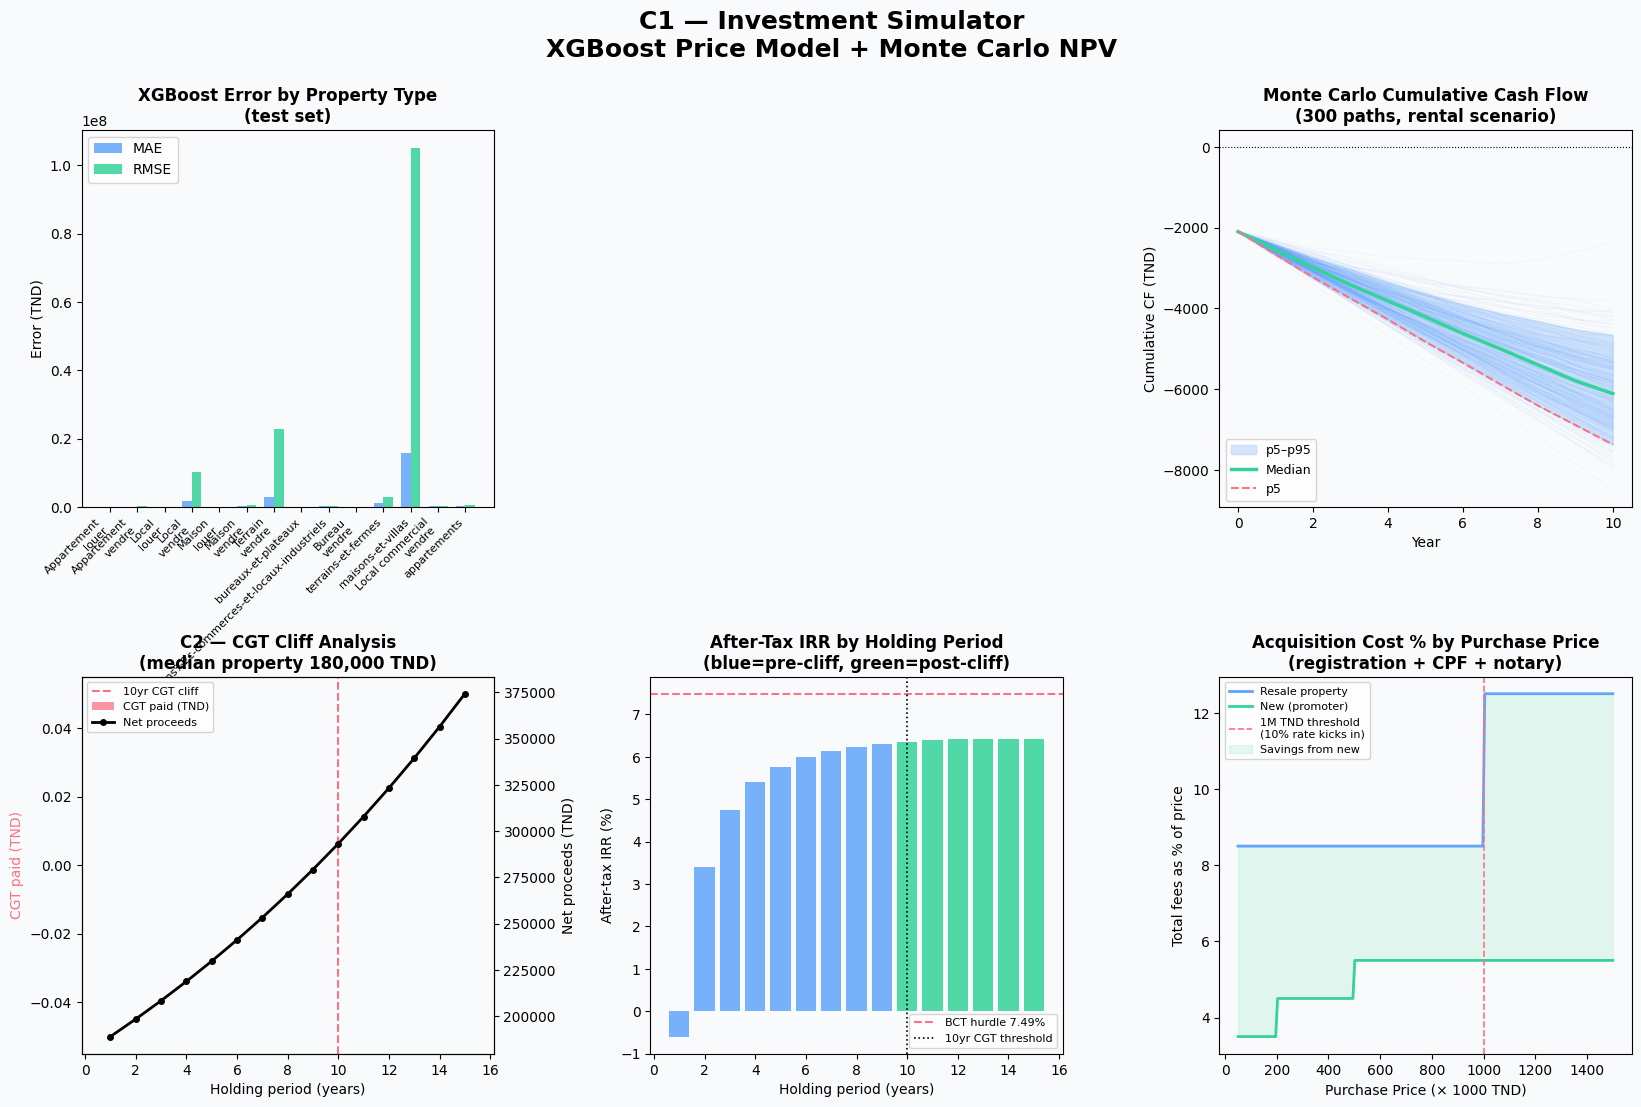

Saved: viz_02_c1_c2_models.png


In [ ]:
import matplotlib.pyplot as plt

ACCENT  = "#60A5FA" # Blue
ACCENT2 = "#34D399" # Green
WARN    = "#FB7185" # Red
NEUTRAL = "#9CA3AF" # Gray
BG      = "#F9FAFB" # Light Gray

# ════════════════════════════════════════════════════════════════
# VIZ CELL 2 — C1 XGBoost model performance + Monte Carlo NPV
# ════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 12), facecolor=BG)
fig.suptitle("C1 — Investment Simulator\nXGBoost Price Model + Monte Carlo NPV",
             fontsize=18, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ══ 1. XGBoost MAE per type ════════════════════
ax1 = fig.add_subplot(gs[0, 0])
if hasattr(generator.simulator, '_xgb_models') and generator.simulator._xgb_models:
    types   = list(generator.simulator._xgb_models.keys())
    maes    = [generator.simulator._xgb_models[t]["mae"]  for t in types]
    rmses   = [generator.simulator._xgb_models[t]["rmse"] for t in types]
    x       = np.arange(len(types))
    w       = 0.35
    ax1.bar(x - w/2, maes,  w, label="MAE",  color=ACCENT,  alpha=0.85)
    ax1.bar(x + w/2, rmses, w, label="RMSE", color=ACCENT2, alpha=0.85)
    ax1.set_xticks(x)
    ax1.set_xticklabels([t.replace(" a ","\n") for t in types],
                         rotation=45, ha="right", fontsize=8)
    ax1.set_title("XGBoost Error by Property Type\n(test set)", fontweight="bold")
    ax1.set_ylabel("Error (TND)")
    ax1.legend()
else:
    ax1.text(0.5, 0.5, "Run generator to populate\nXGBoost models",
             ha="center", va="center", transform=ax1.transAxes, color=NEUTRAL)
    ax1.set_title("XGBoost MAE / RMSE", fontweight="bold")
ax1.set_facecolor(BG)

# ══ 3. Monte Carlo NPV fan chart for a sample property ════════════
ax3 = fig.add_subplot(gs[0, 2])
sample_prop = df_modeling[df_modeling["price_numeric"].notna()].sample(
    1, random_state=7).iloc[0].to_dict()
C     = TUNISIA_CONSTANTS
price = float(sample_prop["price_numeric"])
down  = price * (1 - C["ltv_max"])
rng   = np.random.default_rng(42)
years = 10
n_fan = 300   # paths to draw (visual only — lighter than full 10k)
appr_s  = rng.normal(C["appreciation_national"], 0.02, (n_fan, years))
gy_s    = rng.normal(C["gross_yield_national"],  0.015, n_fan).clip(0.01, 0.15)
vac_s   = rng.beta(2, 8, (n_fan, years))
cum_npv = np.zeros((n_fan, years+1))
for s in range(n_fan):
    cur = price
    cf  = [-down]
    for yr in range(years):
        cur  *= (1 + appr_s[s, yr])
        nr    = cur * gy_s[s] * (1 - vac_s[s, yr]) * (1 - C["irpp_rental_flat"])
        cf.append(nr - cur*0.01 - price*(C["mortgage_rate_mid"]/12)*12)
    cum = np.cumsum(cf)
    cum_npv[s] = cum
for s in range(n_fan):
    ax3.plot(range(years+1), cum_npv[s], alpha=0.06, linewidth=0.7,
             color=ACCENT)
p5  = np.percentile(cum_npv, 5,  axis=0)
p50 = np.percentile(cum_npv, 50, axis=0)
p95 = np.percentile(cum_npv, 95, axis=0)
ax3.fill_between(range(years+1), p5, p95, alpha=0.25, color=ACCENT, label="p5–p95")
ax3.plot(range(years+1), p50, color=ACCENT2, linewidth=2.5, label="Median")
ax3.plot(range(years+1), p5,  color=WARN,   linewidth=1.5, linestyle="--", label="p5")
ax3.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax3.set_title("Monte Carlo Cumulative Cash Flow\n(300 paths, rental scenario)",
              fontweight="bold")
ax3.set_xlabel("Year")
ax3.set_ylabel("Cumulative CF (TND)")
ax3.legend(fontsize=9)
ax3.set_facecolor(BG)

# ══ 4. C2 — CGT cliff visualisation ═══════════════════
ax4 = fig.add_subplot(gs[1, 0])
sample_price = float(df_modeling["price_numeric"].median())
hold_years   = list(range(1, 16))
cgt_taxes, net_proceeds_list, irrs = [], [], []
for yr in hold_years:
    info = generator.tax_optimizer.compute_capital_gains_tax(
        sample_price,
        sample_price * (1 + C["appreciation_national"]) ** yr,
        yr)
    cgt_taxes.append(info["cgt"])
    net_proceeds_list.append(info["net_proceeds"])
ax4_twin = ax4.twinx()
ax4.bar(hold_years, cgt_taxes, color=[WARN if y < 10 else ACCENT2 for y in hold_years],
        alpha=0.75, label="CGT paid (TND)")
ax4_twin.plot(hold_years, net_proceeds_list, color="black", linewidth=2,
              marker="o", markersize=4, label="Net proceeds")
ax4.axvline(10, color=WARN, linestyle="--", linewidth=1.5,
            label="10yr CGT cliff")
ax4.set_title(f"C2 — CGT Cliff Analysis\n(median property {sample_price:,.0f} TND)",
              fontweight="bold")
ax4.set_xlabel("Holding period (years)")
ax4.set_ylabel("CGT paid (TND)", color=WARN)
ax4_twin.set_ylabel("Net proceeds (TND)")
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1+lines2, labels1+labels2, fontsize=8, loc="upper left")
ax4.set_facecolor(BG)

# ══ 5. Holding period IRR sweep ════════════════════
ax5 = fig.add_subplot(gs[1, 1])
sample_pd = df_modeling[df_modeling["price_numeric"].notna()].sample(
    1, random_state=99).iloc[0].to_dict()
sweep = generator.tax_optimizer.sweep_holding_period(
    sample_pd, {"is_new_promoter": False})
yrs_sw  = [r["years"]   for r in sweep]
irr_sw  = [r["irr_pct"] for r in sweep]
colors_s= [ACCENT2 if i >= 10 else ACCENT for i in yrs_sw]
ax5.bar(yrs_sw, irr_sw, color=colors_s, alpha=0.85)
ax5.axhline(C["bcт_tmm"]*100, color=WARN, linestyle="--", linewidth=1.5,
            label=f"BCT hurdle {C['bcт_tmm']*100:.2f}%")
ax5.axvline(10, color="black", linestyle=":", linewidth=1.2,
            label="10yr CGT threshold")
ax5.set_title("After-Tax IRR by Holding Period\n(blue=pre-cliff, green=post-cliff)",
              fontweight="bold")
ax5.set_xlabel("Holding period (years)")
ax5.set_ylabel("After-tax IRR (%)")
ax5.legend(fontsize=8)
ax5.set_facecolor(BG)

# ══ 6. Acquisition cost breakdown ══════════════════
ax6 = fig.add_subplot(gs[1, 2])
price_range = np.linspace(50_000, 1_500_000, 200)
fees_resale  = [generator.tax_optimizer.compute_acquisition_costs(p)["fees_pct"]
                for p in price_range]
fees_new     = [generator.tax_optimizer.compute_acquisition_costs(p, True)["fees_pct"]
                for p in price_range]
ax6.plot(price_range/1000, fees_resale, color=ACCENT,  linewidth=2,
         label="Resale property")
ax6.plot(price_range/1000, fees_new,    color=ACCENT2, linewidth=2,
         label="New (promoter)")
ax6.axvline(1000, color=WARN, linestyle="--", linewidth=1.2,
            label="1M TND threshold\n(10% rate kicks in)")
ax6.fill_between(price_range/1000, fees_new, fees_resale,
                 alpha=0.12, color=ACCENT2, label="Savings from new")
ax6.set_title("Acquisition Cost % by Purchase Price\n(registration + CPF + notary)",
              fontweight="bold")
ax6.set_xlabel("Purchase Price (× 1000 TND)")
ax6.set_ylabel("Total fees as % of price")
ax6.legend(fontsize=8)
ax6.set_facecolor(BG)

plt.savefig("viz_02_c1_c2_models.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Saved: viz_02_c1_c2_models.png")

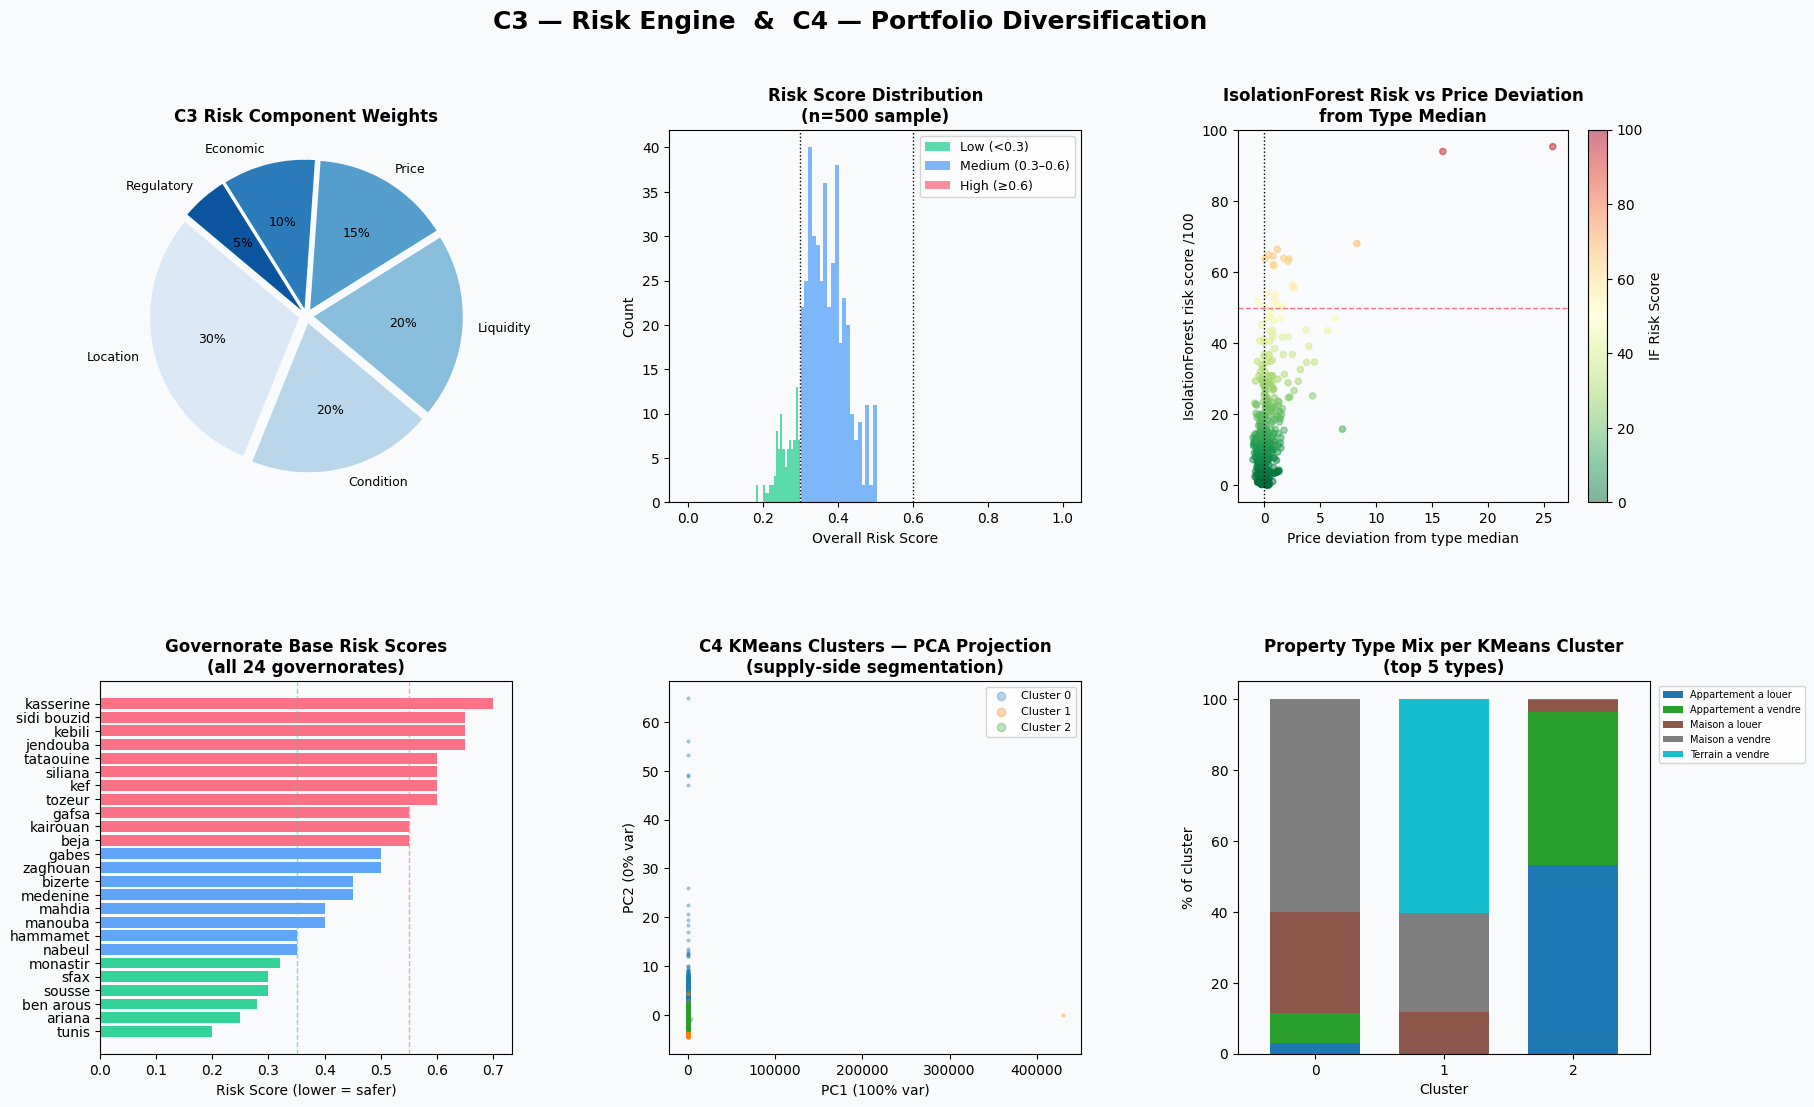

Saved: viz_03_c3_c4_models.png


In [ ]:
import matplotlib.pyplot as plt

ACCENT  = "#60A5FA" # Blue
ACCENT2 = "#34D399" # Green
WARN    = "#FB7185" # Red
NEUTRAL = "#9CA3AF" # Gray
BG      = "#F9FAFB" # Light Gray

# ═══════════════════════════════════════════════════════════════════════════
# VIZ CELL 3 — C3 Risk Engine breakdown + C4 Portfolio clustering
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 12), facecolor=BG)
fig.suptitle("C3 — Risk Engine  &  C4 — Portfolio Diversification",
             fontsize=18, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)

# ── 1. Risk component weights (pie) ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
weights = generator.risk_engine.WEIGHTS
labels  = [k.replace("_risk","").replace("_"," ").title() for k in weights]
vals    = list(weights.values())
explode = [0.05]*len(vals)
wedge_colors = sns.color_palette("Blues", len(vals))
ax1.pie(vals, labels=labels, autopct="%1.0f%%", colors=wedge_colors,
        explode=explode, startangle=140, textprops={"fontsize":9})
ax1.set_title("C3 Risk Component Weights", fontweight="bold")

# ── 2. Risk score distribution across dataset ─────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sample_n = min(500, len(df_modeling))
sample_df = df_modeling[df_modeling["price_numeric"].notna()].sample(
    sample_n, random_state=42)
risk_scores = [generator.risk_engine.calculate_overall_risk(
                   row.to_dict())["overall_risk_score"]
               for _, row in sample_df.iterrows()]
risk_arr = np.array(risk_scores)
ax2.hist(risk_arr[risk_arr < 0.3],  bins=20, color=ACCENT2, alpha=0.8, label="Low (<0.3)")
ax2.hist(risk_arr[(risk_arr>=0.3) & (risk_arr<0.6)],
         bins=20, color=ACCENT,  alpha=0.8, label="Medium (0.3–0.6)")
ax2.hist(risk_arr[risk_arr>=0.6],   bins=20, color=WARN,   alpha=0.8, label="High (≥0.6)")
ax2.axvline(0.3, color="black", linestyle=":", linewidth=1)
ax2.axvline(0.6, color="black", linestyle=":", linewidth=1)
ax2.set_title(f"Risk Score Distribution\n(n={sample_n} sample)", fontweight="bold")
ax2.set_xlabel("Overall Risk Score")
ax2.set_ylabel("Count")
ax2.legend(fontsize=9)
ax2.set_facecolor(BG)

# ── 3. IsolationForest score vs price deviation ───────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
if_scores_list, price_devs = [], []
for _, row in sample_df.iterrows():
    pd_   = row.to_dict()
    typ   = pd_.get("Type","")
    peers = df_modeling[df_modeling["Type"]==typ]["price_numeric"].median()
    if peers and peers > 0:
        dev = (float(pd_.get("price_numeric",0) or 0) - peers) / peers
        price_devs.append(dev)
        if_scores_list.append(generator.risk_engine._if_score(pd_))
if price_devs:
    sc = ax3.scatter(price_devs, if_scores_list,
                     c=if_scores_list, cmap="RdYlGn_r",
                     alpha=0.5, s=20, vmin=0, vmax=100)
    plt.colorbar(sc, ax=ax3, label="IF Risk Score")
    ax3.axvline(0,    color="black", linestyle=":", linewidth=1)
    ax3.axhline(50,   color=WARN,    linestyle="--", linewidth=1)
    ax3.set_title("IsolationForest Risk vs Price Deviation\nfrom Type Median",
                  fontweight="bold")
    ax3.set_xlabel("Price deviation from type median")
    ax3.set_ylabel("IsolationForest risk score /100")
ax3.set_facecolor(BG)

# ── 4. Governorate risk table heatmap ─────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
gov_risk = generator.risk_engine.GOV_RISK
gov_df   = pd.DataFrame(list(gov_risk.items()),
                         columns=["Governorate","Risk"]).sort_values("Risk")
bar_colors = [ACCENT2 if v < 0.35 else ACCENT if v < 0.55 else WARN
              for v in gov_df["Risk"]]
ax4.barh(gov_df["Governorate"], gov_df["Risk"], color=bar_colors)
ax4.axvline(0.35, color=ACCENT2, linestyle="--", linewidth=1, alpha=0.6)
ax4.axvline(0.55, color=WARN,    linestyle="--", linewidth=1, alpha=0.6)
ax4.set_title("Governorate Base Risk Scores\n(all 24 governorates)",
              fontweight="bold")
ax4.set_xlabel("Risk Score (lower = safer)")
ax4.set_facecolor(BG)

# ── 5. KMeans cluster visualisation (PCA 2D projection) ───────────────────
ax5 = fig.add_subplot(gs[1, 1])
from sklearn.decomposition import PCA
if (hasattr(generator.portfolio_advisor, "_kmeans_model") and
        generator.portfolio_advisor._kmeans_model is not None):
    feat_cols = generator.portfolio_advisor._cluster_feats
    X_raw = df_modeling[feat_cols].astype(float).fillna(0)
    X_sc  = generator.portfolio_advisor._kmeans_scaler.transform(X_raw)
    pca   = PCA(n_components=2, random_state=42)
    X_2d  = pca.fit_transform(X_sc)
    labels_km = generator.portfolio_advisor._clusters_kmeans
    palette   = sns.color_palette("tab10", len(set(labels_km)))
    for cl in sorted(set(labels_km)):
        mask = labels_km == cl
        ax5.scatter(X_2d[mask, 0], X_2d[mask, 1],
                    s=4, alpha=0.3, color=palette[cl],
                    label=f"Cluster {cl}", rasterized=True)
    ax5.set_title("C4 KMeans Clusters — PCA Projection\n(supply-side segmentation)",
                  fontweight="bold")
    ax5.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% var)")
    ax5.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% var)")
    ax5.legend(markerscale=3, fontsize=8)
else:
    ax5.text(0.5, 0.5, "Run generator to build\nKMeans clusters",
             ha="center", va="center", transform=ax5.transAxes, color=NEUTRAL)
    ax5.set_title("KMeans Clusters — PCA Projection", fontweight="bold")
ax5.set_facecolor(BG)

# ── 6. Cluster composition — type breakdown per cluster ───────────────────
ax6 = fig.add_subplot(gs[1, 2])
if (hasattr(generator.portfolio_advisor, "_clusters_kmeans") and
        generator.portfolio_advisor._clusters_kmeans is not None):
    df_cl = df_modeling.copy()
    df_cl["_cluster"] = generator.portfolio_advisor._clusters_kmeans
    top_types = df_modeling["Type"].value_counts().head(5).index
    df_cl_top = df_cl[df_cl["Type"].isin(top_types)]
    ct = (df_cl_top.groupby(["_cluster","Type"])
          .size().unstack(fill_value=0))
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind="bar", ax=ax6, stacked=True,
                colormap="tab10", width=0.7)
    ax6.set_title("Property Type Mix per KMeans Cluster\n(top 5 types)",
                  fontweight="bold")
    ax6.set_xlabel("Cluster")
    ax6.set_ylabel("% of cluster")
    ax6.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
    ax6.tick_params(axis="x", rotation=0)
else:
    ax6.text(0.5, 0.5, "No cluster data", ha="center", va="center",
             transform=ax6.transAxes, color=NEUTRAL)
    ax6.set_title("Type Mix per Cluster", fontweight="bold")
ax6.set_facecolor(BG)

plt.savefig("viz_03_c3_c4_models.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Saved: viz_03_c3_c4_models.png")

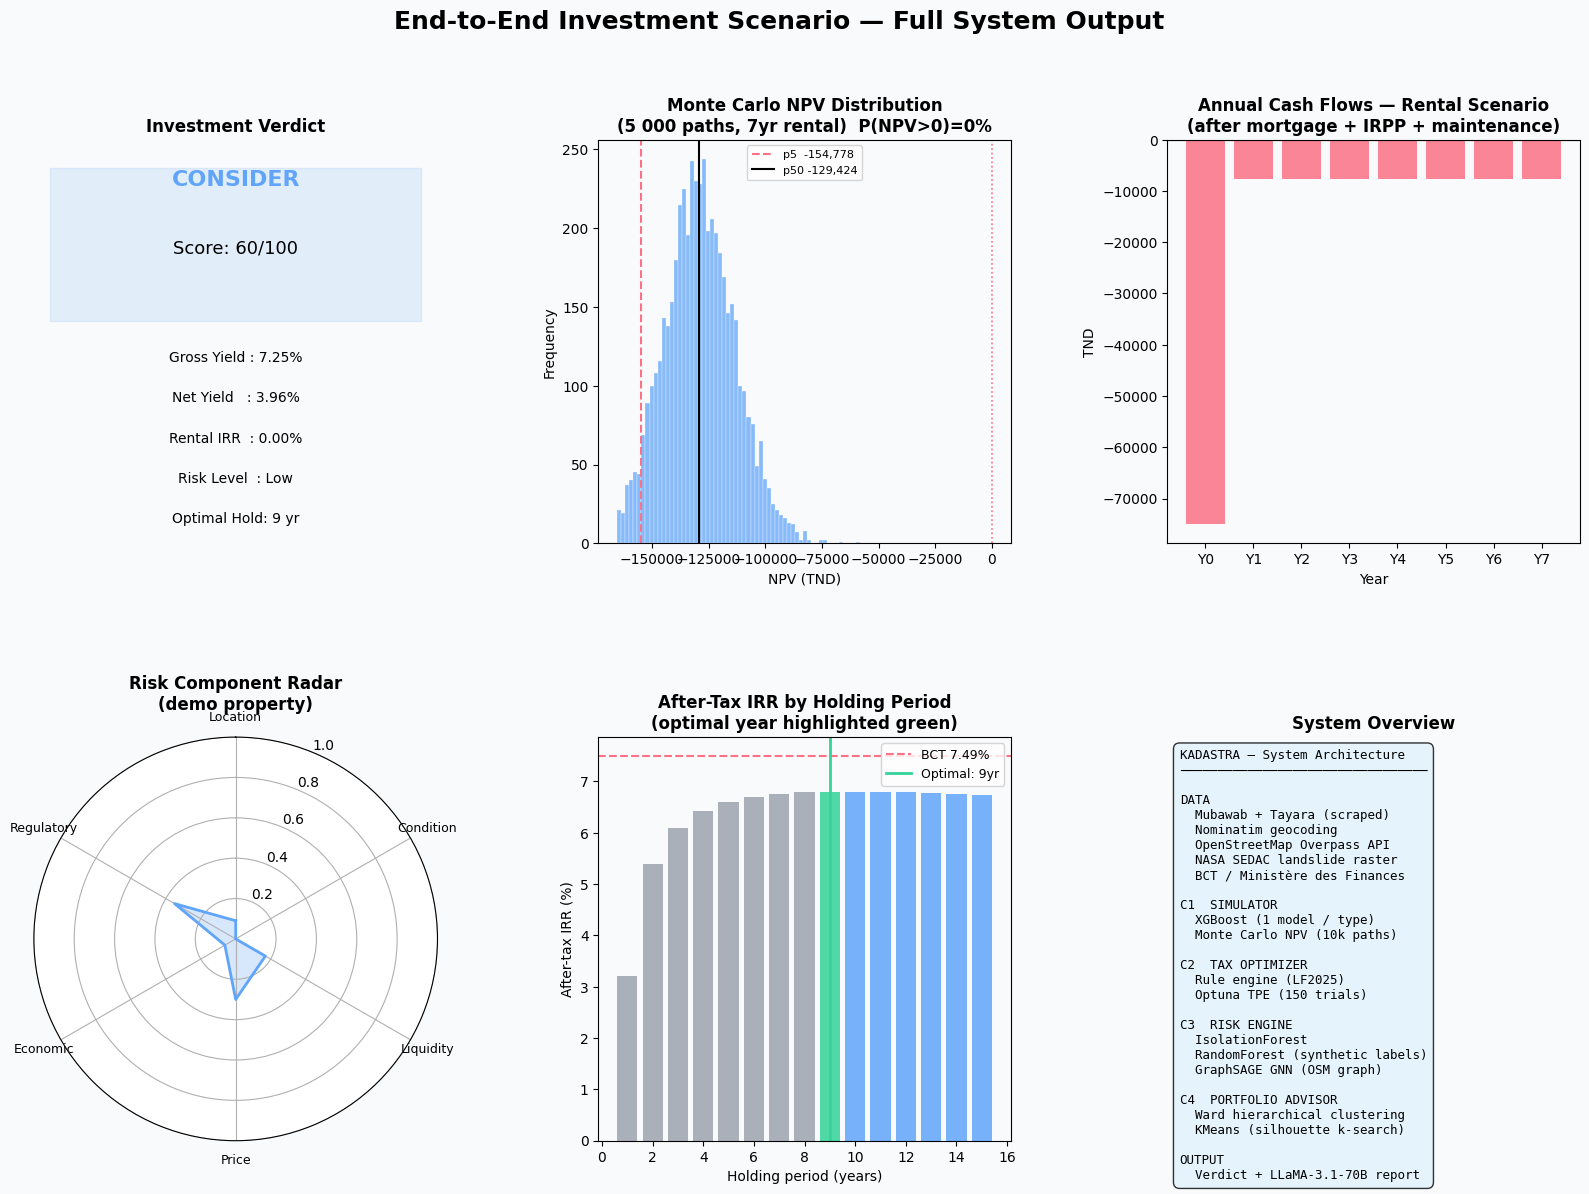

Saved: viz_04_full_scenario.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# VIZ CELL 4 — Full system: end-to-end scenario for one property
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 13), facecolor=BG)
fig.suptitle("End-to-End Investment Scenario — Full System Output",
             fontsize=18, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)

# Run one scenario on the manual example property
demo_prop = {
    'Type':            'Appartement a vendre',
    'Adresse':         'Tunis, Les Berges du Lac',
    'price_numeric':   250_000,
    'surface_numeric': 120,
    'neuf': 1, 'parking': 1, 'balcon_terrasse': 1,
    'climatisation': 1, 'chauffage': 1, 'ascenseur': 1,
}
demo_profile = {
    'budget': 300_000, 'holding_period_years': 7,
    'rental_income': 0,       # will be auto-filled from C1
    'first_time_buyer':     True,
    'is_new_promoter':      True,
    'risk_tolerance':       'medium',
}
sc = generator.generate_investment_scenario(demo_prop, demo_profile)

# ── 1. Verdict scorecard ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1); ax1.axis("off")
score   = sc["verdict"]["score"]
rec     = sc["verdict"]["recommendation"]
col_rec = (ACCENT2 if "BUY" in rec else
           ACCENT   if "CONSIDER" in rec else
           WARN)
ax1.add_patch(plt.Rectangle((0.05,0.55), 0.9, 0.38,
              color=col_rec, alpha=0.15, transform=ax1.transAxes))
ax1.text(0.5, 0.90, rec, ha="center", va="center", fontsize=16,
         fontweight="bold", color=col_rec, transform=ax1.transAxes)
ax1.text(0.5, 0.72, f"Score: {score}/100", ha="center", fontsize=13,
         transform=ax1.transAxes)
ax1.text(0.5, 0.45, f"Gross Yield : {sc['simulator']['rental_yield']['gross_yield']:.2f}%",
         ha="center", fontsize=10, transform=ax1.transAxes)
ax1.text(0.5, 0.35, f"Net Yield   : {sc['simulator']['rental_yield']['net_yield']:.2f}%",
         ha="center", fontsize=10, transform=ax1.transAxes)
ax1.text(0.5, 0.25, f"Rental IRR  : {sc['simulator']['roi_rental']['irr_percent']:.2f}%",
         ha="center", fontsize=10, transform=ax1.transAxes)
ax1.text(0.5, 0.15, f"Risk Level  : {sc['risk']['risk_level']}",
         ha="center", fontsize=10, transform=ax1.transAxes)
ax1.text(0.5, 0.05, f"Optimal Hold: {sc['tax']['optimal_holding_years']} yr",
         ha="center", fontsize=10, transform=ax1.transAxes)
ax1.set_title("Investment Verdict", fontweight="bold")

# ── 2. Monte Carlo NPV distribution (histogram) ───────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
mc_full = generator.simulator.monte_carlo_npv(demo_prop, years=7, n_sims=5000)
rng2    = np.random.default_rng(42)
appr_f  = rng2.normal(C["appreciation_national"], 0.02, (5000, 7))
gy_f    = rng2.normal(C["gross_yield_national"],  0.015, 5000).clip(0.01, 0.15)
vac_f   = rng2.beta(2, 8, (5000, 7))
price_d = 250_000; down_d = price_d*(1-C["ltv_max"])
mrate   = C["mortgage_rate_mid"]/12; nmo = C["mortgage_max_years"]*12
mpmt    = float(np.abs(np.pmt(mrate, nmo, price_d-down_d))) if hasattr(np,'pmt') else 0
try:
    import numpy_financial as npf2
    mpmt = float(npf2.pmt(mrate, nmo, -(price_d-down_d)))
except Exception:
    mpmt = price_d * 0.007
npvs_d = []
for s in range(5000):
    cur = price_d; cf = [-down_d]
    for yr in range(7):
        cur *= (1+appr_f[s,yr])
        nr   = cur*gy_f[s]*(1-vac_f[s,yr])*(1-C["irpp_rental_flat"])
        cf.append(nr - cur*0.01 - mpmt*12)
    try:
        npvs_d.append(float(__import__("numpy_financial").npv(C["bcт_tmm"], cf)))
    except Exception:
        npvs_d.append(sum(c/(1+C["bcт_tmm"])**i for i,c in enumerate(cf)))
npvs_arr = np.array(npvs_d)
p_pos    = (npvs_arr > 0).mean()
ax2.hist(npvs_arr[npvs_arr > np.percentile(npvs_arr,1)], bins=60,
         color=ACCENT, alpha=0.75, edgecolor="white", linewidth=0.3)
ax2.axvline(np.percentile(npvs_arr,5),  color=WARN,   linestyle="--",
            linewidth=1.5, label=f"p5  {np.percentile(npvs_arr,5):,.0f}")
ax2.axvline(np.percentile(npvs_arr,50), color="black",linestyle="-",
            linewidth=1.5, label=f"p50 {np.percentile(npvs_arr,50):,.0f}")
ax2.axvline(0, color=WARN, linestyle=":", linewidth=1.2)
ax2.set_title(f"Monte Carlo NPV Distribution\n(5 000 paths, 7yr rental)  "
              f"P(NPV>0)={p_pos*100:.0f}%", fontweight="bold")
ax2.set_xlabel("NPV (TND)")
ax2.set_ylabel("Frequency")
ax2.legend(fontsize=8)
ax2.set_facecolor(BG)

# ── 3. Annual cash flow waterfall ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
cfs = sc["simulator"]["roi_rental"]["cash_flows"]
colors_cf = [ACCENT2 if v >= 0 else WARN for v in cfs]
labels_cf = ["Y0"] + [f"Y{i}" for i in range(1, len(cfs))]
ax3.bar(labels_cf, cfs, color=colors_cf, alpha=0.85)
ax3.axhline(0, color="black", linewidth=0.8)
ax3.set_title("Annual Cash Flows — Rental Scenario\n(after mortgage + IRPP + maintenance)",
              fontweight="bold")
ax3.set_xlabel("Year")
ax3.set_ylabel("TND")
ax3.set_facecolor(BG)

# ── 4. Risk component radar chart ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0], polar=True)
comp   = sc["risk"]["component_scores"]
labels_r = [k.replace("_risk","\
").replace("_","\
").title() for k in comp]
vals_r   = list(comp.values())
vals_r  += vals_r[:1]   # close the polygon
angles   = np.linspace(0, 2*np.pi, len(labels_r), endpoint=False).tolist()
angles  += angles[:1]
ax4.set_theta_offset(np.pi/2)
ax4.set_theta_direction(-1)
ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(labels_r, fontsize=9)
ax4.set_ylim(0, 1)
ax4.plot(angles, vals_r, color=ACCENT, linewidth=2)
ax4.fill(angles, vals_r, color=ACCENT, alpha=0.25)
ax4.set_title("Risk Component Radar\n(demo property)", fontweight="bold", pad=20)

# ── 5. Holding period sweep with optimum highlighted ──────────────────────
ax5 = fig.add_subplot(gs[1, 1])
sweep = sc["tax"]["holding_period_sweep"]
yrs_  = [r["years"]   for r in sweep]
irrs_ = [r["irr_pct"] for r in sweep]
opt_y = sc["tax"]["optimal_holding_years"]
bar_c = [ACCENT2 if y == opt_y else (ACCENT if y >= 10 else NEUTRAL)
         for y in yrs_]
ax5.bar(yrs_, irrs_, color=bar_c, alpha=0.85)
ax5.axhline(C["bcт_tmm"]*100, color=WARN, linestyle="--",
            linewidth=1.5, label=f"BCT {C['bcт_tmm']*100:.2f}%")
ax5.axvline(opt_y, color=ACCENT2, linestyle="-", linewidth=2,
            label=f"Optimal: {opt_y}yr")
ax5.set_title("After-Tax IRR by Holding Period\n(optimal year highlighted green)",
              fontweight="bold")
ax5.set_xlabel("Holding period (years)")
ax5.set_ylabel("After-tax IRR (%)")
ax5.legend(fontsize=9)
ax5.set_facecolor(BG)

# ── 6. System architecture summary ────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
arch_text = (
    "KADASTRA — System Architecture\n"
    "─────────────────────────────────\n\n"
    "DATA\n"
    "  Mubawab + Tayara (scraped)\n"
    "  Nominatim geocoding\n"
    "  OpenStreetMap Overpass API\n"
    "  NASA SEDAC landslide raster\n"
    "  BCT / Ministère des Finances\n\n"
    "C1  SIMULATOR\n"
    "  XGBoost (1 model / type)\n"
    "  Monte Carlo NPV (10k paths)\n\n"
    "C2  TAX OPTIMIZER\n"
    "  Rule engine (LF2025)\n"
    "  Optuna TPE (150 trials)\n\n"
    "C3  RISK ENGINE\n"
    "  IsolationForest\n"
    "  RandomForest (synthetic labels)\n"
    "  GraphSAGE GNN (OSM graph)\n\n"
    "C4  PORTFOLIO ADVISOR\n"
    "  Ward hierarchical clustering\n"
    "  KMeans (silhouette k-search)\n\n"
    "OUTPUT\n"
    "  Verdict + LLaMA-3.1-70B report"
)
ax6.text(0.03, 0.97, arch_text, transform=ax6.transAxes,
         fontsize=9, verticalalignment="top",
         fontfamily="monospace",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#E0F2FE", alpha=0.8))
ax6.set_title("System Overview", fontweight="bold")

plt.savefig("viz_04_full_scenario.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Saved: viz_04_full_scenario.png")

# Download all plots
try:
    from google.colab import files
    for fname in ["viz_01_dataset_overview.png","viz_02_c1_c2_models.png",
                  "viz_03_c3_c4_models.png","viz_04_full_scenario.png"]:
        files.download(fname)
except Exception:
    pass